# NOTES:

- To data loaded here was fromed by running:
> complie_RT_caltech_v1.m, complie_RT_caltech_v2.m, complie_RT_humburg.m, complie_RT_sydney.m, complie_RT_telaviv.m.
- Then:
> RT_concat_files.m


- There is more cleanup to do(!)
- Caltech2 had less trials, a 1/3 less. 16 instead of 24 for the 1-day and 96 instead of 144 in the 3-day group.

# Preparing stuff

In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib import ticker
import plotly.graph_objects as go

import numpy as np
import pandas as pd
import seaborn as sns
import os
import math


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import learning_curve

from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, auc, brier_score_loss, pairwise_distances, silhouette_samples, precision_score, recall_score, silhouette_score

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier # Multi layer perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay, partial_dependence
from sklearn.utils import shuffle
from sklearn.calibration import calibration_curve
from sklearn.tree import plot_tree
from sklearn.cross_decomposition import PLSRegression

import shap
from scipy.stats import binomtest, binom_test, ttest_ind, mannwhitneyu
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.stats import chi2_contingency
from scipy.cluster.hierarchy import fcluster
from scipy.cluster.hierarchy import dendrogram

from joblib import Parallel, delayed
import pickle


from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression


# Functions

# LOAD DATA

In [6]:
# Load data from CSV
IPI_df = pd.read_csv('DATABASES/RT_ALL_SITES.csv')
run1_features_df = pd.read_csv('DATABASES/RUN1_FEATURES_ALL_SITES.csv')
Dependent_var_df_SCORE = pd.read_csv('DATABASES/DV_ALL_SITES.csv')
# Dependent_var_df_SCORE = pd.read_csv('DATABASES/CHANGE_means_clusters.csv')
Dependent_var_df_SCORE 


,oldSubID,newID,group,site,pre_val,pre_deval,post_val,post_deval,CHANGE_SCORE
0,1,51,1-day,Caltech1,4.877195,4.969821,5.729812,5.349233,0.473206
1,2,52,1-day,Caltech1,3.961162,4.079287,4.732055,4.593628,0.256552
2,3,53,1-day,Caltech1,1.628004,1.614908,1.749792,1.479064,0.257632
3,4,54,1-day,Caltech1,3.358101,4.113441,3.830604,2.874372,1.711572
4,5,55,1-day,Caltech1,1.128313,1.206503,0.700127,1.461566,-0.683249
...,...,...,...,...,...,...,...,...,...
301,237,364,3-day,Tel_Aviv,2.744744,2.426000,2.499009,3.238484,-1.058219
302,238,365,3-day,Tel_Aviv,0.951292,0.212646,0.000000,0.016673,-0.755319
303,239,366,3-day,Tel_Aviv,2.565446,2.626659,1.977234,0.216779,1.821668
304,240,367,3-day,Tel_Aviv,4.632651,4.500755,4.815051,5.081356,-0.398201


In [7]:
IPI_df.rename(columns={'newID': 'subID'}, inplace=True)
IPI_df['IPI'] = IPI_df.groupby(['subID', 'trial'])['RT'].diff()
IPI_df['IPI_abs_diff'] = IPI_df['IPI'].diff().abs()
# merge with DV
Dependent_var_df_SCORE.rename(columns={'newID': 'subID', 'CHANGE_SCORE': 'behav_adaptation_SCORE'}, inplace=True)
# Normalize (standardize) behav_adaptation_SCORE in Dependent_var_df_SCORE PER SITE(!):
Dependent_var_df_SCORE['behav_adaptation_SCORE_NORMED'] = Dependent_var_df_SCORE.groupby('site')['behav_adaptation_SCORE'].transform(
    lambda x: (x - x.mean()) / x.std()
)
# if not already merged:
if 'behav_adaptation_SCORE' not in IPI_df.columns:
    IPI_df = IPI_df.merge(Dependent_var_df_SCORE[['subID', 'behav_adaptation_SCORE', 'behav_adaptation_SCORE_NORMED']], on='subID', how='left')
IPI_df.head(20)
# save to CSV:
# IPI_df.to_csv('IPI_data_Pool_et_al.csv', index=False)
main_data_df = IPI_df.copy()

# Now prepare run1_features_df
run1_features_df.rename(columns={'newID': 'subID'}, inplace=True)
if 'behav_adaptation_SCORE_NORMED' not in run1_features_df.columns:
    run1_features_df = run1_features_df.merge(Dependent_var_df_SCORE[['subID', 'behav_adaptation_SCORE']], on='subID', how='left')

# remove the columns oldSubID,day,run if they exist:
for col in ['oldSubID', 'day', 'run']:
    if col in run1_features_df.columns:
        run1_features_df.drop(columns=[col], inplace=True)


run1_features_df

,subID,group,site,resp_rate_trial_mean,resp_rate_trial_std,resp_pairs_sum_std,RTs_first_resp_mean,RTs_first_resp_std,isCorrectResp_prop_mean,isCorrectResp_prop_std,...,resp_time_diff_std,volatility,right_vs_left,sweet_vs_salty,post_reward_RT_mean,post_reward_RT_std,resp_time_diff_after_reward_mean,resp_time_diff_after_reward_std,run_burstiness,behav_adaptation_SCORE
0,51,1-day,Caltech1,4.447937,0.772161,0.773119,1.196256,0.252079,0.993447,0.010024,...,0.136814,0.066667,188,-180,0.090504,0.086274,0.016819,0.100087,-0.214165,0.473206
1,52,1-day,Caltech1,4.044676,0.369296,0.428291,0.970590,0.479302,0.994602,0.008452,...,0.118758,0.068793,-20,-20,0.124221,0.110797,0.014837,0.054547,-0.341248,0.256552
2,53,1-day,Caltech1,1.564667,0.100611,0.089641,1.165038,0.201668,0.995760,0.010626,...,0.258177,0.147617,5,-5,0.248324,0.212158,-0.017729,0.610955,-0.409801,0.257632
3,54,1-day,Caltech1,4.031388,0.212653,0.311696,1.201565,1.021008,0.992700,0.011392,...,0.149887,0.074000,8,2,0.083272,0.035061,0.002787,0.065607,-0.222391,1.711572
4,55,1-day,Caltech1,0.936968,0.180706,0.311727,1.304098,0.398750,0.997807,0.007597,...,0.795475,0.600399,-10,12,0.912095,0.942819,0.962956,1.708348,-0.108216,-0.683249
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,364,3-day,Tel_Aviv,2.765301,0.728363,1.285678,1.038404,0.339436,0.990743,0.015870,...,0.224215,0.148205,62,70,0.207068,0.224625,0.071628,0.299725,-0.229539,-1.058219
302,365,3-day,Tel_Aviv,3.534231,0.773736,1.413689,0.834004,0.271131,0.995653,0.006775,...,0.157825,0.085838,106,-110,0.096540,0.042246,0.008828,0.113908,-0.270029,-0.755319
303,366,3-day,Tel_Aviv,1.655246,0.184785,0.258539,1.965709,1.075888,0.995288,0.009051,...,0.237720,0.162923,45,47,0.234704,0.127724,-0.033121,0.203294,-0.405264,1.821668
304,367,3-day,Tel_Aviv,3.714765,0.371899,0.488428,1.268879,0.506702,0.995079,0.010164,...,0.126037,0.067802,-29,31,0.108934,0.066236,0.000826,0.061007,-0.342599,-0.398201


In [8]:
run1_features_df
# print the descriptive statistics of behav_adaptation_SCORE per site and group
run1_features_df.groupby(['site','group']).behav_adaptation_SCORE.describe()
# add a binary column 'isHabitual' based on behav_adaptation_SCORE lower than median:
run1_features_df['isHabitual'] = np.where(run1_features_df['behav_adaptation_SCORE'] <= run1_features_df.behav_adaptation_SCORE.median(), 1, 0)
run1_features_df.groupby(['site','group']).isHabitual.describe()

# Change group 1-day to -1 and 3-day to 1 for easier ML interpretation:
run1_features_df['group'] = run1_features_df['group'].map({'1-day': -1, '3-day': 1})
run1_features_df.groupby(['site', 'group']).isHabitual.describe()


count      mean       std  min  25%  50%  75%  max
site     group                                                    
Caltech1 -1      31.0  0.516129  0.508001  0.0  0.0  1.0  1.0  1.0
          1      31.0  0.548387  0.505879  0.0  0.0  1.0  1.0  1.0
Caltech2 -1      30.0  0.433333  0.504007  0.0  0.0  0.0  1.0  1.0
          1      29.0  0.586207  0.501230  0.0  0.0  1.0  1.0  1.0
Hamburg  -1      28.0  0.535714  0.507875  0.0  0.0  1.0  1.0  1.0
          1      37.0  0.540541  0.505228  0.0  0.0  1.0  1.0  1.0
Sydney   -1      30.0  0.366667  0.490133  0.0  0.0  0.0  1.0  1.0
          1      30.0  0.300000  0.466092  0.0  0.0  0.0  1.0  1.0
Tel_Aviv -1      30.0  0.600000  0.498273  0.0  0.0  1.0  1.0  1.0
          1      30.0  0.566667  0.504007  0.0  0.0  1.0  1.0  1.0

Check viable stratification options:

In [5]:
from collections import Counter
from sklearn.feature_selection import SelectKBest, f_classif
from joblib import Parallel, delayed
from tqdm import tqdm
from sklearn.model_selection import train_test_split

features_data = run1_features_df.copy().reset_index(drop=True)

# Models to test + # features + settings:
# ----------------------------------------
# models_to_test = {
#     # 'Ridge': {'model': LogisticRegression, 'params': {'penalty': ['l2'], 'C': [0.1, 1, 10], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     # 'Ridge': {'model': LogisticRegression, 'params': {'penalty': ['l2'], 'C': [0.1, 1], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     # 'Lasso': {'model': LogisticRegression, 'params': {'penalty': ['l1'], 'C': [0.1, 1, 10], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'probability': [True]}}, # VVV
#     # 'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
#     'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [100], 'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}}, # VVV
#     # 'XGBoost': {'model': XGBClassifier, 'params': {}},
#     # 'XGBoost': {'model': XGBClassifier, 'params': {'n_estimators': [100], 'max_depth': [3, 5], 'learning_rate': [0.01, 0.1], 'use_label_encoder': [False], 'eval_metric': ['logloss']}}, 
#     # add ElasticNet Logistic Regression
#     'ElasticNet': {'model': LogisticRegression, 'params': {'penalty': ['elasticnet'], 'C': [0.1, 1, 10], 'l1_ratio': [0, 0.5, 1], 'solver': ['saga'], 'max_iter': [1000]}}, # VVV
#     # 'LDA': {'model': LinearDiscriminantAnalysis, 'params': {}},
# }

models_to_test = {
    'ElasticNet': {'model': LogisticRegression, 'params': {'penalty': ['elasticnet'], 'C': [0.1, 1, 10], 'l1_ratio': [0, 0.5, 1], 'solver': ['saga'], 'max_iter': [1000]}},
    'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.01, 0.1], 'probability': [True]}},
    'LDA': {'model': LinearDiscriminantAnalysis, 'params': {}},
    # 'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'probability': [True]}},
    'RandomForest': {'model': RandomForestClassifier, 'params': {'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}},
}

n_inner_folds = 10
do_PCA = True
pca_var = 0.95
measure_to_pick_model = "accuracy"  # or "auc"
# measure_to_pick_model = "auc"  # or "accuracy"

# n_features_to_test = [3, max(2, n_features // 4), max(2, n_features // 2), max(3, int(n_features * 0.75)), n_features]
# n_features_to_test = [1, 2, 3,5,7,10,15,17, 'all']
n_features_to_test = [3,5,10,'all']
# n_features_to_test = ['all']
# n_features_to_test = [3,5]

# Prepare data:
# -----------------------------
# -----------------------------
block_df = features_data.copy()
y = block_df["isHabitual"].astype(int)
subjects = block_df["subID"].reset_index(drop=True)
sites = block_df["site"].reset_index(drop=True)
group = pd.Series(block_df["group"]).reset_index(drop=True)

drop_cols = {"subID", "group", "site", "behav_adaptation_SCORE", "isHabitual"}
X_cont = block_df.drop(columns=list(drop_cols))

# Convert to arrays
X_cont_arr = X_cont.values
y_arr = np.asarray(y).astype(int)
group_arr = group.values

print(f"Total n={len(y)}, positive={int(y.sum())} ({y.mean():.3f}), group_vals={np.unique(group_arr)}")

# ============================================
# CHECK DISTRIBUTION FOR STRATIFICATION
# ============================================
print(f"\n{'='*60}")
print("DISTRIBUTION CHECK:")
print(f"{'='*60}")
print("\nBy site, group, and outcome:")
dist_df = pd.DataFrame({
    'site': sites,
    'group': group,
    'isHabitual': y
})
print(dist_df.groupby(['site', 'group', 'isHabitual']).size().unstack(fill_value=0))

# ============================================
# TEST STRATIFICATION OPTIONS
# ============================================

# Option A: Stratify by Site + Outcome only
print(f"\n{'='*60}")
print("OPTION A: Stratify by Site + Outcome")
print(f"{'='*60}")
strat_labels_A = sites.astype(str) + '_' + y.astype(str)
print("\nSamples per stratum:")
print(pd.Series(strat_labels_A).value_counts().sort_index())


try:
    train_idx_A, test_idx_A = train_test_split(
        np.arange(len(y_arr)),
        test_size=0.20,
        stratify=strat_labels_A,
        random_state=42
    )
    print(f"\n✓ Option A works!")
    print(f"  Training: n={len(train_idx_A)}, positive={y_arr[train_idx_A].sum()}")
    print(f"  Test: n={len(test_idx_A)}, positive={y_arr[test_idx_A].sum()}")
    
    # Check group distribution
    print("\n  Group distribution in training set:")
    train_groups, train_counts = np.unique(group_arr[train_idx_A], return_counts=True)
    for g, c in zip(train_groups, train_counts):
        print(f"    Group {g}: {c}")
    print("  Group distribution in test set:")
    test_groups, test_counts = np.unique(group_arr[test_idx_A], return_counts=True)
    for g, c in zip(test_groups, test_counts):
        print(f"    Group {g}: {c}")
    
    option_A_works = True
except ValueError as e:
    print(f"\n✗ Option A failed: {e}")
    option_A_works = False

# Option B: Stratify by Site + Group + Outcome
print(f"\n{'='*60}")
print("OPTION B: Stratify by Site + Group + Outcome")
print(f"{'='*60}")
strat_labels_B = (sites.astype(str) + '_' + 
                  group.astype(str) + '_' + 
                  y.astype(str))
print("\nSamples per stratum:")
strat_counts = pd.Series(strat_labels_B).value_counts().sort_index()
print(strat_counts)
print(f"\nMinimum stratum size: {strat_counts.min()}")
print(f"Strata with <5 samples: {(strat_counts < 5).sum()}/{len(strat_counts)}")

try:
    train_idx_B, test_idx_B = train_test_split(
        np.arange(len(y_arr)),
        test_size=0.20,
        stratify=strat_labels_B,
        random_state=42
    )
    print(f"\n✓ Option B works!")
    print(f"  Training: n={len(train_idx_B)}, positive={y_arr[train_idx_B].sum()}")
    print(f"  Test: n={len(test_idx_B)}, positive={y_arr[test_idx_B].sum()}")
    option_B_works = True
except ValueError as e:
    print(f"\n✗ Option B failed: {e}")
    print("  (This likely means some site+group+outcome combinations have too few samples)")
    option_B_works = False



Total n=306, positive=153 (0.500), group_vals=[-1  1]

DISTRIBUTION CHECK:

By site, group, and outcome:
isHabitual       0   1
site     group        
Caltech1 -1     15  16
          1     14  17
Caltech2 -1     17  13
          1     12  17
Hamburg  -1     13  15
          1     17  20
Sydney   -1     19  11
          1     21   9
Tel_Aviv -1     12  18
          1     13  17

OPTION A: Stratify by Site + Outcome

Samples per stratum:
Caltech1_0    29
Caltech1_1    33
Caltech2_0    29
Caltech2_1    30
Hamburg_0     30
Hamburg_1     35
Sydney_0      40
Sydney_1      20
Tel_Aviv_0    25
Tel_Aviv_1    35
Name: count, dtype: int64

✓ Option A works!
  Training: n=244, positive=122
  Test: n=62, positive=31

  Group distribution in training set:
    Group -1: 116
    Group 1: 128
  Group distribution in test set:
    Group -1: 33
    Group 1: 29

OPTION B: Stratify by Site + Group + Outcome

Samples per stratum:
Caltech1_-1_0    15
Caltech1_-1_1    16
Caltech1_1_0     14
Caltech1_1_1     

In [201]:
import pandas as pd
import numpy as np

# ============================================
# PREPARE DATA
# ============================================
block_df = features_data.copy()
y = block_df["isHabitual"].astype(int)
subjects = block_df["subID"].reset_index(drop=True)
sites = block_df["site"].reset_index(drop=True)
group = pd.Series(block_df["group"]).reset_index(drop=True)

drop_cols = {"subID", "group", "site", "behav_adaptation_SCORE", "isHabitual"}
X_cont = block_df.drop(columns=list(drop_cols))

# Convert to arrays FIRST (before splitting)
X_cont_arr_full = X_cont.values
y_arr_full = np.asarray(y).astype(int)
group_arr_full = group.values
subjects_arr_full = subjects.values
sites_arr_full = sites.values

print(f"Total n={len(y)}, positive={int(y.sum())} ({y.mean():.3f}), group_vals={np.unique(group_arr_full)}")

# ============================================
# CREATE HELD-OUT TEST SET (20%)
# ============================================
# Stratify by site + group + outcome
strat_labels = (sites.astype(str) + '_' + 
                group.astype(str) + '_' + 
                y.astype(str))

train_idx, test_idx = train_test_split(
    np.arange(len(y_arr_full)),
    test_size=0.20,
    stratify=strat_labels,
    random_state=42
)

# ============================================
# TRAINING SET (for LOOCV nested CV)
# ============================================
X_cont_arr = X_cont_arr_full[train_idx]
# get the relevant df X_cont :
X_cont_main_tr_set = pd.DataFrame(X_cont_arr, columns=X_cont.columns)
y_arr = y_arr_full[train_idx]
subjects = pd.Series(subjects_arr_full[train_idx]).reset_index(drop=True)  # Convert back to Series for compatibility
group = pd.Series(group_arr_full[train_idx]).reset_index(drop=True)  # Convert back to Series for compatibility
group_arr = group.values

# ============================================
# HELD-OUT TEST SET (saved for final evaluation)
# ============================================
X_cont_arr_test_holdout = X_cont_arr_full[test_idx]
y_arr_test_holdout = y_arr_full[test_idx]
subjects_test_holdout = subjects_arr_full[test_idx]
group_arr_test_holdout = group_arr_full[test_idx]
sites_test_holdout = sites_arr_full[test_idx]

print(f"\n{'='*60}")
print(f"DATA SPLIT:")
print(f"{'='*60}")
print(f"Training set (for LOOCV): n={len(y_arr)}, positive={int(y_arr.sum())} ({y_arr.mean():.3f})")
print(f"Held-out test set: n={len(y_arr_test_holdout)}, positive={int(y_arr_test_holdout.sum())} ({y_arr_test_holdout.mean():.3f})")
print(f"\nStratification: Site + Group + Outcome")

# Check distributions
print(f"\nTraining set:")
print(f"  Groups: {np.unique(group_arr, return_counts=True)}")
print(f"  Sites: {np.unique(sites_arr_full[train_idx], return_counts=True)[0]}")

print(f"\nHeld-out test set:")
print(f"  Groups: {np.unique(group_arr_test_holdout, return_counts=True)}")
print(f"  Sites: {np.unique(sites_test_holdout, return_counts=True)[0]}")

# ============================================
# YOUR EXISTING LOOCV CODE STARTS HERE
# ============================================
print(f"\n{'='*60}")
print("RUNNING NESTED LOOCV ON TRAINING SET")
print(f"{'='*60}\n")

print(f"n={len(y_arr)}, positive={int(y_arr.sum())} ({y_arr.mean():.3f}), group_vals={np.unique(group_arr)}")



Total n=306, positive=153 (0.500), group_vals=[-1  1]

DATA SPLIT:
Training set (for LOOCV): n=244, positive=121 (0.496)
Held-out test set: n=62, positive=32 (0.516)

Stratification: Site + Group + Outcome

Training set:
  Groups: (array([-1,  1]), array([119, 125]))
  Sites: ['Caltech1' 'Caltech2' 'Hamburg' 'Sydney' 'Tel_Aviv']

Held-out test set:
  Groups: (array([-1,  1]), array([30, 32]))
  Sites: ['Caltech1' 'Caltech2' 'Hamburg' 'Sydney' 'Tel_Aviv']

RUNNING NESTED LOOCV ON TRAINING SET

n=244, positive=121 (0.496), group_vals=[-1  1]


In [ ]:
from collections import Counter
from sklearn.feature_selection import SelectKBest, f_classif
from joblib import Parallel, delayed
from itertools import product
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold

# Models to test + # features + settings:
# ----------------------------------------
# models_to_test = {
#     # 'Ridge': {'model': LogisticRegression, 'params': {'penalty': ['l2'], 'C': [0.1, 1, 10], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     # 'Ridge': {'model': LogisticRegression, 'params': {'penalty': ['l2'], 'C': [0.1, 1], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     # 'Lasso': {'model': LogisticRegression, 'params': {'penalty': ['l1'], 'C': [0.1, 1, 10], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'probability': [True]}}, # VVV
#     # 'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
#     'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [100], 'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}}, # VVV
#     # 'XGBoost': {'model': XGBClassifier, 'params': {}},
#     # 'XGBoost': {'model': XGBClassifier, 'params': {'n_estimators': [100], 'max_depth': [3, 5], 'learning_rate': [0.01, 0.1], 'use_label_encoder': [False], 'eval_metric': ['logloss']}}, 
#     # add ElasticNet Logistic Regression
#     'ElasticNet': {'model': LogisticRegression, 'params': {'penalty': ['elasticnet'], 'C': [0.1, 1, 10], 'l1_ratio': [0, 0.5, 1], 'solver': ['saga'], 'max_iter': [1000]}}, # VVV
#     # 'LDA': {'model': LinearDiscriminantAnalysis, 'params': {}},
# }

models_to_test = {
    # 'ElasticNet': {'model': LogisticRegression, 'params': {'penalty': ['elasticnet'], 'C': [0.1, 1, 10], 'l1_ratio': [0, 0.5, 1], 'solver': ['saga'], 'max_iter': [1000]}},
    # 'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.01, 0.1], 'probability': [True]}},
    # 'LDA': {'model': LinearDiscriminantAnalysis, 'params': {}},
    # 'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'probability': [True]}},
    'RandomForest': {'model': RandomForestClassifier, 'params': {'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}},
    # 'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
}

n_inner_folds = 10
do_PCA = True
pca_var = 0.95
measure_to_pick_model = "accuracy"  # or "auc"
# measure_to_pick_model = "auc"  # or "accuracy"

# n_features_to_test = [3, max(2, n_features // 4), max(2, n_features // 2), max(3, int(n_features * 0.75)), n_features]
# n_features_to_test = [1, 2, 3,5,7,10,15,17, 'all']
# n_features_to_test = [3,5,10,'all']
n_features_to_test = ['all']
# n_features_to_test = [3,5]


print(f"Total n={len(y_arr)}, positive={int(y_arr.sum())} ({y_arr.mean():.3f}), group_vals={np.unique(group_arr)}")

# X_cont_arr
# y_arr
# subjects
# group
# group_arr


# # Initialize variables
# # --------------------------------------
# y_true_all, y_pred_all, y_pred_proba_all, y_pred_proba_counterfactual_all, y_pred_counterfactual_all, y_pred_proba_counterfactual_x2_all, y_pred_counterfactual_x2_all, matching_group_all, matching_sub_all = [], [], [], [], [], [], [], [], []
# matching_group, matching_sub = [], []
# matching_group_all, matching_sub_all = [], []
# selected_configs = [] # to store configurations selected in each outer fold
# configs_data = {}
# # Run the Nested CV
# # --------------------------------------

# loo = LeaveOneOut()
# inner_cv = StratifiedKFold(n_splits=n_inner_folds, shuffle=True, random_state=42) VVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVV

def _process_outer_fold(fold_idx: int,train_index: np.ndarray,test_index: np.ndarray,X_cont_arr: np.ndarray,y_arr: np.ndarray,group_arr: np.ndarray,subjects: pd.Series,group_series: pd.Series,models_to_test: dict,n_features_to_test: list,n_inner_folds: int,measure_to_pick_model: str):


# for fold_idx, (train_index, test_index) in enumerate(loo.split(X_cont_arr)):
#     if (fold_idx + 1) % 1 == 0:
#         print(f'  Processing outer fold {fold_idx + 1}/{len(X_cont_arr)}...')

    # Per-fold configs_data
    configs_data_fold = {}
    
    # Split data (Outer)
    X_cont_train_Outer, X_cont_test_Outer = X_cont_arr[train_index], X_cont_arr[test_index]
    y_train_Outer, y_test_Outer = y_arr[train_index], y_arr[test_index]
    group_train_Outer, group_test_Outer = group_arr[train_index], group_arr[test_index]
    
    matching_sub = subjects.iloc[test_index[0]]
    matching_group = group_series.iloc[test_index[0]]

    # Inner CV
    inner_cv = StratifiedKFold(n_splits=n_inner_folds, shuffle=True, random_state=42)

    # matching_sub.append(subjects.iloc[test_index[0]])
    # matching_group.append(group_test_Outer[0])
        
    # matching_group_all.append(group[test_index[0]])
    # matching_sub_all.append(subjects.iloc[test_index[0]])
    
    # --------------------------------------------
    # INNER LOOP: Find best configuration
    # --------------------------------------------
    best_inner_score = -np.inf
    best_config = None
    
    # Try all combinations of model, hyperparameters, and n_features
    for model_name, model_dict in models_to_test.items():
        for n_feat in n_features_to_test:
            # Generate all hyperparameter combinations
            param_keys = list(model_dict['params'].keys())
            param_values = list(model_dict['params'].values())
            
            param_combinations = [dict(zip(param_keys, v)) for v in product(*param_values)]
            
            for params in param_combinations:
                inner_accuracies = []
                inner_AUCs = []
                
                for inner_train_idx, inner_test_idx in inner_cv.split(X_cont_train_Outer, y_train_Outer):
                    X_cont_train_Inner, X_cont_test_Inner = X_cont_train_Outer[inner_train_idx], X_cont_train_Outer[inner_test_idx]
                    y_train_Inner, y_test_Inner = y_train_Outer[inner_train_idx], y_train_Outer[inner_test_idx]
                    group_train_Inner, group_test_Inner = group_train_Outer[inner_train_idx], group_train_Outer[inner_test_idx]

                    # Scale continuous features on Inner TRAIN only
                    scaler = StandardScaler().fit(X_cont_train_Inner)
                    X_cont_train_Inner_scaled = scaler.transform(X_cont_train_Inner)
                    X_cont_test_Inner_scaled = scaler.transform(X_cont_test_Inner)
                    # PCA on Inner TRAIN only:
                    if do_PCA:
                        pca = PCA(n_components=pca_var).fit(X_cont_train_Inner_scaled)
                        X_cont_train_Inner_pca = pca.transform(X_cont_train_Inner_scaled)
                        X_cont_test_Inner_pca = pca.transform(X_cont_test_Inner_scaled)
                    else:
                        X_cont_train_Inner_pca = X_cont_train_Inner_scaled
                        X_cont_test_Inner_pca = X_cont_test_Inner_scaled

                    # Feature selection (select top k features by f_classif)
                    n_features = X_cont_train_Inner_pca.shape[1]
                    if n_feat != "all" and n_feat < n_features:
                        selector = SelectKBest(f_classif, k=n_feat)
                        X_cont_train_Inner_pca = selector.fit_transform(X_cont_train_Inner_pca, y_train_Inner)
                        X_cont_test_Inner_pca = selector.transform(X_cont_test_Inner_pca)

                    # add the group column back:
                    X_train_Inner = np.column_stack((group_train_Inner, X_cont_train_Inner_pca))
                    X_test_Inner = np.column_stack((group_test_Inner, X_cont_test_Inner_pca))

                    # Train model
                    # if LDA there is no random state:
                    if model_name == 'LDA':
                        model = model_dict['model'](**params)
                    else:
                        model = model_dict['model'](**params, random_state=42)
                    model.fit(X_train_Inner, y_train_Inner)
                    
                    # Evaluate (use accuracy and AUC as primary metric)
                    y_test_Inner_pred = model.predict(X_test_Inner)
                    inner_accuracies.append(accuracy_score(y_test_Inner, y_test_Inner_pred))
                    
                    y_test_Inner_pred_proba = model.predict_proba(X_test_Inner)[:, 1]
                    inner_AUCs.append(roc_auc_score(y_test_Inner, y_test_Inner_pred_proba))
                
                # Average performance across inner folds
                mean_inner_accuracy = np.mean(inner_accuracies)
                mean_inner_AUCs = np.mean(inner_AUCs)
                
                configs_data_fold[(fold_idx, model_name, n_feat, str(params))] = {
                    'model_name': model_name,
                    'model_class': model_dict['model'],
                    'params': params,
                    'n_features': n_feat,
                    'inner_cv_auc': mean_inner_AUCs,
                    'inner_cv_accuracy': mean_inner_accuracy,
                    'inner_cv_AUC_list': inner_AUCs,
                    'inner_cv_accuracy_list': inner_accuracies
                }
                    
                # Is this the best so far?
                if (measure_to_pick_model == "accuracy" and mean_inner_accuracy > best_inner_score):
                    best_inner_score = mean_inner_accuracy
                    best_config = {'model_name': model_name,'model_class': model_dict['model'],'params': params,'n_features': n_feat,'inner_cv_auc': mean_inner_AUCs,'inner_cv_accuracy': mean_inner_accuracy}
                elif measure_to_pick_model == "auc" and mean_inner_AUCs > best_inner_score:
                    best_inner_score = mean_inner_AUCs
                    best_config = {'model_name': model_name,'model_class': model_dict['model'],'params': params,'n_features': n_feat,'inner_cv_auc': mean_inner_AUCs,'inner_cv_accuracy': mean_inner_accuracy}          
    
    # Store which config was selected
    # selected_configs.append(best_config)
    
    # --------------------------------------------
    # RETRAIN with best config on full outer training set
    # --------------------------------------------
    # Scale continuous features on Outer TRAIN:
    scaler = StandardScaler().fit(X_cont_train_Outer)
    X_cont_train_Outer_scaled = scaler.transform(X_cont_train_Outer)
    X_cont_test_Outer_scaled = scaler.transform(X_cont_test_Outer)
    # PCA on Outer TRAIN only:
    if do_PCA:
        pca = PCA(n_components=pca_var).fit(X_cont_train_Outer_scaled)
        X_cont_train_Outer_pca = pca.transform(X_cont_train_Outer_scaled)
        X_cont_test_Outer_pca = pca.transform(X_cont_test_Outer_scaled)
    else:
        X_cont_train_Outer_pca = X_cont_train_Outer_scaled
        X_cont_test_Outer_pca = X_cont_test_Outer_scaled
    # Feature selection
    n_features_outer = X_cont_train_Outer_pca.shape[1]
    k_final = best_config["n_features"]
    if k_final == "all" or k_final >= n_features_outer:
        # no selection
        X_cont_train_Outer_pca = X_cont_train_Outer_pca
        X_cont_test_Outer_pca = X_cont_test_Outer_pca
    else:
        selector_final = SelectKBest(f_classif, k=best_config['n_features'])
        X_cont_train_Outer_pca = selector_final.fit_transform(X_cont_train_Outer_pca, y_train_Outer)
        X_cont_test_Outer_pca = selector_final.transform(X_cont_test_Outer_pca)

    # add the group column back:
    X_train_Outer = np.column_stack((group_train_Outer, X_cont_train_Outer_pca))
    X_test_Outer = np.column_stack((group_test_Outer, X_cont_test_Outer_pca))

    # Create counterfactual group assignment:
    group_counterfactual_test_Outer = group_test_Outer.copy()
    group_counterfactual_test_Outer = np.where(group_counterfactual_test_Outer == -1, 1, np.where(group_counterfactual_test_Outer == 1, -1, group_counterfactual_test_Outer))
    X_counterfactual_test_Outer = np.column_stack((group_counterfactual_test_Outer, X_cont_test_Outer_pca))
    # create a second counterfactual with group value doubled:
    group_counterfactual_cf_x2_test_Outer = group_test_Outer.copy()
    group_counterfactual_cf_x2_test_Outer[:] = 3 # chaneg ALL values to exactly 3 (an adidtional one gap equal to the between extensive and short training over the extensive training duraiton).
    X_counterfactual_cf_x2_test_Outer = np.column_stack((group_counterfactual_cf_x2_test_Outer, X_cont_test_Outer_pca))
        
    # Train final model for this fold
    if best_config['model_name'] == 'LDA':
        model_final = best_config['model_class'](**best_config['params'])
    else:
        model_final = best_config['model_class'](**best_config['params'], random_state=42)
    model_final.fit(X_train_Outer, y_train_Outer)

    # --------------------------------------------
    # EVALUATE on outer test fold (single subject)
    # --------------------------------------------
    y_true = y_test_Outer[0]
    y_pred = model_final.predict(X_test_Outer)[0]
    y_pred_proba = model_final.predict_proba(X_test_Outer)[0, 1]
    
    # y_true_all.append(y_true)
    # y_pred_all.append(y_pred)
    # y_pred_proba_all.append(y_pred_proba)
    
    # Counterfactual predictions
    y_pred_cf = (model_final.predict(X_counterfactual_test_Outer)[0])
    y_pred_proba_cf = (model_final.predict_proba(X_counterfactual_test_Outer)[0, 1])
    y_pred_cf_x2 = (model_final.predict(X_counterfactual_cf_x2_test_Outer)[0])
    y_pred_proba_cf_x2 = (model_final.predict_proba(X_counterfactual_cf_x2_test_Outer)[0, 1])

    return {
        "fold_idx": fold_idx, "y_true": y_true, "y_pred": y_pred, "y_pred_proba": y_pred_proba, "y_pred_counterfactual": y_pred_cf, 
        "y_pred_proba_counterfactual": y_pred_proba_cf, "y_pred_counterfactual_x2": y_pred_cf_x2, "y_pred_proba_counterfactual_x2": y_pred_proba_cf_x2, 
        "matching_sub": matching_sub, "matching_group": matching_group,"best_config": best_config, "configs_data_fold": configs_data_fold,
    }

# Run the Nested CV in parallel over outer folds
loo = LeaveOneOut()
outer_splits = list(loo.split(X_cont_arr))

# n_jobs=-1 uses all cores; set to an int if you want to limit it.
results = Parallel(n_jobs=-1, prefer="processes")(
    delayed(_process_outer_fold)(
        fold_idx, train_index, test_index,
        X_cont_arr, y_arr, group_arr,
        subjects, group,
        models_to_test, n_features_to_test,
        n_inner_folds, measure_to_pick_model
    )
    for fold_idx, (train_index, test_index) in tqdm(list(enumerate(outer_splits)), total=len(outer_splits), desc="Outer CV folds")
)

# Aggregate in fold order
results = sorted(results, key=lambda d: d["fold_idx"])

# Merge configs_data from all folds
configs_data = {}
for r in results:
    configs_data.update(r["configs_data_fold"])

y_true_all = np.array([r["y_true"] for r in results], dtype=int)
y_pred_all = np.array([r["y_pred"] for r in results], dtype=int)
y_pred_proba_all = np.array([r["y_pred_proba"] for r in results], dtype=float)

y_pred_counterfactual_all = [r["y_pred_counterfactual"] for r in results]
y_pred_proba_counterfactual_all = [r["y_pred_proba_counterfactual"] for r in results]
y_pred_counterfactual_x2_all = [r["y_pred_counterfactual_x2"] for r in results]
y_pred_proba_counterfactual_x2_all = [r["y_pred_proba_counterfactual_x2"] for r in results]

matching_sub_all = [r["matching_sub"] for r in results]
matching_group_all = [r["matching_group"] for r in results]
selected_configs = [r["best_config"] for r in results]

# ============================================
# COMPUTE FINAL METRICS
# ============================================
accuracy = accuracy_score(y_true_all, y_pred_all)
auc_score = roc_auc_score(y_true_all, y_pred_proba_all)
conf_matrix = confusion_matrix(y_true_all, y_pred_all)
fpr, tpr, thresholds = roc_curve(y_true_all, y_pred_proba_all)

print(f'\n{"============================================================"}')
print(f'NESTED LOOCV RESULTS:')
print(f'\n{"============================================================"}')
print(f'Accuracy: {accuracy:.4f}')
print(f'AUC: {auc_score:.4f}')
print(f'Confusion Matrix:')
print(conf_matrix)

# ============================================
# ANALYZE CONFIGURATION STABILITY
# ============================================

print(f'\n{"============================================================"}')
print(f'CONFIGURATION SELECTION FREQUENCY:')
print(f'\n{"============================================================"}')

# Count model selections
model_counts = Counter([c['model_name'] for c in selected_configs])
print(f'\nModel selection frequency:')
for model, count in model_counts.most_common():
    print(f'  {model}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# Count n_features selections
nfeat_counts = Counter([c['n_features'] for c in selected_configs])
print(f'\nNumber of features selected:')
for nfeat, count in nfeat_counts.most_common():
    print(f'  {nfeat} features: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# Most common hyperparameters
print(f'\nMost common configurations:')
config_strings = [f"{c['model_name']}_nfeat{c['n_features']}_" + "_".join([f"{k}{v}" for k, v in c['params'].items() if k not in ['probability', 'solver', 'max_iter', 'random_state']]) for c in selected_configs]
config_counts = Counter(config_strings)
for config, count in config_counts.most_common(5):
    print(f'  {config}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# ============================================
# DETERMINE "BEST" CONFIGURATION FOR DEPLOYMENT
# ============================================
# Use most common configuration
most_common_model = model_counts.most_common(1)[0][0]
most_common_nfeat = nfeat_counts.most_common(1)[0][0]

# For this model, find most common hyperparameters
configs_for_model = [c for c in selected_configs if c['model_name'] == most_common_model]

# Get most common hyperparameter values
best_deployment_config = {
    'model_name': most_common_model,
    'n_features': most_common_nfeat,
    'params': {}
}

for key in configs_for_model[0]['params'].keys():
    param_values = [c['params'][key] for c in configs_for_model]
    best_deployment_config['params'][key] = Counter(param_values).most_common(1)[0][0]

print(f'\n{"="*60}')
print(f'RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:')
print(f'{"="*60}')
print(f'Model: {best_deployment_config["model_name"]}')
print(f'Number of features: {best_deployment_config["n_features"]}')
print(f'Hyperparameters: {best_deployment_config["params"]}')

# # ============================================
# # TRAIN FINAL MODEL ON ALL DATA
# # ============================================

# print(f'\n{"="*60}')
# print(f'Training final model on all data...')
# print(f'{"="*60}')

# # Get model class
# model_class = models_to_test[best_deployment_config['model_name']]['model']

# # Feature selection on all data
# if best_deployment_config['n_features'] < n_features:
#     selector_all = SelectKBest(f_classif, k=best_deployment_config['n_features'])
#     X_all_sel = selector_all.fit_transform(X, y)
#     selected_feature_indices = selector_all.get_support(indices=True)
#     selected_features = X.columns[selected_feature_indices]
#     print(f'Selected features: {list(selected_features)}')
# else:
#     X_all_sel = X.values
#     selected_features = X.columns
#     print(f'Using all features')

# # Train final model
# model_all = model_class(**best_deployment_config['params'], random_state=42)
# model_all.fit(X_all_sel, y)

# # Feature importance
# print(f'\nComputing feature importance...')
# feature_importance = permutation_importance(model_all, X_all_sel, y, n_repeats=100, random_state=42)

# # # ============================================
# # # RETURN RESULTS
# # # ============================================

# # results = {
# #     # Performance metrics
# #     'accuracy': accuracy,
# #     'auc_score': auc_score,
# #     'conf_matrix': conf_matrix,
# #     'fpr': fpr,
# #     'tpr': tpr,
# #     'thresholds': thresholds,
    
# #     # Predictions
# #     'y_true': y_true_all,
# #     'y_pred': y_pred_all,
# #     'y_pred_proba': y_pred_proba_all,
# #     'y_pred_proba_counterfactual': np.array(y_pred_proba_counterfactual_all) if X_counterfactual is not None else None,
# #     'y_pred_counterfactual': np.array(y_pred_counterfactual_all) if X_counterfactual is not None else None,
# #     'y_pred_proba_counterfactual_x2': np.array(y_pred_proba_counterfactual_x2_all) if X_counterfactual is not None else None,
# #     'y_pred_counterfactual_x2': np.array(y_pred_counterfactual_x2_all) if X_counterfactual is not None else None,
    
# #     # Metadata
# #     'matching_group': matching_group_all,
# #     'matching_sub': matching_sub_all,
    
# #     # Configuration info
# #     'selected_configs': selected_configs,
# #     'model_counts': model_counts,
# #     'nfeat_counts': nfeat_counts,
# #     'best_deployment_config': best_deployment_config,
    
# #     # Final model trained on all data
# #     'model_all': model_all,
# #     'feature_importance': feature_importance,
# #     'selected_features': selected_features,
# # }




# - Now with AUC


In [ ]:

============================================================
NESTED LOOCV RESULTS:

============================================================
Accuracy: 0.5369
AUC: 0.5461
Confusion Matrix:
[[64 59]
 [54 67]]

============================================================
CONFIGURATION SELECTION FREQUENCY:

============================================================

Model selection frequency:
  RandomForest: 188/244 folds (77.0%)
  ElasticNet: 55/244 folds (22.5%)
  SVC_rbf: 1/244 folds (0.4%)

Number of features selected:
  10 features: 168/244 folds (68.9%)
  3 features: 65/244 folds (26.6%)
  5 features: 11/244 folds (4.5%)

Most common configurations:
  ElasticNet_nfeat3_penaltyelasticnet_C0.1_l1_ratio1: 19/244 folds (7.8%)
  RandomForest_nfeat10_n_estimators50_max_depth3_min_samples_leaf10: 14/244 folds (5.7%)
  RandomForest_nfeat10_n_estimators100_max_depth3_min_samples_leaf10: 11/244 folds (4.5%)
  RandomForest_nfeat10_n_estimators50_max_depth3_min_samples_leaf5: 10/244 folds (4.1%)
  RandomForest_nfeat10_n_estimators50_max_depth5_min_samples_leaf10: 10/244 folds (4.1%)

============================================================
RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:
============================================================
Model: RandomForest
Number of features: 10
Hyperparameters: {'n_estimators': 100, 'max_depth': 3, 'min_samples_leaf': 10}


In [152]:
X_cont_main_tr_set


,resp_rate_trial_mean,resp_rate_trial_std,resp_pairs_sum_std,RTs_first_resp_mean,RTs_first_resp_std,isCorrectResp_prop_mean,isCorrectResp_prop_std,resp_pairs_sum_slope,resp_pairs_sum_spearman_corr,resp_time_diff_mean,resp_time_diff_std,volatility,right_vs_left,sweet_vs_salty,post_reward_RT_mean,post_reward_RT_std,resp_time_diff_after_reward_mean,resp_time_diff_after_reward_std,run_burstiness
0,3.757896,0.309637,0.455408,1.828422,0.810566,0.986094,0.022661,0.031705,0.085714,0.246559,0.139153,0.055530,-36.0,-3.0,0.184081,0.241372,0.081157,0.265917,-0.278462
1,1.375558,0.438777,0.697785,0.873811,0.185693,0.995206,0.009078,0.529789,1.000000,0.706965,0.532702,0.307704,0.0,70.0,0.507668,0.349607,0.331612,0.572439,-0.140573
2,4.312887,0.279569,0.469198,0.973891,0.189780,0.996046,0.005254,0.076383,0.085714,0.225688,0.141642,0.069101,16.0,-18.0,0.095496,0.071445,0.023606,0.135227,-0.228802
3,2.031668,0.643545,0.854774,1.035328,0.196929,0.997396,0.009021,0.206924,0.257143,0.480436,0.317089,0.245120,124.0,122.0,0.384849,0.353913,0.155488,0.407807,-0.204817
4,0.815696,0.584609,0.850969,0.952434,0.332144,0.986607,0.026572,-0.497522,-0.800000,0.764003,1.957559,0.830107,0.0,39.0,3.476551,4.347545,6.617138,6.832841,0.438555
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,1.397751,0.224266,0.417206,0.981659,0.237585,0.997024,0.010310,0.199806,0.828571,0.694255,0.237546,0.143272,-24.0,-22.0,0.403015,0.223225,0.054341,0.362153,-0.490136
240,4.269724,0.321045,0.375759,0.598675,0.143040,0.997038,0.004659,0.087061,0.428571,0.232626,0.136547,0.065800,41.0,-45.0,0.076262,0.040213,0.000507,0.039650,-0.260254
241,1.985215,0.347379,0.704505,0.775676,0.131088,0.997090,0.006883,0.336618,0.885714,0.498791,0.169300,0.123577,-1.0,-5.0,0.211930,0.152797,0.058635,0.101626,-0.493182
242,2.765301,0.728363,1.285678,1.038404,0.339436,0.990743,0.015870,0.509493,0.771429,0.357814,0.224215,0.148205,62.0,70.0,0.207068,0.224625,0.071628,0.299725,-0.229539


In [153]:
# Quick univariate check before CV
from scipy import stats

for col in X_cont_main_tr_set.columns:
    t_stat, p_val = stats.ttest_ind(
        X_cont_main_tr_set[y_arr==0][col].dropna(),
        X_cont_main_tr_set[y_arr==1][col].dropna()
    )
    if p_val < 0.05:
        print(f"{col}: p={p_val:.4f}")

# Now do it on X_cont_arr:

# for col in range(X_cont_arr.shape[1]):
#     t_stat, p_val = stats.ttest_ind(
#         X_cont_arr[y_arr==0][:, col],
#         X_cont_arr[y_arr==1][:, col]
#     )
#     if p_val < 0.10:
#         print(f"Feature {col}: p={p_val:.4f}")

resp_rate_trial_std: p=0.0052
isCorrectResp_prop_mean: p=0.0337
resp_pairs_sum_slope: p=0.0233
resp_time_diff_mean: p=0.0091
resp_time_diff_std: p=0.0470
volatility: p=0.0386


COntiniOUS !

Total n=306, mean=0.745, std=1.481, group_vals=[-1  1]

DATA SPLIT:
Training set (for LOOCV): n=244, mean=0.764, std=1.488
Held-out test set: n=62, mean=0.670, std=1.440

Stratification: Site + Group + Outcome

Training set:
  Groups: (array([-1,  1]), array([119, 125]))
  Sites: ['Caltech1' 'Caltech2' 'Hamburg' 'Sydney' 'Tel_Aviv']

Held-out test set:
  Groups: (array([-1,  1]), array([30, 32]))
  Sites: ['Caltech1' 'Caltech2' 'Hamburg' 'Sydney' 'Tel_Aviv']

RUNNING NESTED LOOCV ON TRAINING SET

n=244, mean=0.764, std=1.488, group_vals=[-1  1]
Total n=244, positive=186 (0.764), group_vals=[-1  1]


Outer CV folds: 100%|██████████| 244/244 [14:19<00:00,  3.52s/it]



NESTED LOOCV REGRESSION RESULTS:
R²: 0.0204
RMSE: 1.4729
MAE: 1.0832
Pearson r: 0.1891 (p=0.0030)
Spearman r: 0.1965 (p=0.0020)


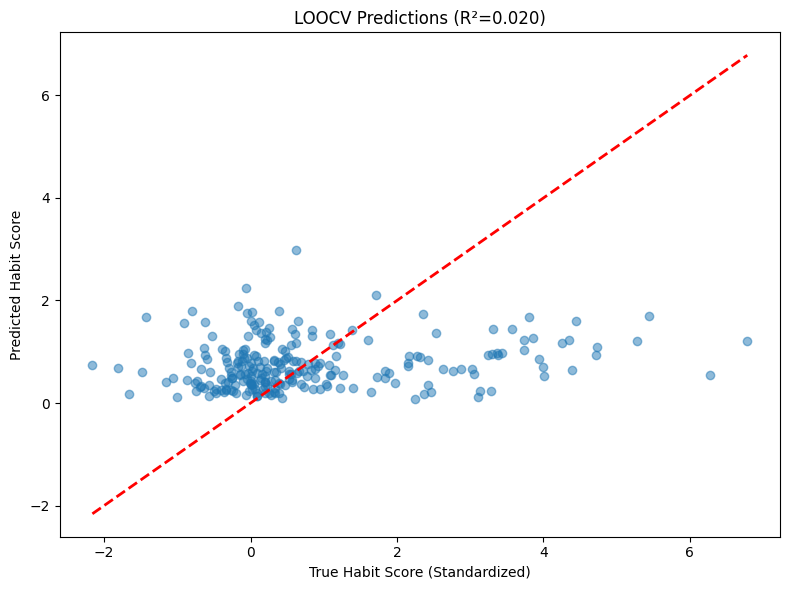


CONFIGURATION SELECTION FREQUENCY:


Model selection frequency:
  RandomForest: 244/244 folds (100.0%)

Number of features selected:
  all features: 244/244 folds (100.0%)

Most common configurations:
  RandomForest_nfeatall_n_estimators100_max_depth3_min_samples_leaf10: 92/244 folds (37.7%)
  RandomForest_nfeatall_n_estimators50_max_depth3_min_samples_leaf10: 47/244 folds (19.3%)
  RandomForest_nfeatall_n_estimators100_max_depth3_min_samples_leaf1: 27/244 folds (11.1%)
  RandomForest_nfeatall_n_estimators100_max_depth3_min_samples_leaf3: 23/244 folds (9.4%)
  RandomForest_nfeatall_n_estimators50_max_depth3_min_samples_leaf3: 14/244 folds (5.7%)

RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:
Model: RandomForest
Number of features: all
Hyperparameters: {'n_estimators': 100, 'max_depth': 3, 'min_samples_leaf': 10}


In [9]:
from collections import Counter
from sklearn.feature_selection import SelectKBest, f_classif
from joblib import Parallel, delayed
from itertools import product
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression  # CHANGE THIS


features_data = run1_features_df.copy().reset_index(drop=True)
# ============================================
# PREPARE DATA
# ============================================
block_df = features_data.copy()
y = block_df["behav_adaptation_SCORE"]
subjects = block_df["subID"].reset_index(drop=True)
sites = block_df["site"].reset_index(drop=True)
group = pd.Series(block_df["group"]).reset_index(drop=True)

drop_cols = {"subID", "group", "site", "behav_adaptation_SCORE", "isHabitual"}
X_cont = block_df.drop(columns=list(drop_cols))

# Convert to arrays FIRST (before splitting)
X_cont_arr_full = X_cont.values
y_arr_full = np.asarray(y).astype(float)  # Keep as float for regression
group_arr_full = group.values
subjects_arr_full = subjects.values
sites_arr_full = sites.values

print(f"Total n={len(y)}, mean={y.mean():.3f}, std={y.std():.3f}, group_vals={np.unique(group_arr_full)}")

# ============================================
# CREATE HELD-OUT TEST SET (20%)
# ============================================
# Stratify by site + group + outcome
y_binned = pd.qcut(y, q=3, labels=['T1', 'T2', 'T3'], duplicates='drop')
strat_labels = (sites.astype(str) + '_' + 
                group.astype(str) + '_' + 
                y_binned.astype(str))

train_idx, test_idx = train_test_split(
    np.arange(len(y_arr_full)),
    test_size=0.20,
    stratify=strat_labels,
    random_state=42
)

# ============================================
# TRAINING SET (for LOOCV nested CV)
# ============================================
X_cont_arr = X_cont_arr_full[train_idx]
# get the relevant df X_cont :
X_cont_main_tr_set = pd.DataFrame(X_cont_arr, columns=X_cont.columns)
y_arr = y_arr_full[train_idx]
subjects = pd.Series(subjects_arr_full[train_idx]).reset_index(drop=True)  # Convert back to Series for compatibility
group = pd.Series(group_arr_full[train_idx]).reset_index(drop=True)  # Convert back to Series for compatibility
group_arr = group.values

# ============================================
# HELD-OUT TEST SET (saved for final evaluation)
# ============================================
X_cont_arr_test_holdout = X_cont_arr_full[test_idx]
y_arr_test_holdout = y_arr_full[test_idx]
subjects_test_holdout = subjects_arr_full[test_idx]
group_arr_test_holdout = group_arr_full[test_idx]
sites_test_holdout = sites_arr_full[test_idx]

print(f"\n{'='*60}")
print(f"DATA SPLIT:")
print(f"{'='*60}")
print(f"Training set (for LOOCV): n={len(y_arr)}, mean={y_arr.mean():.3f}, std={y_arr.std():.3f}")
print(f"Held-out test set: n={len(y_arr_test_holdout)}, mean={y_arr_test_holdout.mean():.3f}, std={y_arr_test_holdout.std():.3f}")
print(f"\nStratification: Site + Group + Outcome")

# Check distributions
print(f"\nTraining set:")
print(f"  Groups: {np.unique(group_arr, return_counts=True)}")
print(f"  Sites: {np.unique(sites_arr_full[train_idx], return_counts=True)[0]}")

print(f"\nHeld-out test set:")
print(f"  Groups: {np.unique(group_arr_test_holdout, return_counts=True)}")
print(f"  Sites: {np.unique(sites_test_holdout, return_counts=True)[0]}")

# ============================================
# YOUR EXISTING LOOCV CODE STARTS HERE
# ============================================
print(f"\n{'='*60}")
print("RUNNING NESTED LOOCV ON TRAINING SET")
print(f"{'='*60}\n")

print(f"n={len(y_arr)}, mean={y_arr.mean():.3f}, std={y_arr.std():.3f}, group_vals={np.unique(group_arr)}")



# Models to test + # features + settings:
# ----------------------------------------
# models_to_test = {
#     # 'Ridge': {'model': LogisticRegression, 'params': {'penalty': ['l2'], 'C': [0.1, 1, 10], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     # 'Ridge': {'model': LogisticRegression, 'params': {'penalty': ['l2'], 'C': [0.1, 1], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     # 'Lasso': {'model': LogisticRegression, 'params': {'penalty': ['l1'], 'C': [0.1, 1, 10], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'probability': [True]}}, # VVV
#     # 'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
#     'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [100], 'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}}, # VVV
#     # 'XGBoost': {'model': XGBClassifier, 'params': {}},
#     # 'XGBoost': {'model': XGBClassifier, 'params': {'n_estimators': [100], 'max_depth': [3, 5], 'learning_rate': [0.01, 0.1], 'use_label_encoder': [False], 'eval_metric': ['logloss']}}, 
#     # add ElasticNet Logistic Regression
#     'ElasticNet': {'model': LogisticRegression, 'params': {'penalty': ['elasticnet'], 'C': [0.1, 1, 10], 'l1_ratio': [0, 0.5, 1], 'solver': ['saga'], 'max_iter': [1000]}}, # VVV
#     # 'LDA': {'model': LinearDiscriminantAnalysis, 'params': {}},
# }

models_to_test = {
    # 'ElasticNet': {'model': LogisticRegression, 'params': {'penalty': ['elasticnet'], 'C': [0.1, 1, 10], 'l1_ratio': [0, 0.5, 1], 'solver': ['saga'], 'max_iter': [1000]}},
    # 'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.01, 0.1], 'probability': [True]}},
    # 'LDA': {'model': LinearDiscriminantAnalysis, 'params': {}},
    # 'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'probability': [True]}},
    'RandomForest': {'model': RandomForestClassifier, 'params': {'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}},
    # 'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
}

models_to_test = {
    # 'LinearRegression': {'model': LinearRegression, 'params': {}},  # No regularization
    # 'Ridge': {'model': Ridge, 'params': {'alpha': [0.1, 1.0, 10.0]}},
    # 'Lasso': {'model': Lasso, 'params': {'alpha': [0.1, 1.0, 10.0], 'max_iter': [5000]}},
    # 'ElasticNet': {'model': ElasticNet, 'params': {'alpha': [0.1, 1.0, 10.0], 'l1_ratio': [0.5], 'max_iter': [5000]}},  # Only true elastic net
    # 'SVR_rbf': {'model': SVR, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.01, 0.1]}},
    # 'RandomForest': {'model': RandomForestRegressor, 'params':  {'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}},
    'RandomForest': {'model': RandomForestRegressor, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
}

n_inner_folds = 10
do_PCA = True
pca_var = 0.95
measure_to_pick_model = "accuracy"  # or "auc"
# measure_to_pick_model = "auc"  # or "accuracy"
measure_to_pick_model = "mse"  # or "mse"
measure_to_pick_model = "r2"  # or "mse"


# n_features_to_test = [3, max(2, n_features // 4), max(2, n_features // 2), max(3, int(n_features * 0.75)), n_features]
# n_features_to_test = [1, 2, 3,5,7,10,15,17, 'all']
n_features_to_test = [3,5,10,'all']
n_features_to_test = ['all']
# n_features_to_test = ['all']
# n_features_to_test = [3,5]


print(f"Total n={len(y_arr)}, positive={int(y_arr.sum())} ({y_arr.mean():.3f}), group_vals={np.unique(group_arr)}")

# X_cont_arr
# y_arr
# subjects
# group
# group_arr


# # Initialize variables
# # --------------------------------------
# y_true_all, y_pred_all, y_pred_proba_all, y_pred_proba_counterfactual_all, y_pred_counterfactual_all, y_pred_proba_counterfactual_x2_all, y_pred_counterfactual_x2_all, matching_group_all, matching_sub_all = [], [], [], [], [], [], [], [], []
# matching_group, matching_sub = [], []
# matching_group_all, matching_sub_all = [], []
# selected_configs = [] # to store configurations selected in each outer fold
# configs_data = {}
# # Run the Nested CV
# # --------------------------------------

# loo = LeaveOneOut()
# inner_cv = StratifiedKFold(n_splits=n_inner_folds, shuffle=True, random_state=42) VVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVV

def _process_outer_fold(fold_idx, train_index, test_index, X_cont_arr, y_arr, group_arr, 
                        subjects, group_series, models_to_test, n_features_to_test, 
                        n_inner_folds, measure_to_pick_model):
    
    configs_data_fold = {}
    
    # Split data (Outer)
    X_cont_train_Outer = X_cont_arr[train_index]
    X_cont_test_Outer = X_cont_arr[test_index]
    y_train_Outer = y_arr[train_index]
    y_test_Outer = y_arr[test_index]
    group_train_Outer = group_arr[train_index]
    group_test_Outer = group_arr[test_index]
    
    matching_sub = subjects.iloc[test_index[0]]
    matching_group = group_series.iloc[test_index[0]]

    # Inner CV - CHANGED to KFold for regression
    inner_cv = KFold(n_splits=n_inner_folds, shuffle=True, random_state=42)
    
    best_inner_score = -np.inf if measure_to_pick_model == "r2" else np.inf  # CHANGED
    best_config = None
    
    for model_name, model_dict in models_to_test.items():
        for n_feat in n_features_to_test:
            param_keys = list(model_dict['params'].keys())
            param_values = list(model_dict['params'].values())
            param_combinations = [dict(zip(param_keys, v)) for v in product(*param_values)]
            
            for params in param_combinations:
                inner_r2 = []
                inner_mse = []
                inner_mae = []
                
                for inner_train_idx, inner_test_idx in inner_cv.split(X_cont_train_Outer):  # CHANGED: removed y stratification
                    X_cont_train_Inner = X_cont_train_Outer[inner_train_idx]
                    X_cont_test_Inner = X_cont_train_Outer[inner_test_idx]
                    y_train_Inner = y_train_Outer[inner_train_idx]
                    y_test_Inner = y_train_Outer[inner_test_idx]
                    group_train_Inner = group_train_Outer[inner_train_idx]
                    group_test_Inner = group_train_Outer[inner_test_idx]

                    # Scale
                    scaler = StandardScaler().fit(X_cont_train_Inner)
                    X_cont_train_Inner_scaled = scaler.transform(X_cont_train_Inner)
                    X_cont_test_Inner_scaled = scaler.transform(X_cont_test_Inner)
                    
                    # Feature selection
                    n_features = X_cont_train_Inner_scaled.shape[1]
                    if n_feat != "all" and n_feat < n_features:
                        selector = SelectKBest(f_regression, k=n_feat)
                        X_cont_train_Inner_scaled = selector.fit_transform(X_cont_train_Inner_scaled, y_train_Inner)
                        X_cont_test_Inner_scaled = selector.transform(X_cont_test_Inner_scaled)

                    # PCA
                    if do_PCA:
                        pca = PCA(n_components=pca_var).fit(X_cont_train_Inner_scaled)
                        X_cont_train_Inner_pca = pca.transform(X_cont_train_Inner_scaled)
                        X_cont_test_Inner_pca = pca.transform(X_cont_test_Inner_scaled)
                    else:
                        X_cont_train_Inner_pca = X_cont_train_Inner_scaled
                        X_cont_test_Inner_pca = X_cont_test_Inner_scaled

                    # Add group
                    X_train_Inner = np.column_stack((group_train_Inner, X_cont_train_Inner_pca))
                    X_test_Inner = np.column_stack((group_test_Inner, X_cont_test_Inner_pca))

                    # Train model
                    if model_name in ['SVR_rbf', 'SVR', 'LinearRegression']:  # Add any other models without random_state
                        model = model_dict['model'](**params)
                    else:
                        model = model_dict['model'](**params, random_state=42)

                    model.fit(X_train_Inner, y_train_Inner)
                    
                    # Evaluate - CHANGED metrics
                    y_test_Inner_pred = model.predict(X_test_Inner)
                    inner_r2.append(r2_score(y_test_Inner, y_test_Inner_pred))
                    inner_mse.append(mean_squared_error(y_test_Inner, y_test_Inner_pred))
                    inner_mae.append(mean_absolute_error(y_test_Inner, y_test_Inner_pred))
                
                # Average performance
                mean_inner_r2 = np.mean(inner_r2)
                mean_inner_mse = np.mean(inner_mse)
                mean_inner_mae = np.mean(inner_mae)
                
                configs_data_fold[(fold_idx, model_name, n_feat, str(params))] = {
                    'model_name': model_name,
                    'model_class': model_dict['model'],
                    'params': params,
                    'n_features': n_feat,
                    'inner_cv_r2': mean_inner_r2,
                    'inner_cv_mse': mean_inner_mse,
                    'inner_cv_mae': mean_inner_mae,
                    'inner_cv_r2_list': inner_r2,
                    'inner_cv_mse_list': inner_mse,
                    'inner_cv_mae_list': inner_mae
                }
                
                # Select best config - CHANGED
                if measure_to_pick_model == "r2" and mean_inner_r2 > best_inner_score:
                    best_inner_score = mean_inner_r2
                    best_config = {
                        'model_name': model_name,
                        'model_class': model_dict['model'],
                        'params': params,
                        'n_features': n_feat,
                        'inner_cv_r2': mean_inner_r2,
                        'inner_cv_mse': mean_inner_mse,
                        'inner_cv_mae': mean_inner_mae
                    }
                elif measure_to_pick_model == "mse" and mean_inner_mse < best_inner_score:
                    best_inner_score = mean_inner_mse
                    best_config = {
                        'model_name': model_name,
                        'model_class': model_dict['model'],
                        'params': params,
                        'n_features': n_feat,
                        'inner_cv_r2': mean_inner_r2,
                        'inner_cv_mse': mean_inner_mse,
                        'inner_cv_mae': mean_inner_mae
                    }
    
    # Retrain on outer fold (same as before, but remove predict_proba calls)
    scaler = StandardScaler().fit(X_cont_train_Outer)
    X_cont_train_Outer_scaled = scaler.transform(X_cont_train_Outer)
    X_cont_test_Outer_scaled = scaler.transform(X_cont_test_Outer)
    
    n_features_outer = X_cont_train_Outer_scaled.shape[1]
    k_final = best_config["n_features"]
    if k_final == "all" or k_final >= n_features_outer:
        X_cont_train_Outer_scaled = X_cont_train_Outer_scaled
        X_cont_test_Outer_scaled = X_cont_test_Outer_scaled
    else:
        selector_final = SelectKBest(f_regression, k=best_config['n_features'])
        X_cont_train_Outer_scaled = selector_final.fit_transform(X_cont_train_Outer_scaled, y_train_Outer)
        X_cont_test_Outer_scaled = selector_final.transform(X_cont_test_Outer_scaled)
    
    if do_PCA:
        pca = PCA(n_components=pca_var).fit(X_cont_train_Outer_scaled)
        X_cont_train_Outer_pca = pca.transform(X_cont_train_Outer_scaled)
        X_cont_test_Outer_pca = pca.transform(X_cont_test_Outer_scaled)
    else:
        X_cont_train_Outer_pca = X_cont_train_Outer_scaled
        X_cont_test_Outer_pca = X_cont_test_Outer_scaled

    X_train_Outer = np.column_stack((group_train_Outer, X_cont_train_Outer_pca))
    X_test_Outer = np.column_stack((group_test_Outer, X_cont_test_Outer_pca))

    # Counterfactuals
    group_counterfactual_test_Outer = group_test_Outer.copy()
    group_counterfactual_test_Outer = np.where(group_counterfactual_test_Outer == -1, 1, 
                                                np.where(group_counterfactual_test_Outer == 1, -1, 
                                                        group_counterfactual_test_Outer))
    X_counterfactual_test_Outer = np.column_stack((group_counterfactual_test_Outer, X_cont_test_Outer_pca))
    
    group_counterfactual_cf_x2_test_Outer = group_test_Outer.copy()
    group_counterfactual_cf_x2_test_Outer[:] = 3
    X_counterfactual_cf_x2_test_Outer = np.column_stack((group_counterfactual_cf_x2_test_Outer, X_cont_test_Outer_pca))
    
    # Train final model
    if best_config['model_name'] in ['SVR_rbf', 'SVR', 'LinearRegression']:
        model_final = best_config['model_class'](**best_config['params'])
    else:
        model_final = best_config['model_class'](**best_config['params'], random_state=42)

    model_final.fit(X_train_Outer, y_train_Outer)

    # Predict - REMOVED predict_proba
    y_true = y_test_Outer[0]
    y_pred = model_final.predict(X_test_Outer)[0]
    
    # Counterfactual predictions - REMOVED predict_proba
    y_pred_cf = model_final.predict(X_counterfactual_test_Outer)[0]
    y_pred_cf_x2 = model_final.predict(X_counterfactual_cf_x2_test_Outer)[0]

    return {
        "fold_idx": fold_idx,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_pred_counterfactual": y_pred_cf,
        "y_pred_counterfactual_x2": y_pred_cf_x2,
        "matching_sub": matching_sub,
        "matching_group": matching_group,
        "best_config": best_config,
        "configs_data_fold": configs_data_fold,
    }
# Run the Nested CV in parallel over outer folds
loo = LeaveOneOut()
outer_splits = list(loo.split(X_cont_arr))

# n_jobs=-1 uses all cores; set to an int if you want to limit it.
results = Parallel(n_jobs=-1, prefer="processes")(
    delayed(_process_outer_fold)(
        fold_idx, train_index, test_index,
        X_cont_arr, y_arr, group_arr,
        subjects, group,
        models_to_test, n_features_to_test,
        n_inner_folds, measure_to_pick_model
    )
    for fold_idx, (train_index, test_index) in tqdm(list(enumerate(outer_splits)), total=len(outer_splits), desc="Outer CV folds")
)

# Aggregate in fold order
results = sorted(results, key=lambda d: d["fold_idx"])

# Merge configs_data from all folds
configs_data = {}
for r in results:
    configs_data.update(r["configs_data_fold"])

y_true_all = np.array([r["y_true"] for r in results], dtype=float)
y_pred_all = np.array([r["y_pred"] for r in results], dtype=float)
y_pred_counterfactual_all = np.array([r["y_pred_counterfactual"] for r in results], dtype=float)
y_pred_counterfactual_x2_all = np.array([r["y_pred_counterfactual_x2"] for r in results], dtype=float)

matching_sub_all = [r["matching_sub"] for r in results]
matching_group_all = [r["matching_group"] for r in results]
selected_configs = [r["best_config"] for r in results]

# ============================================
# COMPUTE FINAL METRICS
# ============================================
r2 = r2_score(y_true_all, y_pred_all)
mse = mean_squared_error(y_true_all, y_pred_all)
mae = mean_absolute_error(y_true_all, y_pred_all)
rmse = np.sqrt(mse)
pearson_r, pearson_p = pearsonr(y_true_all, y_pred_all)
spearman_r, spearman_p = spearmanr(y_true_all, y_pred_all)

print(f'\n{"="*60}')
print(f'NESTED LOOCV REGRESSION RESULTS:')
print(f'{"="*60}')
print(f'R²: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'Pearson r: {pearson_r:.4f} (p={pearson_p:.4f})')
print(f'Spearman r: {spearman_r:.4f} (p={spearman_p:.4f})')


# Optional: Plot predictions vs actual
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(y_true_all, y_pred_all, alpha=0.5)
plt.plot([y_true_all.min(), y_true_all.max()], 
         [y_true_all.min(), y_true_all.max()], 'r--', lw=2)
plt.xlabel('True Habit Score (Standardized)')
plt.ylabel('Predicted Habit Score')
plt.title(f'LOOCV Predictions (R²={r2:.3f})')
plt.tight_layout()
plt.show()

# ============================================
# ANALYZE CONFIGURATION STABILITY
# ============================================

print(f'\n{"============================================================"}')
print(f'CONFIGURATION SELECTION FREQUENCY:')
print(f'\n{"============================================================"}')

# Count model selections
model_counts = Counter([c['model_name'] for c in selected_configs])
print(f'\nModel selection frequency:')
for model, count in model_counts.most_common():
    print(f'  {model}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# Count n_features selections
nfeat_counts = Counter([c['n_features'] for c in selected_configs])
print(f'\nNumber of features selected:')
for nfeat, count in nfeat_counts.most_common():
    print(f'  {nfeat} features: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# Most common hyperparameters
print(f'\nMost common configurations:')
config_strings = [f"{c['model_name']}_nfeat{c['n_features']}_" + "_".join([f"{k}{v}" for k, v in c['params'].items() if k not in ['probability', 'solver', 'max_iter', 'random_state']]) for c in selected_configs]
config_counts = Counter(config_strings)
for config, count in config_counts.most_common(5):
    print(f'  {config}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# ============================================
# DETERMINE "BEST" CONFIGURATION FOR DEPLOYMENT
# ============================================
# Use most common configuration
most_common_model = model_counts.most_common(1)[0][0]
most_common_nfeat = nfeat_counts.most_common(1)[0][0]

# For this model, find most common hyperparameters
configs_for_model = [c for c in selected_configs if c['model_name'] == most_common_model]

# Get most common hyperparameter values
best_deployment_config = {
    'model_name': most_common_model,
    'n_features': most_common_nfeat,
    'params': {}
}

for key in configs_for_model[0]['params'].keys():
    param_values = [c['params'][key] for c in configs_for_model]
    best_deployment_config['params'][key] = Counter(param_values).most_common(1)[0][0]

print(f'\n{"="*60}')
print(f'RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:')
print(f'{"="*60}')
print(f'Model: {best_deployment_config["model_name"]}')
print(f'Number of features: {best_deployment_config["n_features"]}')
print(f'Hyperparameters: {best_deployment_config["params"]}')

# # ============================================
# # TRAIN FINAL MODEL ON ALL DATA
# # ============================================

# print(f'\n{"="*60}')
# print(f'Training final model on all data...')
# print(f'{"="*60}')

# # Get model class
# model_class = models_to_test[best_deployment_config['model_name']]['model']

# # Feature selection on all data
# if best_deployment_config['n_features'] < n_features:
#     selector_all = SelectKBest(f_classif, k=best_deployment_config['n_features'])
#     X_all_sel = selector_all.fit_transform(X, y)
#     selected_feature_indices = selector_all.get_support(indices=True)
#     selected_features = X.columns[selected_feature_indices]
#     print(f'Selected features: {list(selected_features)}')
# else:
#     X_all_sel = X.values
#     selected_features = X.columns
#     print(f'Using all features')

# # Train final model
# model_all = model_class(**best_deployment_config['params'], random_state=42)
# model_all.fit(X_all_sel, y)

# # Feature importance
# print(f'\nComputing feature importance...')
# feature_importance = permutation_importance(model_all, X_all_sel, y, n_repeats=100, random_state=42)

# # # ============================================
# # # RETURN RESULTS
# # # ============================================

# # results = {
# #     # Performance metrics
# #     'accuracy': accuracy,
# #     'auc_score': auc_score,
# #     'conf_matrix': conf_matrix,
# #     'fpr': fpr,
# #     'tpr': tpr,
# #     'thresholds': thresholds,
    
# #     # Predictions
# #     'y_true': y_true_all,
# #     'y_pred': y_pred_all,
# #     'y_pred_proba': y_pred_proba_all,
# #     'y_pred_proba_counterfactual': np.array(y_pred_proba_counterfactual_all) if X_counterfactual is not None else None,
# #     'y_pred_counterfactual': np.array(y_pred_counterfactual_all) if X_counterfactual is not None else None,
# #     'y_pred_proba_counterfactual_x2': np.array(y_pred_proba_counterfactual_x2_all) if X_counterfactual is not None else None,
# #     'y_pred_counterfactual_x2': np.array(y_pred_counterfactual_x2_all) if X_counterfactual is not None else None,
    
# #     # Metadata
# #     'matching_group': matching_group_all,
# #     'matching_sub': matching_sub_all,
    
# #     # Configuration info
# #     'selected_configs': selected_configs,
# #     'model_counts': model_counts,
# #     'nfeat_counts': nfeat_counts,
# #     'best_deployment_config': best_deployment_config,
    
# #     # Final model trained on all data
# #     'model_all': model_all,
# #     'feature_importance': feature_importance,
# #     'selected_features': selected_features,
# # }




# - Now with AUC
# aaaaaaaaaaaaaa


Total n=306, mean=0.745, std=1.481, group_vals=[-1  1]

DATA SPLIT:
Training set (for LOOCV): n=244, mean=0.764, std=1.488
Held-out test set: n=62, mean=0.670, std=1.440

Stratification: Site + Group + Outcome

Training set:
  Groups: (array([-1,  1]), array([119, 125]))
  Sites: ['Caltech1' 'Caltech2' 'Hamburg' 'Sydney' 'Tel_Aviv']

Held-out test set:
  Groups: (array([-1,  1]), array([30, 32]))
  Sites: ['Caltech1' 'Caltech2' 'Hamburg' 'Sydney' 'Tel_Aviv']

RUNNING NESTED LOOCV ON TRAINING SET

n=244, mean=0.764, std=1.488, group_vals=[-1  1]
Total n=244, positive=186 (0.764), group_vals=[-1  1]


Outer CV folds: 100%|██████████| 244/244 [06:16<00:00,  1.55s/it]



NESTED LOOCV REGRESSION RESULTS:
R²: 0.0122
RMSE: 1.4791
MAE: 1.1025
Pearson r: 0.2166 (p=0.0007)
Spearman r: 0.1695 (p=0.0080)


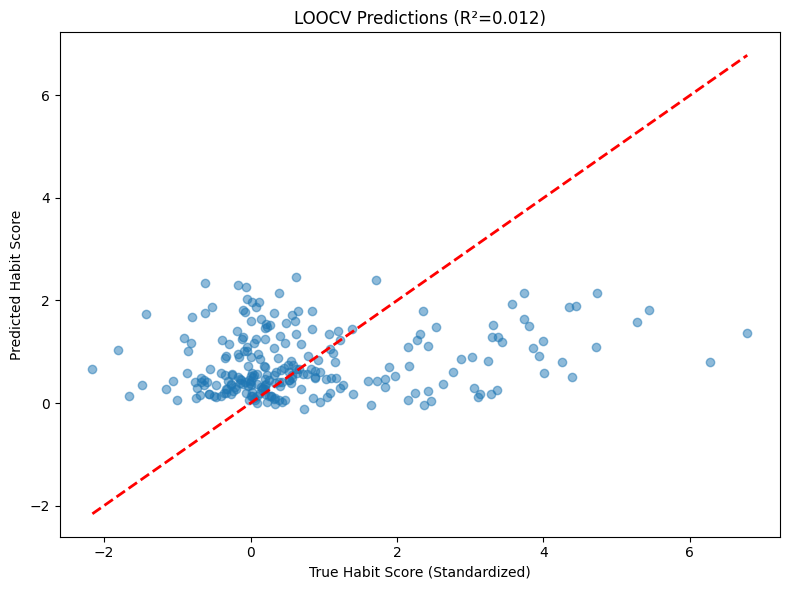


CONFIGURATION SELECTION FREQUENCY:


Model selection frequency:
  RandomForest: 244/244 folds (100.0%)

Number of features selected:
  3 features: 157/244 folds (64.3%)
  5 features: 66/244 folds (27.0%)
  10 features: 21/244 folds (8.6%)

Most common configurations:
  RandomForest_nfeat3_max_depth5_min_samples_leaf10: 96/244 folds (39.3%)
  RandomForest_nfeat3_max_depth10_min_samples_leaf10: 61/244 folds (25.0%)
  RandomForest_nfeat5_max_depth5_min_samples_leaf10: 51/244 folds (20.9%)
  RandomForest_nfeat10_max_depth5_min_samples_leaf10: 18/244 folds (7.4%)
  RandomForest_nfeat5_max_depth10_min_samples_leaf10: 13/244 folds (5.3%)

RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:
Model: RandomForest
Number of features: 3
Hyperparameters: {'max_depth': 5, 'min_samples_leaf': 10}


In [ ]:
from collections import Counter
from sklearn.feature_selection import SelectKBest, f_classif
from joblib import Parallel, delayed
from itertools import product
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression  # CHANGE THIS


features_data = run1_features_df.copy().reset_index(drop=True)
# ============================================
# PREPARE DATA
# ============================================
block_df = features_data.copy()
y = block_df["behav_adaptation_SCORE"]
subjects = block_df["subID"].reset_index(drop=True)
sites = block_df["site"].reset_index(drop=True)
group = pd.Series(block_df["group"]).reset_index(drop=True)

drop_cols = {"subID", "group", "site", "behav_adaptation_SCORE", "isHabitual"}
X_cont = block_df.drop(columns=list(drop_cols))

# Convert to arrays FIRST (before splitting)
X_cont_arr_full = X_cont.values
y_arr_full = np.asarray(y).astype(float)  # Keep as float for regression
group_arr_full = group.values
subjects_arr_full = subjects.values
sites_arr_full = sites.values

print(f"Total n={len(y)}, mean={y.mean():.3f}, std={y.std():.3f}, group_vals={np.unique(group_arr_full)}")

# ============================================
# CREATE HELD-OUT TEST SET (20%)
# ============================================
# Stratify by site + group + outcome
y_binned = pd.qcut(y, q=3, labels=['T1', 'T2', 'T3'], duplicates='drop')
strat_labels = (sites.astype(str) + '_' + 
                group.astype(str) + '_' + 
                y_binned.astype(str))

train_idx, test_idx = train_test_split(
    np.arange(len(y_arr_full)),
    test_size=0.20,
    stratify=strat_labels,
    random_state=42
)

# ============================================
# TRAINING SET (for LOOCV nested CV)
# ============================================
X_cont_arr = X_cont_arr_full[train_idx]
# get the relevant df X_cont :
X_cont_main_tr_set = pd.DataFrame(X_cont_arr, columns=X_cont.columns)
y_arr = y_arr_full[train_idx]
subjects = pd.Series(subjects_arr_full[train_idx]).reset_index(drop=True)  # Convert back to Series for compatibility
group = pd.Series(group_arr_full[train_idx]).reset_index(drop=True)  # Convert back to Series for compatibility
group_arr = group.values

# ============================================
# HELD-OUT TEST SET (saved for final evaluation)
# ============================================
X_cont_arr_test_holdout = X_cont_arr_full[test_idx]
y_arr_test_holdout = y_arr_full[test_idx]
subjects_test_holdout = subjects_arr_full[test_idx]
group_arr_test_holdout = group_arr_full[test_idx]
sites_test_holdout = sites_arr_full[test_idx]

print(f"\n{'='*60}")
print(f"DATA SPLIT:")
print(f"{'='*60}")
print(f"Training set (for LOOCV): n={len(y_arr)}, mean={y_arr.mean():.3f}, std={y_arr.std():.3f}")
print(f"Held-out test set: n={len(y_arr_test_holdout)}, mean={y_arr_test_holdout.mean():.3f}, std={y_arr_test_holdout.std():.3f}")
print(f"\nStratification: Site + Group + Outcome")

# Check distributions
print(f"\nTraining set:")
print(f"  Groups: {np.unique(group_arr, return_counts=True)}")
print(f"  Sites: {np.unique(sites_arr_full[train_idx], return_counts=True)[0]}")

print(f"\nHeld-out test set:")
print(f"  Groups: {np.unique(group_arr_test_holdout, return_counts=True)}")
print(f"  Sites: {np.unique(sites_test_holdout, return_counts=True)[0]}")

# ============================================
# YOUR EXISTING LOOCV CODE STARTS HERE
# ============================================
print(f"\n{'='*60}")
print("RUNNING NESTED LOOCV ON TRAINING SET")
print(f"{'='*60}\n")

print(f"n={len(y_arr)}, mean={y_arr.mean():.3f}, std={y_arr.std():.3f}, group_vals={np.unique(group_arr)}")



# Models to test + # features + settings:
# ----------------------------------------
# models_to_test = {
#     # 'Ridge': {'model': LogisticRegression, 'params': {'penalty': ['l2'], 'C': [0.1, 1, 10], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     # 'Ridge': {'model': LogisticRegression, 'params': {'penalty': ['l2'], 'C': [0.1, 1], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     # 'Lasso': {'model': LogisticRegression, 'params': {'penalty': ['l1'], 'C': [0.1, 1, 10], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'probability': [True]}}, # VVV
#     # 'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
#     'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [100], 'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}}, # VVV
#     # 'XGBoost': {'model': XGBClassifier, 'params': {}},
#     # 'XGBoost': {'model': XGBClassifier, 'params': {'n_estimators': [100], 'max_depth': [3, 5], 'learning_rate': [0.01, 0.1], 'use_label_encoder': [False], 'eval_metric': ['logloss']}}, 
#     # add ElasticNet Logistic Regression
#     'ElasticNet': {'model': LogisticRegression, 'params': {'penalty': ['elasticnet'], 'C': [0.1, 1, 10], 'l1_ratio': [0, 0.5, 1], 'solver': ['saga'], 'max_iter': [1000]}}, # VVV
#     # 'LDA': {'model': LinearDiscriminantAnalysis, 'params': {}},
# }

models_to_test = {
    # 'ElasticNet': {'model': LogisticRegression, 'params': {'penalty': ['elasticnet'], 'C': [0.1, 1, 10], 'l1_ratio': [0, 0.5, 1], 'solver': ['saga'], 'max_iter': [1000]}},
    # 'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.01, 0.1], 'probability': [True]}},
    # 'LDA': {'model': LinearDiscriminantAnalysis, 'params': {}},
    # 'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'probability': [True]}},
    'RandomForest': {'model': RandomForestClassifier, 'params': {'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}},
    # 'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
}

models_to_test = {
    # 'LinearRegression': {'model': LinearRegression, 'params': {}},  # No regularization
    'Ridge': {'model': Ridge, 'params': {'alpha': [0.1, 1.0, 10.0]}},
    'Lasso': {'model': Lasso, 'params': {'alpha': [0.1, 1.0, 10.0], 'max_iter': [5000]}},
    'ElasticNet': {'model': ElasticNet, 'params': {'alpha': [0.1, 1.0, 10.0], 'l1_ratio': [0.5], 'max_iter': [5000]}},  # Only true elastic net
    'SVR_rbf': {'model': SVR, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.01, 0.1]}},
    'RandomForest': {'model': RandomForestRegressor, 'params':  {'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}},
    # 'RandomForest': {'model': RandomForestRegressor, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
}

n_inner_folds = 10
do_PCA = True
pca_var = 0.95
measure_to_pick_model = "accuracy"  # or "auc"
# measure_to_pick_model = "auc"  # or "accuracy"
measure_to_pick_model = "mse"  # or "mse"
measure_to_pick_model = "r2"  # or "mse"


# n_features_to_test = [3, max(2, n_features // 4), max(2, n_features // 2), max(3, int(n_features * 0.75)), n_features]
# n_features_to_test = [1, 2, 3,5,7,10,15,17, 'all']
n_features_to_test = [3,5,10,'all']
# n_features_to_test = ['all']
# n_features_to_test = ['all']
# n_features_to_test = [3,5]


print(f"Total n={len(y_arr)}, positive={int(y_arr.sum())} ({y_arr.mean():.3f}), group_vals={np.unique(group_arr)}")

# X_cont_arr
# y_arr
# subjects
# group
# group_arr


# # Initialize variables
# # --------------------------------------
# y_true_all, y_pred_all, y_pred_proba_all, y_pred_proba_counterfactual_all, y_pred_counterfactual_all, y_pred_proba_counterfactual_x2_all, y_pred_counterfactual_x2_all, matching_group_all, matching_sub_all = [], [], [], [], [], [], [], [], []
# matching_group, matching_sub = [], []
# matching_group_all, matching_sub_all = [], []
# selected_configs = [] # to store configurations selected in each outer fold
# configs_data = {}
# # Run the Nested CV
# # --------------------------------------

# loo = LeaveOneOut()
# inner_cv = StratifiedKFold(n_splits=n_inner_folds, shuffle=True, random_state=42) VVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVV

def _process_outer_fold(fold_idx, train_index, test_index, X_cont_arr, y_arr, group_arr, 
                        subjects, group_series, models_to_test, n_features_to_test, 
                        n_inner_folds, measure_to_pick_model):
    
    configs_data_fold = {}
    
    # Split data (Outer)
    X_cont_train_Outer = X_cont_arr[train_index]
    X_cont_test_Outer = X_cont_arr[test_index]
    y_train_Outer = y_arr[train_index]
    y_test_Outer = y_arr[test_index]
    group_train_Outer = group_arr[train_index]
    group_test_Outer = group_arr[test_index]
    
    matching_sub = subjects.iloc[test_index[0]]
    matching_group = group_series.iloc[test_index[0]]

    # Inner CV - CHANGED to KFold for regression
    inner_cv = KFold(n_splits=n_inner_folds, shuffle=True, random_state=42)
    
    best_inner_score = -np.inf if measure_to_pick_model == "r2" else np.inf  # CHANGED
    best_config = None
    
    for model_name, model_dict in models_to_test.items():
        for n_feat in n_features_to_test:
            param_keys = list(model_dict['params'].keys())
            param_values = list(model_dict['params'].values())
            param_combinations = [dict(zip(param_keys, v)) for v in product(*param_values)]
            
            for params in param_combinations:
                inner_r2 = []
                inner_mse = []
                inner_mae = []
                
                for inner_train_idx, inner_test_idx in inner_cv.split(X_cont_train_Outer):  # CHANGED: removed y stratification
                    X_cont_train_Inner = X_cont_train_Outer[inner_train_idx]
                    X_cont_test_Inner = X_cont_train_Outer[inner_test_idx]
                    y_train_Inner = y_train_Outer[inner_train_idx]
                    y_test_Inner = y_train_Outer[inner_test_idx]
                    group_train_Inner = group_train_Outer[inner_train_idx]
                    group_test_Inner = group_train_Outer[inner_test_idx]

                    # Scale
                    scaler = StandardScaler().fit(X_cont_train_Inner)
                    X_cont_train_Inner_scaled = scaler.transform(X_cont_train_Inner)
                    X_cont_test_Inner_scaled = scaler.transform(X_cont_test_Inner)
                    
                    # # Feature selection
                    # n_features = X_cont_train_Inner_scaled.shape[1]
                    # if n_feat != "all" and n_feat < n_features:
                    #     selector = SelectKBest(f_regression, k=n_feat)
                    #     X_cont_train_Inner_scaled = selector.fit_transform(X_cont_train_Inner_scaled, y_train_Inner)
                    #     X_cont_test_Inner_scaled = selector.transform(X_cont_test_Inner_scaled)

                    # # PCA
                    # if do_PCA:
                    #     pca = PCA(n_components=pca_var).fit(X_cont_train_Inner_scaled)
                    #     X_cont_train_Inner_pca = pca.transform(X_cont_train_Inner_scaled)
                    #     X_cont_test_Inner_pca = pca.transform(X_cont_test_Inner_scaled)
                    # else:
                    #     X_cont_train_Inner_pca = X_cont_train_Inner_scaled
                    #     X_cont_test_Inner_pca = X_cont_test_Inner_scaled


                    # PCA on Inner TRAIN only (BEFORE SelectKBest)
                    if do_PCA:
                        pca = PCA(n_components=pca_var).fit(X_cont_train_Inner_scaled)
                        X_cont_train_Inner_pca = pca.transform(X_cont_train_Inner_scaled)
                        X_cont_test_Inner_pca = pca.transform(X_cont_test_Inner_scaled)
                    else:
                        X_cont_train_Inner_pca = X_cont_train_Inner_scaled
                        X_cont_test_Inner_pca = X_cont_test_Inner_scaled

                    # Feature selection (AFTER PCA)
                    n_features = X_cont_train_Inner_pca.shape[1]
                    if n_feat != "all" and n_feat < n_features:
                        selector = SelectKBest(f_regression, k=n_feat)
                        X_cont_train_Inner_pca = selector.fit_transform(X_cont_train_Inner_pca, y_train_Inner)
                        X_cont_test_Inner_pca = selector.transform(X_cont_test_Inner_pca)


                    # Add group
                    X_train_Inner = np.column_stack((group_train_Inner, X_cont_train_Inner_pca))
                    X_test_Inner = np.column_stack((group_test_Inner, X_cont_test_Inner_pca))

                    # Train model
                    if model_name in ['SVR_rbf', 'SVR', 'LinearRegression']:  # Add any other models without random_state
                        model = model_dict['model'](**params)
                    else:
                        model = model_dict['model'](**params, random_state=42)

                    model.fit(X_train_Inner, y_train_Inner)
                    
                    # Evaluate - CHANGED metrics
                    y_test_Inner_pred = model.predict(X_test_Inner)
                    inner_r2.append(r2_score(y_test_Inner, y_test_Inner_pred))
                    inner_mse.append(mean_squared_error(y_test_Inner, y_test_Inner_pred))
                    inner_mae.append(mean_absolute_error(y_test_Inner, y_test_Inner_pred))
                
                # Average performance
                mean_inner_r2 = np.mean(inner_r2)
                mean_inner_mse = np.mean(inner_mse)
                mean_inner_mae = np.mean(inner_mae)
                
                configs_data_fold[(fold_idx, model_name, n_feat, str(params))] = {
                    'model_name': model_name,
                    'model_class': model_dict['model'],
                    'params': params,
                    'n_features': n_feat,
                    'inner_cv_r2': mean_inner_r2,
                    'inner_cv_mse': mean_inner_mse,
                    'inner_cv_mae': mean_inner_mae,
                    'inner_cv_r2_list': inner_r2,
                    'inner_cv_mse_list': inner_mse,
                    'inner_cv_mae_list': inner_mae
                }
                
                # Select best config - CHANGED
                if measure_to_pick_model == "r2" and mean_inner_r2 > best_inner_score:
                    best_inner_score = mean_inner_r2
                    best_config = {
                        'model_name': model_name,
                        'model_class': model_dict['model'],
                        'params': params,
                        'n_features': n_feat,
                        'inner_cv_r2': mean_inner_r2,
                        'inner_cv_mse': mean_inner_mse,
                        'inner_cv_mae': mean_inner_mae
                    }
                elif measure_to_pick_model == "mse" and mean_inner_mse < best_inner_score:
                    best_inner_score = mean_inner_mse
                    best_config = {
                        'model_name': model_name,
                        'model_class': model_dict['model'],
                        'params': params,
                        'n_features': n_feat,
                        'inner_cv_r2': mean_inner_r2,
                        'inner_cv_mse': mean_inner_mse,
                        'inner_cv_mae': mean_inner_mae
                    }
    
    # Retrain on outer fold (same as before, but remove predict_proba calls)
    scaler = StandardScaler().fit(X_cont_train_Outer)
    X_cont_train_Outer_scaled = scaler.transform(X_cont_train_Outer)
    X_cont_test_Outer_scaled = scaler.transform(X_cont_test_Outer)
    
    # n_features_outer = X_cont_train_Outer_scaled.shape[1]
    # k_final = best_config["n_features"]
    # if k_final == "all" or k_final >= n_features_outer:
    #     X_cont_train_Outer_scaled = X_cont_train_Outer_scaled
    #     X_cont_test_Outer_scaled = X_cont_test_Outer_scaled
    # else:
    #     selector_final = SelectKBest(f_regression, k=best_config['n_features'])
    #     X_cont_train_Outer_scaled = selector_final.fit_transform(X_cont_train_Outer_scaled, y_train_Outer)
    #     X_cont_test_Outer_scaled = selector_final.transform(X_cont_test_Outer_scaled)
    
    # if do_PCA:
    #     pca = PCA(n_components=pca_var).fit(X_cont_train_Outer_scaled)
    #     X_cont_train_Outer_pca = pca.transform(X_cont_train_Outer_scaled)
    #     X_cont_test_Outer_pca = pca.transform(X_cont_test_Outer_scaled)
    # else:
    #     X_cont_train_Outer_pca = X_cont_train_Outer_scaled
    #     X_cont_test_Outer_pca = X_cont_test_Outer_scaled
        
    # PCA on Outer TRAIN only (BEFORE SelectKBest)
    if do_PCA:
        pca = PCA(n_components=pca_var).fit(X_cont_train_Outer_scaled)
        X_cont_train_Outer_pca = pca.transform(X_cont_train_Outer_scaled)
        X_cont_test_Outer_pca = pca.transform(X_cont_test_Outer_scaled)
    else:
        X_cont_train_Outer_pca = X_cont_train_Outer_scaled
        X_cont_test_Outer_pca = X_cont_test_Outer_scaled
    
    # Feature selection (AFTER PCA)
    n_features_outer = X_cont_train_Outer_pca.shape[1]
    k_final = best_config["n_features"]
    if k_final == "all" or k_final >= n_features_outer:
        X_cont_train_Outer_pca = X_cont_train_Outer_pca
        X_cont_test_Outer_pca = X_cont_test_Outer_pca
    else:
        selector_final = SelectKBest(f_regression, k=best_config['n_features'])
        X_cont_train_Outer_pca = selector_final.fit_transform(X_cont_train_Outer_pca, y_train_Outer)
        X_cont_test_Outer_pca = selector_final.transform(X_cont_test_Outer_pca)

    X_train_Outer = np.column_stack((group_train_Outer, X_cont_train_Outer_pca))
    X_test_Outer = np.column_stack((group_test_Outer, X_cont_test_Outer_pca))

    # Counterfactuals
    group_counterfactual_test_Outer = group_test_Outer.copy()
    group_counterfactual_test_Outer = np.where(group_counterfactual_test_Outer == -1, 1, 
                                                np.where(group_counterfactual_test_Outer == 1, -1, 
                                                        group_counterfactual_test_Outer))
    X_counterfactual_test_Outer = np.column_stack((group_counterfactual_test_Outer, X_cont_test_Outer_pca))
    
    group_counterfactual_cf_x2_test_Outer = group_test_Outer.copy()
    group_counterfactual_cf_x2_test_Outer[:] = 3
    X_counterfactual_cf_x2_test_Outer = np.column_stack((group_counterfactual_cf_x2_test_Outer, X_cont_test_Outer_pca))
    
    # Train final model
    if best_config['model_name'] in ['SVR_rbf', 'SVR', 'LinearRegression']:
        model_final = best_config['model_class'](**best_config['params'])
    else:
        model_final = best_config['model_class'](**best_config['params'], random_state=42)

    model_final.fit(X_train_Outer, y_train_Outer)

    # Predict - REMOVED predict_proba
    y_true = y_test_Outer[0]
    y_pred = model_final.predict(X_test_Outer)[0]
    
    # Counterfactual predictions - REMOVED predict_proba
    y_pred_cf = model_final.predict(X_counterfactual_test_Outer)[0]
    y_pred_cf_x2 = model_final.predict(X_counterfactual_cf_x2_test_Outer)[0]

    return {
        "fold_idx": fold_idx,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_pred_counterfactual": y_pred_cf,
        "y_pred_counterfactual_x2": y_pred_cf_x2,
        "matching_sub": matching_sub,
        "matching_group": matching_group,
        "best_config": best_config,
        "configs_data_fold": configs_data_fold,
    }
# Run the Nested CV in parallel over outer folds
loo = LeaveOneOut()
outer_splits = list(loo.split(X_cont_arr))

# n_jobs=-1 uses all cores; set to an int if you want to limit it.
results = Parallel(n_jobs=-1, prefer="processes")(
    delayed(_process_outer_fold)(
        fold_idx, train_index, test_index,
        X_cont_arr, y_arr, group_arr,
        subjects, group,
        models_to_test, n_features_to_test,
        n_inner_folds, measure_to_pick_model
    )
    for fold_idx, (train_index, test_index) in tqdm(list(enumerate(outer_splits)), total=len(outer_splits), desc="Outer CV folds")
)

# Aggregate in fold order
results = sorted(results, key=lambda d: d["fold_idx"])

# Merge configs_data from all folds
configs_data = {}
for r in results:
    configs_data.update(r["configs_data_fold"])

y_true_all = np.array([r["y_true"] for r in results], dtype=float)
y_pred_all = np.array([r["y_pred"] for r in results], dtype=float)
y_pred_counterfactual_all = np.array([r["y_pred_counterfactual"] for r in results], dtype=float)
y_pred_counterfactual_x2_all = np.array([r["y_pred_counterfactual_x2"] for r in results], dtype=float)

matching_sub_all = [r["matching_sub"] for r in results]
matching_group_all = [r["matching_group"] for r in results]
selected_configs = [r["best_config"] for r in results]

# ============================================
# COMPUTE FINAL METRICS
# ============================================
r2 = r2_score(y_true_all, y_pred_all)
mse = mean_squared_error(y_true_all, y_pred_all)
mae = mean_absolute_error(y_true_all, y_pred_all)
rmse = np.sqrt(mse)
pearson_r, pearson_p = pearsonr(y_true_all, y_pred_all)
spearman_r, spearman_p = spearmanr(y_true_all, y_pred_all)

print(f'\n{"="*60}')
print(f'NESTED LOOCV REGRESSION RESULTS:')
print(f'{"="*60}')
print(f'R²: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'Pearson r: {pearson_r:.4f} (p={pearson_p:.4f})')
print(f'Spearman r: {spearman_r:.4f} (p={spearman_p:.4f})')


# Optional: Plot predictions vs actual
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(y_true_all, y_pred_all, alpha=0.5)
plt.plot([y_true_all.min(), y_true_all.max()], 
         [y_true_all.min(), y_true_all.max()], 'r--', lw=2)
plt.xlabel('True Habit Score (Standardized)')
plt.ylabel('Predicted Habit Score')
plt.title(f'LOOCV Predictions (R²={r2:.3f})')
plt.tight_layout()
plt.show()

# ============================================
# ANALYZE CONFIGURATION STABILITY
# ============================================

print(f'\n{"============================================================"}')
print(f'CONFIGURATION SELECTION FREQUENCY:')
print(f'\n{"============================================================"}')

# Count model selections
model_counts = Counter([c['model_name'] for c in selected_configs])
print(f'\nModel selection frequency:')
for model, count in model_counts.most_common():
    print(f'  {model}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# Count n_features selections
nfeat_counts = Counter([c['n_features'] for c in selected_configs])
print(f'\nNumber of features selected:')
for nfeat, count in nfeat_counts.most_common():
    print(f'  {nfeat} features: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# Most common hyperparameters
print(f'\nMost common configurations:')
config_strings = [f"{c['model_name']}_nfeat{c['n_features']}_" + "_".join([f"{k}{v}" for k, v in c['params'].items() if k not in ['probability', 'solver', 'max_iter', 'random_state']]) for c in selected_configs]
config_counts = Counter(config_strings)
for config, count in config_counts.most_common(5):
    print(f'  {config}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# ============================================
# DETERMINE "BEST" CONFIGURATION FOR DEPLOYMENT
# ============================================
# Use most common configuration
most_common_model = model_counts.most_common(1)[0][0]
most_common_nfeat = nfeat_counts.most_common(1)[0][0]

# For this model, find most common hyperparameters
configs_for_model = [c for c in selected_configs if c['model_name'] == most_common_model]

# Get most common hyperparameter values
best_deployment_config = {
    'model_name': most_common_model,
    'n_features': most_common_nfeat,
    'params': {}
}

for key in configs_for_model[0]['params'].keys():
    param_values = [c['params'][key] for c in configs_for_model]
    best_deployment_config['params'][key] = Counter(param_values).most_common(1)[0][0]

print(f'\n{"="*60}')
print(f'RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:')
print(f'{"="*60}')
print(f'Model: {best_deployment_config["model_name"]}')
print(f'Number of features: {best_deployment_config["n_features"]}')
print(f'Hyperparameters: {best_deployment_config["params"]}')

# # ============================================
# # TRAIN FINAL MODEL ON ALL DATA
# # ============================================

# print(f'\n{"="*60}')
# print(f'Training final model on all data...')
# print(f'{"="*60}')

# # Get model class
# model_class = models_to_test[best_deployment_config['model_name']]['model']

# # Feature selection on all data
# if best_deployment_config['n_features'] < n_features:
#     selector_all = SelectKBest(f_classif, k=best_deployment_config['n_features'])
#     X_all_sel = selector_all.fit_transform(X, y)
#     selected_feature_indices = selector_all.get_support(indices=True)
#     selected_features = X.columns[selected_feature_indices]
#     print(f'Selected features: {list(selected_features)}')
# else:
#     X_all_sel = X.values
#     selected_features = X.columns
#     print(f'Using all features')

# # Train final model
# model_all = model_class(**best_deployment_config['params'], random_state=42)
# model_all.fit(X_all_sel, y)

# # Feature importance
# print(f'\nComputing feature importance...')
# feature_importance = permutation_importance(model_all, X_all_sel, y, n_repeats=100, random_state=42)

# # # ============================================
# # # RETURN RESULTS
# # # ============================================

# # results = {
# #     # Performance metrics
# #     'accuracy': accuracy,
# #     'auc_score': auc_score,
# #     'conf_matrix': conf_matrix,
# #     'fpr': fpr,
# #     'tpr': tpr,
# #     'thresholds': thresholds,
    
# #     # Predictions
# #     'y_true': y_true_all,
# #     'y_pred': y_pred_all,
# #     'y_pred_proba': y_pred_proba_all,
# #     'y_pred_proba_counterfactual': np.array(y_pred_proba_counterfactual_all) if X_counterfactual is not None else None,
# #     'y_pred_counterfactual': np.array(y_pred_counterfactual_all) if X_counterfactual is not None else None,
# #     'y_pred_proba_counterfactual_x2': np.array(y_pred_proba_counterfactual_x2_all) if X_counterfactual is not None else None,
# #     'y_pred_counterfactual_x2': np.array(y_pred_counterfactual_x2_all) if X_counterfactual is not None else None,
    
# #     # Metadata
# #     'matching_group': matching_group_all,
# #     'matching_sub': matching_sub_all,
    
# #     # Configuration info
# #     'selected_configs': selected_configs,
# #     'model_counts': model_counts,
# #     'nfeat_counts': nfeat_counts,
# #     'best_deployment_config': best_deployment_config,
    
# #     # Final model trained on all data
# #     'model_all': model_all,
# #     'feature_importance': feature_importance,
# #     'selected_features': selected_features,
# # }




# - Now with AUC
# aaaaaaaaaaaaaa



EVALUATING ON HELD-OUT TEST SET

Held-out test set results (n=62):
R²: 0.0387
RMSE: 1.4119
MAE: 1.0233
Pearson r: 0.2195 (p=0.0864)
Spearman r: 0.2936 (p=0.0206)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:109: RuntimeWarning: divide by zero encountered in divide
  msw = sswn / float(dfwn)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:109: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)


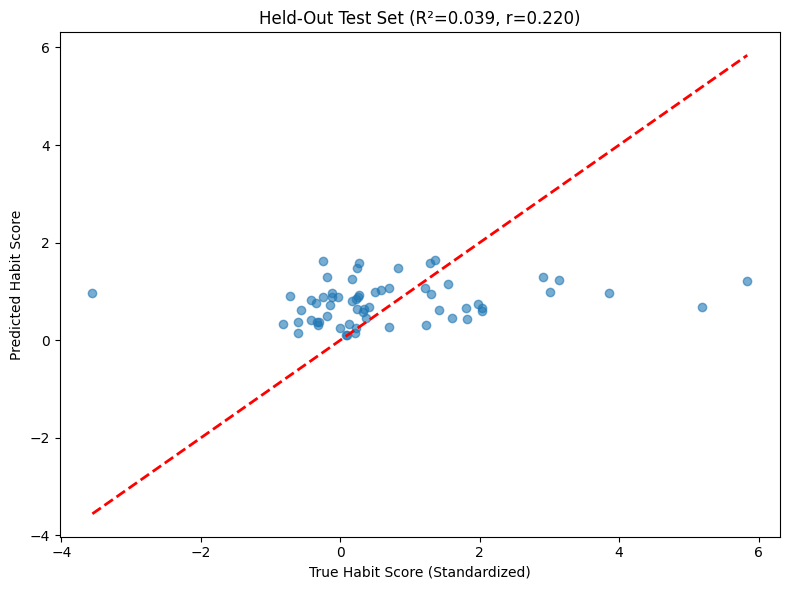

In [26]:
# Add this after your LOOCV results:

print(f"\n{'='*60}")
print("EVALUATING ON HELD-OUT TEST SET")
print(f"{'='*60}")

# Preprocess held-out set same way as training
scaler_final = StandardScaler().fit(X_cont_arr)
X_train_scaled = scaler_final.transform(X_cont_arr)
X_test_scaled = scaler_final.transform(X_cont_arr_test_holdout)

# Feature selection if needed
if best_deployment_config['n_features'] != 'all':
    selector_final = SelectKBest(f_classif, k=best_deployment_config['n_features'])
    X_train_selected = selector_final.fit_transform(X_train_scaled, y_arr)
    X_test_selected = selector_final.transform(X_test_scaled)
else:
    X_train_selected = X_train_scaled
    X_test_selected = X_test_scaled

# PCA if needed
if do_PCA:
    pca_final = PCA(n_components=pca_var).fit(X_train_selected)
    X_train_pca = pca_final.transform(X_train_selected)
    X_test_pca = pca_final.transform(X_test_selected)
else:
    X_train_pca = X_train_selected
    X_test_pca = X_test_selected

# Add group back
X_train_final = np.column_stack((group_arr, X_train_pca))
X_test_final = np.column_stack((group_arr_test_holdout, X_test_pca))

# Train final model on all training data
model_class = models_to_test[best_deployment_config['model_name']]['model']
if best_deployment_config['model_name'] in ['SVR_rbf', 'SVR']:
    final_model = model_class(**best_deployment_config['params'])
else:
    final_model = model_class(**best_deployment_config['params'], random_state=42)

final_model.fit(X_train_final, y_arr)

# Predict on held-out
y_pred_holdout = final_model.predict(X_test_final)

# Compute metrics
r2_holdout = r2_score(y_arr_test_holdout, y_pred_holdout)
rmse_holdout = np.sqrt(mean_squared_error(y_arr_test_holdout, y_pred_holdout))
mae_holdout = mean_absolute_error(y_arr_test_holdout, y_pred_holdout)
pearson_r_holdout, pearson_p_holdout = pearsonr(y_arr_test_holdout, y_pred_holdout)
spearman_r_holdout, spearman_p_holdout = spearmanr(y_arr_test_holdout, y_pred_holdout)

print(f"\nHeld-out test set results (n={len(y_arr_test_holdout)}):")
print(f"R²: {r2_holdout:.4f}")
print(f"RMSE: {rmse_holdout:.4f}")
print(f"MAE: {mae_holdout:.4f}")
print(f"Pearson r: {pearson_r_holdout:.4f} (p={pearson_p_holdout:.4f})")
print(f"Spearman r: {spearman_r_holdout:.4f} (p={spearman_p_holdout:.4f})")

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_arr_test_holdout, y_pred_holdout, alpha=0.6)
plt.plot([y_arr_test_holdout.min(), y_arr_test_holdout.max()],
         [y_arr_test_holdout.min(), y_arr_test_holdout.max()], 'r--', lw=2)
plt.xlabel('True Habit Score (Standardized)')
plt.ylabel('Predicted Habit Score')
plt.title(f'Held-Out Test Set (R²={r2_holdout:.3f}, r={pearson_r_holdout:.3f})')
plt.tight_layout()
plt.show()


On all - only LOOCV

Total n=306, mean=0.745, std=1.481, group_vals=[-1  1]

DATA SPLIT:
Training set (for LOOCV): n=306, mean=0.745, std=1.479
Held-out test set: n=62, mean=0.670, std=1.440

Stratification: Site + Group + Outcome

Training set:
  Groups: (array([-1,  1]), array([149, 157]))
  Sites: ['Caltech1' 'Caltech2' 'Hamburg' 'Sydney' 'Tel_Aviv']

Held-out test set:
  Groups: (array([-1,  1]), array([30, 32]))
  Sites: ['Caltech1' 'Caltech2' 'Hamburg' 'Sydney' 'Tel_Aviv']

RUNNING NESTED LOOCV ON TRAINING SET

n=306, mean=0.745, std=1.479, group_vals=[-1  1]
Total n=306, positive=227 (0.745), group_vals=[-1  1]


Outer CV folds: 100%|██████████| 306/306 [00:09<00:00, 33.22it/s]



NESTED LOOCV REGRESSION RESULTS:
R²: 0.0478
RMSE: 1.4432
MAE: 1.0651
Pearson r: 0.2200 (p=0.0001)
Spearman r: 0.1738 (p=0.0023)


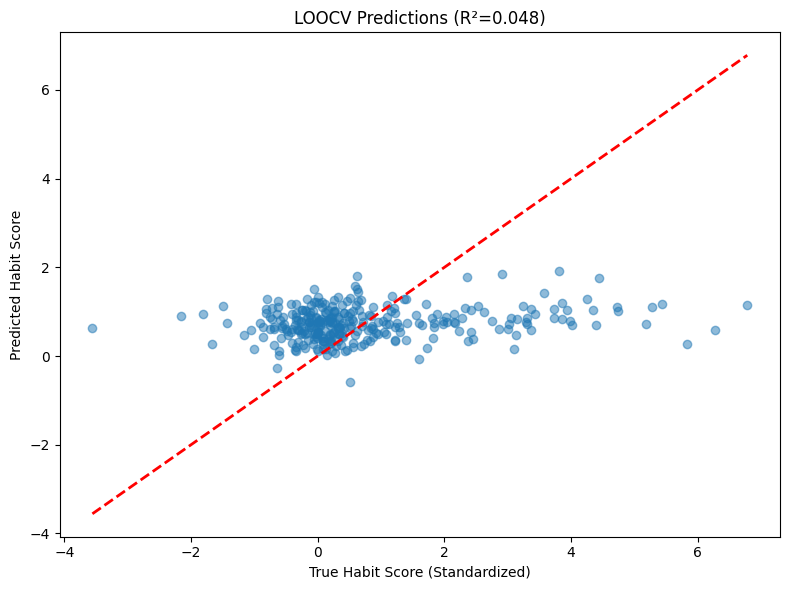


CONFIGURATION SELECTION FREQUENCY:


Model selection frequency:
  ElasticNet: 306/306 folds (100.0%)

Number of features selected:
  10 features: 261/306 folds (85.3%)
  5 features: 43/306 folds (14.1%)
  3 features: 2/306 folds (0.7%)

Most common configurations:
  ElasticNet_nfeat10_alpha0.1_l1_ratio0.5: 261/306 folds (85.3%)
  ElasticNet_nfeat5_alpha0.1_l1_ratio0.5: 43/306 folds (14.1%)
  ElasticNet_nfeat3_alpha0.1_l1_ratio0.5: 2/306 folds (0.7%)

RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:
Model: ElasticNet
Number of features: 10
Hyperparameters: {'alpha': 0.1, 'l1_ratio': 0.5, 'max_iter': 5000}


In [22]:
from collections import Counter
from sklearn.feature_selection import SelectKBest, f_classif
from joblib import Parallel, delayed
from itertools import product
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold
from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression  # CHANGE THIS


features_data = run1_features_df.copy().reset_index(drop=True)
# ============================================
# PREPARE DATA
# ============================================
block_df = features_data.copy()
y = block_df["behav_adaptation_SCORE"]
subjects = block_df["subID"].reset_index(drop=True)
sites = block_df["site"].reset_index(drop=True)
group = pd.Series(block_df["group"]).reset_index(drop=True)

drop_cols = {"subID", "group", "site", "behav_adaptation_SCORE", "isHabitual"}
X_cont = block_df.drop(columns=list(drop_cols))

# Convert to arrays FIRST (before splitting)
X_cont_arr_full = X_cont.values
y_arr_full = np.asarray(y).astype(float)  # Keep as float for regression
group_arr_full = group.values
subjects_arr_full = subjects.values
sites_arr_full = sites.values

print(f"Total n={len(y)}, mean={y.mean():.3f}, std={y.std():.3f}, group_vals={np.unique(group_arr_full)}")

# ============================================
# CREATE HELD-OUT TEST SET (20%)
# ============================================
# Stratify by site + group + outcome
y_binned = pd.qcut(y, q=3, labels=['T1', 'T2', 'T3'], duplicates='drop')
strat_labels = (sites.astype(str) + '_' + 
                group.astype(str) + '_' + 
                y_binned.astype(str))

train_idx, test_idx = train_test_split(
    np.arange(len(y_arr_full)),
    test_size=0.20,
    stratify=strat_labels,
    random_state=42
)

# ============================================
# TRAINING SET (for LOOCV nested CV)
# ============================================
X_cont_arr = X_cont_arr_full
# get the relevant df X_cont :
X_cont_main_tr_set = pd.DataFrame(X_cont_arr, columns=X_cont.columns)
y_arr = y_arr_full
subjects = pd.Series(subjects_arr_full).reset_index(drop=True)  # Convert back to Series for compatibility
group = pd.Series(group_arr_full).reset_index(drop=True)  # Convert back to Series for compatibility
group_arr = group.values


print(f"\n{'='*60}")
print(f"DATA SPLIT:")
print(f"{'='*60}")
print(f"Training set (for LOOCV): n={len(y_arr)}, mean={y_arr.mean():.3f}, std={y_arr.std():.3f}")
print(f"Held-out test set: n={len(y_arr_test_holdout)}, mean={y_arr_test_holdout.mean():.3f}, std={y_arr_test_holdout.std():.3f}")
print(f"\nStratification: Site + Group + Outcome")

# Check distributions
print(f"\nTraining set:")
print(f"  Groups: {np.unique(group_arr, return_counts=True)}")
print(f"  Sites: {np.unique(sites_arr_full[train_idx], return_counts=True)[0]}")

print(f"\nHeld-out test set:")
print(f"  Groups: {np.unique(group_arr_test_holdout, return_counts=True)}")
print(f"  Sites: {np.unique(sites_test_holdout, return_counts=True)[0]}")

# ============================================
# YOUR EXISTING LOOCV CODE STARTS HERE
# ============================================
print(f"\n{'='*60}")
print("RUNNING NESTED LOOCV ON TRAINING SET")
print(f"{'='*60}\n")

print(f"n={len(y_arr)}, mean={y_arr.mean():.3f}, std={y_arr.std():.3f}, group_vals={np.unique(group_arr)}")



# Models to test + # features + settings:
# ----------------------------------------
# models_to_test = {
#     # 'Ridge': {'model': LogisticRegression, 'params': {'penalty': ['l2'], 'C': [0.1, 1, 10], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     # 'Ridge': {'model': LogisticRegression, 'params': {'penalty': ['l2'], 'C': [0.1, 1], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     # 'Lasso': {'model': LogisticRegression, 'params': {'penalty': ['l1'], 'C': [0.1, 1, 10], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'probability': [True]}}, # VVV
#     # 'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
#     'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [100], 'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}}, # VVV
#     # 'XGBoost': {'model': XGBClassifier, 'params': {}},
#     # 'XGBoost': {'model': XGBClassifier, 'params': {'n_estimators': [100], 'max_depth': [3, 5], 'learning_rate': [0.01, 0.1], 'use_label_encoder': [False], 'eval_metric': ['logloss']}}, 
#     # add ElasticNet Logistic Regression
#     'ElasticNet': {'model': LogisticRegression, 'params': {'penalty': ['elasticnet'], 'C': [0.1, 1, 10], 'l1_ratio': [0, 0.5, 1], 'solver': ['saga'], 'max_iter': [1000]}}, # VVV
#     # 'LDA': {'model': LinearDiscriminantAnalysis, 'params': {}},
# }

models_to_test = {
    # 'ElasticNet': {'model': LogisticRegression, 'params': {'penalty': ['elasticnet'], 'C': [0.1, 1, 10], 'l1_ratio': [0, 0.5, 1], 'solver': ['saga'], 'max_iter': [1000]}},
    # 'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.01, 0.1], 'probability': [True]}},
    # 'LDA': {'model': LinearDiscriminantAnalysis, 'params': {}},
    # 'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'probability': [True]}},
    'RandomForest': {'model': RandomForestClassifier, 'params': {'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}},
    # 'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
}

models_to_test = {
    # 'LinearRegression': {'model': LinearRegression, 'params': {}},  # No regularization
    # 'Ridge': {'model': Ridge, 'params': {'alpha': [0.1, 1.0, 10.0]}},
    # 'Lasso': {'model': Lasso, 'params': {'alpha': [0.1, 1.0, 10.0], 'max_iter': [5000]}},
    'ElasticNet': {'model': ElasticNet, 'params': {'alpha': [0.1, 1.0, 10.0], 'l1_ratio': [0.5], 'max_iter': [5000]}},  # Only true elastic net
    # 'SVR_rbf': {'model': SVR, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.01, 0.1]}},
    # 'RandomForest': {'model': RandomForestRegressor, 'params':  {'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}},
    # 'RandomForest': {'model': RandomForestRegressor, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
}

n_inner_folds = 10
do_PCA = True
pca_var = 0.95
measure_to_pick_model = "accuracy"  # or "auc"
# measure_to_pick_model = "auc"  # or "accuracy"
measure_to_pick_model = "mse"  # or "mse"
measure_to_pick_model = "r2"  # or "mse"


# n_features_to_test = [3, max(2, n_features // 4), max(2, n_features // 2), max(3, int(n_features * 0.75)), n_features]
# n_features_to_test = [1, 2, 3,5,7,10,15,17, 'all']
n_features_to_test = [3,5,10,'all']
# n_features_to_test = ['all']
# n_features_to_test = ['all']
# n_features_to_test = [3,5]


print(f"Total n={len(y_arr)}, positive={int(y_arr.sum())} ({y_arr.mean():.3f}), group_vals={np.unique(group_arr)}")

# X_cont_arr
# y_arr
# subjects
# group
# group_arr


# # Initialize variables
# # --------------------------------------
# y_true_all, y_pred_all, y_pred_proba_all, y_pred_proba_counterfactual_all, y_pred_counterfactual_all, y_pred_proba_counterfactual_x2_all, y_pred_counterfactual_x2_all, matching_group_all, matching_sub_all = [], [], [], [], [], [], [], [], []
# matching_group, matching_sub = [], []
# matching_group_all, matching_sub_all = [], []
# selected_configs = [] # to store configurations selected in each outer fold
# configs_data = {}
# # Run the Nested CV
# # --------------------------------------

# loo = LeaveOneOut()
# inner_cv = StratifiedKFold(n_splits=n_inner_folds, shuffle=True, random_state=42) VVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVV

def _process_outer_fold(fold_idx, train_index, test_index, X_cont_arr, y_arr, group_arr, 
                        subjects, group_series, models_to_test, n_features_to_test, 
                        n_inner_folds, measure_to_pick_model):
    
    configs_data_fold = {}
    
    # Split data (Outer)
    X_cont_train_Outer = X_cont_arr[train_index]
    X_cont_test_Outer = X_cont_arr[test_index]
    y_train_Outer = y_arr[train_index]
    y_test_Outer = y_arr[test_index]
    group_train_Outer = group_arr[train_index]
    group_test_Outer = group_arr[test_index]
    
    matching_sub = subjects.iloc[test_index[0]]
    matching_group = group_series.iloc[test_index[0]]

    # Inner CV - CHANGED to KFold for regression
    inner_cv = KFold(n_splits=n_inner_folds, shuffle=True, random_state=42)
    
    best_inner_score = -np.inf if measure_to_pick_model == "r2" else np.inf  # CHANGED
    best_config = None
    
    for model_name, model_dict in models_to_test.items():
        for n_feat in n_features_to_test:
            param_keys = list(model_dict['params'].keys())
            param_values = list(model_dict['params'].values())
            param_combinations = [dict(zip(param_keys, v)) for v in product(*param_values)]
            
            for params in param_combinations:
                inner_r2 = []
                inner_mse = []
                inner_mae = []
                
                for inner_train_idx, inner_test_idx in inner_cv.split(X_cont_train_Outer):  # CHANGED: removed y stratification
                    X_cont_train_Inner = X_cont_train_Outer[inner_train_idx]
                    X_cont_test_Inner = X_cont_train_Outer[inner_test_idx]
                    y_train_Inner = y_train_Outer[inner_train_idx]
                    y_test_Inner = y_train_Outer[inner_test_idx]
                    group_train_Inner = group_train_Outer[inner_train_idx]
                    group_test_Inner = group_train_Outer[inner_test_idx]

                    # Scale
                    scaler = StandardScaler().fit(X_cont_train_Inner)
                    X_cont_train_Inner_scaled = scaler.transform(X_cont_train_Inner)
                    X_cont_test_Inner_scaled = scaler.transform(X_cont_test_Inner)
                    
                    # # Feature selection
                    # n_features = X_cont_train_Inner_scaled.shape[1]
                    # if n_feat != "all" and n_feat < n_features:
                    #     selector = SelectKBest(f_regression, k=n_feat)
                    #     X_cont_train_Inner_scaled = selector.fit_transform(X_cont_train_Inner_scaled, y_train_Inner)
                    #     X_cont_test_Inner_scaled = selector.transform(X_cont_test_Inner_scaled)

                    # # PCA
                    # if do_PCA:
                    #     pca = PCA(n_components=pca_var).fit(X_cont_train_Inner_scaled)
                    #     X_cont_train_Inner_pca = pca.transform(X_cont_train_Inner_scaled)
                    #     X_cont_test_Inner_pca = pca.transform(X_cont_test_Inner_scaled)
                    # else:
                    #     X_cont_train_Inner_pca = X_cont_train_Inner_scaled
                    #     X_cont_test_Inner_pca = X_cont_test_Inner_scaled


                    # PCA on Inner TRAIN only (BEFORE SelectKBest)
                    if do_PCA:
                        pca = PCA(n_components=pca_var).fit(X_cont_train_Inner_scaled)
                        X_cont_train_Inner_pca = pca.transform(X_cont_train_Inner_scaled)
                        X_cont_test_Inner_pca = pca.transform(X_cont_test_Inner_scaled)
                    else:
                        X_cont_train_Inner_pca = X_cont_train_Inner_scaled
                        X_cont_test_Inner_pca = X_cont_test_Inner_scaled

                    # Feature selection (AFTER PCA)
                    n_features = X_cont_train_Inner_pca.shape[1]
                    if n_feat != "all" and n_feat < n_features:
                        selector = SelectKBest(f_regression, k=n_feat)
                        X_cont_train_Inner_pca = selector.fit_transform(X_cont_train_Inner_pca, y_train_Inner)
                        X_cont_test_Inner_pca = selector.transform(X_cont_test_Inner_pca)


                    # Add group
                    X_train_Inner = np.column_stack((group_train_Inner, X_cont_train_Inner_pca))
                    X_test_Inner = np.column_stack((group_test_Inner, X_cont_test_Inner_pca))

                    # Train model
                    if model_name in ['SVR_rbf', 'SVR', 'LinearRegression']:  # Add any other models without random_state
                        model = model_dict['model'](**params)
                    else:
                        model = model_dict['model'](**params, random_state=42)

                    model.fit(X_train_Inner, y_train_Inner)
                    
                    # Evaluate - CHANGED metrics
                    y_test_Inner_pred = model.predict(X_test_Inner)
                    inner_r2.append(r2_score(y_test_Inner, y_test_Inner_pred))
                    inner_mse.append(mean_squared_error(y_test_Inner, y_test_Inner_pred))
                    inner_mae.append(mean_absolute_error(y_test_Inner, y_test_Inner_pred))
                
                # Average performance
                mean_inner_r2 = np.mean(inner_r2)
                mean_inner_mse = np.mean(inner_mse)
                mean_inner_mae = np.mean(inner_mae)
                
                configs_data_fold[(fold_idx, model_name, n_feat, str(params))] = {
                    'model_name': model_name,
                    'model_class': model_dict['model'],
                    'params': params,
                    'n_features': n_feat,
                    'inner_cv_r2': mean_inner_r2,
                    'inner_cv_mse': mean_inner_mse,
                    'inner_cv_mae': mean_inner_mae,
                    'inner_cv_r2_list': inner_r2,
                    'inner_cv_mse_list': inner_mse,
                    'inner_cv_mae_list': inner_mae
                }
                
                # Select best config - CHANGED
                if measure_to_pick_model == "r2" and mean_inner_r2 > best_inner_score:
                    best_inner_score = mean_inner_r2
                    best_config = {
                        'model_name': model_name,
                        'model_class': model_dict['model'],
                        'params': params,
                        'n_features': n_feat,
                        'inner_cv_r2': mean_inner_r2,
                        'inner_cv_mse': mean_inner_mse,
                        'inner_cv_mae': mean_inner_mae
                    }
                elif measure_to_pick_model == "mse" and mean_inner_mse < best_inner_score:
                    best_inner_score = mean_inner_mse
                    best_config = {
                        'model_name': model_name,
                        'model_class': model_dict['model'],
                        'params': params,
                        'n_features': n_feat,
                        'inner_cv_r2': mean_inner_r2,
                        'inner_cv_mse': mean_inner_mse,
                        'inner_cv_mae': mean_inner_mae
                    }
    
    # Retrain on outer fold (same as before, but remove predict_proba calls)
    scaler = StandardScaler().fit(X_cont_train_Outer)
    X_cont_train_Outer_scaled = scaler.transform(X_cont_train_Outer)
    X_cont_test_Outer_scaled = scaler.transform(X_cont_test_Outer)
    
    # n_features_outer = X_cont_train_Outer_scaled.shape[1]
    # k_final = best_config["n_features"]
    # if k_final == "all" or k_final >= n_features_outer:
    #     X_cont_train_Outer_scaled = X_cont_train_Outer_scaled
    #     X_cont_test_Outer_scaled = X_cont_test_Outer_scaled
    # else:
    #     selector_final = SelectKBest(f_regression, k=best_config['n_features'])
    #     X_cont_train_Outer_scaled = selector_final.fit_transform(X_cont_train_Outer_scaled, y_train_Outer)
    #     X_cont_test_Outer_scaled = selector_final.transform(X_cont_test_Outer_scaled)
    
    # if do_PCA:
    #     pca = PCA(n_components=pca_var).fit(X_cont_train_Outer_scaled)
    #     X_cont_train_Outer_pca = pca.transform(X_cont_train_Outer_scaled)
    #     X_cont_test_Outer_pca = pca.transform(X_cont_test_Outer_scaled)
    # else:
    #     X_cont_train_Outer_pca = X_cont_train_Outer_scaled
    #     X_cont_test_Outer_pca = X_cont_test_Outer_scaled
        
    # PCA on Outer TRAIN only (BEFORE SelectKBest)
    if do_PCA:
        pca = PCA(n_components=pca_var).fit(X_cont_train_Outer_scaled)
        X_cont_train_Outer_pca = pca.transform(X_cont_train_Outer_scaled)
        X_cont_test_Outer_pca = pca.transform(X_cont_test_Outer_scaled)
    else:
        X_cont_train_Outer_pca = X_cont_train_Outer_scaled
        X_cont_test_Outer_pca = X_cont_test_Outer_scaled
    
    # Feature selection (AFTER PCA)
    n_features_outer = X_cont_train_Outer_pca.shape[1]
    k_final = best_config["n_features"]
    if k_final == "all" or k_final >= n_features_outer:
        X_cont_train_Outer_pca = X_cont_train_Outer_pca
        X_cont_test_Outer_pca = X_cont_test_Outer_pca
    else:
        selector_final = SelectKBest(f_regression, k=best_config['n_features'])
        X_cont_train_Outer_pca = selector_final.fit_transform(X_cont_train_Outer_pca, y_train_Outer)
        X_cont_test_Outer_pca = selector_final.transform(X_cont_test_Outer_pca)

    X_train_Outer = np.column_stack((group_train_Outer, X_cont_train_Outer_pca))
    X_test_Outer = np.column_stack((group_test_Outer, X_cont_test_Outer_pca))

    # Counterfactuals
    group_counterfactual_test_Outer = group_test_Outer.copy()
    group_counterfactual_test_Outer = np.where(group_counterfactual_test_Outer == -1, 1, 
                                                np.where(group_counterfactual_test_Outer == 1, -1, 
                                                        group_counterfactual_test_Outer))
    X_counterfactual_test_Outer = np.column_stack((group_counterfactual_test_Outer, X_cont_test_Outer_pca))
    
    group_counterfactual_cf_x2_test_Outer = group_test_Outer.copy()
    group_counterfactual_cf_x2_test_Outer[:] = 3
    X_counterfactual_cf_x2_test_Outer = np.column_stack((group_counterfactual_cf_x2_test_Outer, X_cont_test_Outer_pca))
    
    # Train final model
    if best_config['model_name'] in ['SVR_rbf', 'SVR', 'LinearRegression']:
        model_final = best_config['model_class'](**best_config['params'])
    else:
        model_final = best_config['model_class'](**best_config['params'], random_state=42)

    model_final.fit(X_train_Outer, y_train_Outer)

    # Predict - REMOVED predict_proba
    y_true = y_test_Outer[0]
    y_pred = model_final.predict(X_test_Outer)[0]
    
    # Counterfactual predictions - REMOVED predict_proba
    y_pred_cf = model_final.predict(X_counterfactual_test_Outer)[0]
    y_pred_cf_x2 = model_final.predict(X_counterfactual_cf_x2_test_Outer)[0]

    return {
        "fold_idx": fold_idx,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_pred_counterfactual": y_pred_cf,
        "y_pred_counterfactual_x2": y_pred_cf_x2,
        "matching_sub": matching_sub,
        "matching_group": matching_group,
        "best_config": best_config,
        "configs_data_fold": configs_data_fold,
    }
# Run the Nested CV in parallel over outer folds
loo = LeaveOneOut()
outer_splits = list(loo.split(X_cont_arr))

# n_jobs=-1 uses all cores; set to an int if you want to limit it.
results = Parallel(n_jobs=-1, prefer="processes")(
    delayed(_process_outer_fold)(
        fold_idx, train_index, test_index,
        X_cont_arr, y_arr, group_arr,
        subjects, group,
        models_to_test, n_features_to_test,
        n_inner_folds, measure_to_pick_model
    )
    for fold_idx, (train_index, test_index) in tqdm(list(enumerate(outer_splits)), total=len(outer_splits), desc="Outer CV folds")
)

# Aggregate in fold order
results = sorted(results, key=lambda d: d["fold_idx"])

# Merge configs_data from all folds
configs_data = {}
for r in results:
    configs_data.update(r["configs_data_fold"])

y_true_all = np.array([r["y_true"] for r in results], dtype=float)
y_pred_all = np.array([r["y_pred"] for r in results], dtype=float)
y_pred_counterfactual_all = np.array([r["y_pred_counterfactual"] for r in results], dtype=float)
y_pred_counterfactual_x2_all = np.array([r["y_pred_counterfactual_x2"] for r in results], dtype=float)

matching_sub_all = [r["matching_sub"] for r in results]
matching_group_all = [r["matching_group"] for r in results]
selected_configs = [r["best_config"] for r in results]

# ============================================
# COMPUTE FINAL METRICS
# ============================================
r2 = r2_score(y_true_all, y_pred_all)
mse = mean_squared_error(y_true_all, y_pred_all)
mae = mean_absolute_error(y_true_all, y_pred_all)
rmse = np.sqrt(mse)
pearson_r, pearson_p = pearsonr(y_true_all, y_pred_all)
spearman_r, spearman_p = spearmanr(y_true_all, y_pred_all)

print(f'\n{"="*60}')
print(f'NESTED LOOCV REGRESSION RESULTS:')
print(f'{"="*60}')
print(f'R²: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'Pearson r: {pearson_r:.4f} (p={pearson_p:.4f})')
print(f'Spearman r: {spearman_r:.4f} (p={spearman_p:.4f})')


# Optional: Plot predictions vs actual
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(y_true_all, y_pred_all, alpha=0.5)
plt.plot([y_true_all.min(), y_true_all.max()], 
         [y_true_all.min(), y_true_all.max()], 'r--', lw=2)
plt.xlabel('True Habit Score (Standardized)')
plt.ylabel('Predicted Habit Score')
plt.title(f'LOOCV Predictions (R²={r2:.3f})')
plt.tight_layout()
plt.show()

# ============================================
# ANALYZE CONFIGURATION STABILITY
# ============================================

print(f'\n{"============================================================"}')
print(f'CONFIGURATION SELECTION FREQUENCY:')
print(f'\n{"============================================================"}')

# Count model selections
model_counts = Counter([c['model_name'] for c in selected_configs])
print(f'\nModel selection frequency:')
for model, count in model_counts.most_common():
    print(f'  {model}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# Count n_features selections
nfeat_counts = Counter([c['n_features'] for c in selected_configs])
print(f'\nNumber of features selected:')
for nfeat, count in nfeat_counts.most_common():
    print(f'  {nfeat} features: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# Most common hyperparameters
print(f'\nMost common configurations:')
config_strings = [f"{c['model_name']}_nfeat{c['n_features']}_" + "_".join([f"{k}{v}" for k, v in c['params'].items() if k not in ['probability', 'solver', 'max_iter', 'random_state']]) for c in selected_configs]
config_counts = Counter(config_strings)
for config, count in config_counts.most_common(5):
    print(f'  {config}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# ============================================
# DETERMINE "BEST" CONFIGURATION FOR DEPLOYMENT
# ============================================
# Use most common configuration
most_common_model = model_counts.most_common(1)[0][0]
most_common_nfeat = nfeat_counts.most_common(1)[0][0]

# For this model, find most common hyperparameters
configs_for_model = [c for c in selected_configs if c['model_name'] == most_common_model]

# Get most common hyperparameter values
best_deployment_config = {
    'model_name': most_common_model,
    'n_features': most_common_nfeat,
    'params': {}
}

for key in configs_for_model[0]['params'].keys():
    param_values = [c['params'][key] for c in configs_for_model]
    best_deployment_config['params'][key] = Counter(param_values).most_common(1)[0][0]

print(f'\n{"="*60}')
print(f'RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:')
print(f'{"="*60}')
print(f'Model: {best_deployment_config["model_name"]}')
print(f'Number of features: {best_deployment_config["n_features"]}')
print(f'Hyperparameters: {best_deployment_config["params"]}')

# # ============================================
# # TRAIN FINAL MODEL ON ALL DATA
# # ============================================

# print(f'\n{"="*60}')
# print(f'Training final model on all data...')
# print(f'{"="*60}')

# # Get model class
# model_class = models_to_test[best_deployment_config['model_name']]['model']

# # Feature selection on all data
# if best_deployment_config['n_features'] < n_features:
#     selector_all = SelectKBest(f_classif, k=best_deployment_config['n_features'])
#     X_all_sel = selector_all.fit_transform(X, y)
#     selected_feature_indices = selector_all.get_support(indices=True)
#     selected_features = X.columns[selected_feature_indices]
#     print(f'Selected features: {list(selected_features)}')
# else:
#     X_all_sel = X.values
#     selected_features = X.columns
#     print(f'Using all features')

# # Train final model
# model_all = model_class(**best_deployment_config['params'], random_state=42)
# model_all.fit(X_all_sel, y)

# # Feature importance
# print(f'\nComputing feature importance...')
# feature_importance = permutation_importance(model_all, X_all_sel, y, n_repeats=100, random_state=42)

# # # ============================================
# # # RETURN RESULTS
# # # ============================================

# # results = {
# #     # Performance metrics
# #     'accuracy': accuracy,
# #     'auc_score': auc_score,
# #     'conf_matrix': conf_matrix,
# #     'fpr': fpr,
# #     'tpr': tpr,
# #     'thresholds': thresholds,
    
# #     # Predictions
# #     'y_true': y_true_all,
# #     'y_pred': y_pred_all,
# #     'y_pred_proba': y_pred_proba_all,
# #     'y_pred_proba_counterfactual': np.array(y_pred_proba_counterfactual_all) if X_counterfactual is not None else None,
# #     'y_pred_counterfactual': np.array(y_pred_counterfactual_all) if X_counterfactual is not None else None,
# #     'y_pred_proba_counterfactual_x2': np.array(y_pred_proba_counterfactual_x2_all) if X_counterfactual is not None else None,
# #     'y_pred_counterfactual_x2': np.array(y_pred_counterfactual_x2_all) if X_counterfactual is not None else None,
    
# #     # Metadata
# #     'matching_group': matching_group_all,
# #     'matching_sub': matching_sub_all,
    
# #     # Configuration info
# #     'selected_configs': selected_configs,
# #     'model_counts': model_counts,
# #     'nfeat_counts': nfeat_counts,
# #     'best_deployment_config': best_deployment_config,
    
# #     # Final model trained on all data
# #     'model_all': model_all,
# #     'feature_importance': feature_importance,
# #     'selected_features': selected_features,
# # }




# - Now with AUC
# aaaaaaaaaaaaaa


In [ ]:
NOTE - RF was never chosen (using the limited amount of hyperparameter)

without RF:
Total n=306, mean=0.745, std=1.481, group_vals=[-1  1]

============================================================
DATA SPLIT:
============================================================
Training set (for LOOCV): n=306, mean=0.745, std=1.479
Held-out test set: n=62, mean=0.670, std=1.440

Stratification: Site + Group + Outcome

Training set:
  Groups: (array([-1,  1]), array([149, 157]))
  Sites: ['Caltech1' 'Caltech2' 'Hamburg' 'Sydney' 'Tel_Aviv']

Held-out test set:
  Groups: (array([-1,  1]), array([30, 32]))
  Sites: ['Caltech1' 'Caltech2' 'Hamburg' 'Sydney' 'Tel_Aviv']

============================================================
RUNNING NESTED LOOCV ON TRAINING SET
============================================================

n=306, mean=0.745, std=1.479, group_vals=[-1  1]
Total n=306, positive=227 (0.745), group_vals=[-1  1]
Outer CV folds: 100%|██████████| 306/306 [01:25<00:00,  3.57it/s]

============================================================
NESTED LOOCV REGRESSION RESULTS:
============================================================
R²: 0.0468
RMSE: 1.4440
MAE: 1.0654
Pearson r: 0.2181 (p=0.0001)
Spearman r: 0.1730 (p=0.0024)


SyntaxError: invalid character '█' (U+2588) (286711546.py, line 26)

SelectK first... then PCA

In [ ]:
from collections import Counter
from sklearn.feature_selection import SelectKBest, f_classif
from joblib import Parallel, delayed
from itertools import product
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold

# Models to test + # features + settings:
# ----------------------------------------
# models_to_test = {
#     # 'Ridge': {'model': LogisticRegression, 'params': {'penalty': ['l2'], 'C': [0.1, 1, 10], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     # 'Ridge': {'model': LogisticRegression, 'params': {'penalty': ['l2'], 'C': [0.1, 1], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     # 'Lasso': {'model': LogisticRegression, 'params': {'penalty': ['l1'], 'C': [0.1, 1, 10], 'solver': ['liblinear'], 'max_iter': [1000]}},
#     'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'probability': [True]}}, # VVV
#     # 'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
#     'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [100], 'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}}, # VVV
#     # 'XGBoost': {'model': XGBClassifier, 'params': {}},
#     # 'XGBoost': {'model': XGBClassifier, 'params': {'n_estimators': [100], 'max_depth': [3, 5], 'learning_rate': [0.01, 0.1], 'use_label_encoder': [False], 'eval_metric': ['logloss']}}, 
#     # add ElasticNet Logistic Regression
#     'ElasticNet': {'model': LogisticRegression, 'params': {'penalty': ['elasticnet'], 'C': [0.1, 1, 10], 'l1_ratio': [0, 0.5, 1], 'solver': ['saga'], 'max_iter': [1000]}}, # VVV
#     # 'LDA': {'model': LinearDiscriminantAnalysis, 'params': {}},
# }

models_to_test = {
    'ElasticNet': {'model': LogisticRegression, 'params': {'penalty': ['elasticnet'], 'C': [0.1, 1, 10], 'l1_ratio': [0, 0.5, 1], 'solver': ['saga'], 'max_iter': [1000]}},
    'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.01, 0.1], 'probability': [True]}},
    'LDA': {'model': LinearDiscriminantAnalysis, 'params': {}},
    # 'SVC_rbf': {'model': SVC, 'params': {'C': [0.1, 1, 10], 'kernel': ['rbf'], 'probability': [True]}},
    # 'RandomForest': {'model': RandomForestClassifier, 'params': {'max_depth': [5, 10], 'min_samples_leaf': [5, 10]}},
    # 'RandomForest': {'model': RandomForestClassifier, 'params': {'n_estimators': [50, 100], 'max_depth': [3, 5, 7, None], 'min_samples_leaf': [1, 3, 5, 10]}},
}

n_inner_folds = 10
do_PCA = True
pca_var = 0.95
# pca_var = 0.8
measure_to_pick_model = "accuracy"  # or "auc"
# measure_to_pick_model = "auc"  # or "accuracy"

# n_features_to_test = [3, max(2, n_features // 4), max(2, n_features // 2), max(3, int(n_features * 0.75)), n_features]
# n_features_to_test = [1, 2, 3,5,7,10,15,17, 'all']
n_features_to_test = [3,5,10,'all']
# n_features_to_test = ['all']
# n_features_to_test = [3,5]


print(f"Total n={len(y_arr)}, positive={int(y_arr.sum())} ({y_arr.mean():.3f}), group_vals={np.unique(group_arr)}")

# X_cont_arr
# y_arr
# subjects
# group
# group_arr


# # Initialize variables
# # --------------------------------------
# y_true_all, y_pred_all, y_pred_proba_all, y_pred_proba_counterfactual_all, y_pred_counterfactual_all, y_pred_proba_counterfactual_x2_all, y_pred_counterfactual_x2_all, matching_group_all, matching_sub_all = [], [], [], [], [], [], [], [], []
# matching_group, matching_sub = [], []
# matching_group_all, matching_sub_all = [], []
# selected_configs = [] # to store configurations selected in each outer fold
# configs_data = {}
# # Run the Nested CV
# # --------------------------------------

# loo = LeaveOneOut()
# inner_cv = StratifiedKFold(n_splits=n_inner_folds, shuffle=True, random_state=42) VVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVV

def _process_outer_fold(fold_idx: int,train_index: np.ndarray,test_index: np.ndarray,X_cont_arr: np.ndarray,y_arr: np.ndarray,group_arr: np.ndarray,subjects: pd.Series,group_series: pd.Series,models_to_test: dict,n_features_to_test: list,n_inner_folds: int,measure_to_pick_model: str):


# for fold_idx, (train_index, test_index) in enumerate(loo.split(X_cont_arr)):
#     if (fold_idx + 1) % 1 == 0:
#         print(f'  Processing outer fold {fold_idx + 1}/{len(X_cont_arr)}...')

    # Per-fold configs_data
    configs_data_fold = {}
    
    # Split data (Outer)
    X_cont_train_Outer, X_cont_test_Outer = X_cont_arr[train_index], X_cont_arr[test_index]
    y_train_Outer, y_test_Outer = y_arr[train_index], y_arr[test_index]
    group_train_Outer, group_test_Outer = group_arr[train_index], group_arr[test_index]
    
    matching_sub = subjects.iloc[test_index[0]]
    matching_group = group_series.iloc[test_index[0]]

    # Inner CV
    inner_cv = StratifiedKFold(n_splits=n_inner_folds, shuffle=True, random_state=42)

    # matching_sub.append(subjects.iloc[test_index[0]])
    # matching_group.append(group_test_Outer[0])
        
    # matching_group_all.append(group[test_index[0]])
    # matching_sub_all.append(subjects.iloc[test_index[0]])
    
    # --------------------------------------------
    # INNER LOOP: Find best configuration
    # --------------------------------------------
    best_inner_score = -np.inf
    best_config = None
    
    # Try all combinations of model, hyperparameters, and n_features
    for model_name, model_dict in models_to_test.items():
        for n_feat in n_features_to_test:
            # Generate all hyperparameter combinations
            param_keys = list(model_dict['params'].keys())
            param_values = list(model_dict['params'].values())
            
            param_combinations = [dict(zip(param_keys, v)) for v in product(*param_values)]
            
            for params in param_combinations:
                inner_accuracies = []
                inner_AUCs = []
                
                for inner_train_idx, inner_test_idx in inner_cv.split(X_cont_train_Outer, y_train_Outer):
                    X_cont_train_Inner, X_cont_test_Inner = X_cont_train_Outer[inner_train_idx], X_cont_train_Outer[inner_test_idx]
                    y_train_Inner, y_test_Inner = y_train_Outer[inner_train_idx], y_train_Outer[inner_test_idx]
                    group_train_Inner, group_test_Inner = group_train_Outer[inner_train_idx], group_train_Outer[inner_test_idx]

                    # Scale continuous features on Inner TRAIN only
                    scaler = StandardScaler().fit(X_cont_train_Inner)
                    X_cont_train_Inner_scaled = scaler.transform(X_cont_train_Inner)
                    X_cont_test_Inner_scaled = scaler.transform(X_cont_test_Inner)
                    
                    # Feature selection (select top k features by f_classif)
                    n_features = X_cont_train_Inner_scaled.shape[1]
                    if n_feat != "all" and n_feat < n_features:
                        selector = SelectKBest(f_classif, k=n_feat)
                        X_cont_train_Inner_scaled = selector.fit_transform(X_cont_train_Inner_scaled, y_train_Inner)
                        X_cont_test_Inner_scaled = selector.transform(X_cont_test_Inner_scaled)

                    # PCA on Inner TRAIN only:
                    if do_PCA:
                        pca = PCA(n_components=pca_var).fit(X_cont_train_Inner_scaled)
                        X_cont_train_Inner_pca = pca.transform(X_cont_train_Inner_scaled)
                        X_cont_test_Inner_pca = pca.transform(X_cont_test_Inner_scaled)
                    else:
                        X_cont_train_Inner_pca = X_cont_train_Inner_scaled
                        X_cont_test_Inner_pca = X_cont_test_Inner_scaled

                    # add the group column back:
                    X_train_Inner = np.column_stack((group_train_Inner, X_cont_train_Inner_pca))
                    X_test_Inner = np.column_stack((group_test_Inner, X_cont_test_Inner_pca))

                    # Train model
                    # if LDA there is no random state:
                    if model_name == 'LDA':
                        model = model_dict['model'](**params)
                    else:
                        model = model_dict['model'](**params, random_state=42)
                    model.fit(X_train_Inner, y_train_Inner)
                    
                    # Evaluate (use accuracy and AUC as primary metric)
                    y_test_Inner_pred = model.predict(X_test_Inner)
                    inner_accuracies.append(accuracy_score(y_test_Inner, y_test_Inner_pred))
                    
                    y_test_Inner_pred_proba = model.predict_proba(X_test_Inner)[:, 1]
                    inner_AUCs.append(roc_auc_score(y_test_Inner, y_test_Inner_pred_proba))
                
                # Average performance across inner folds
                mean_inner_accuracy = np.mean(inner_accuracies)
                mean_inner_AUCs = np.mean(inner_AUCs)
                
                configs_data_fold[(fold_idx, model_name, n_feat, str(params))] = {
                    'model_name': model_name,
                    'model_class': model_dict['model'],
                    'params': params,
                    'n_features': n_feat,
                    'inner_cv_auc': mean_inner_AUCs,
                    'inner_cv_accuracy': mean_inner_accuracy,
                    'inner_cv_AUC_list': inner_AUCs,
                    'inner_cv_accuracy_list': inner_accuracies
                }
                    
                # Is this the best so far?
                if (measure_to_pick_model == "accuracy" and mean_inner_accuracy > best_inner_score):
                    best_inner_score = mean_inner_accuracy
                    best_config = {'model_name': model_name,'model_class': model_dict['model'],'params': params,'n_features': n_feat,'inner_cv_auc': mean_inner_AUCs,'inner_cv_accuracy': mean_inner_accuracy}
                elif measure_to_pick_model == "auc" and mean_inner_AUCs > best_inner_score:
                    best_inner_score = mean_inner_AUCs
                    best_config = {'model_name': model_name,'model_class': model_dict['model'],'params': params,'n_features': n_feat,'inner_cv_auc': mean_inner_AUCs,'inner_cv_accuracy': mean_inner_accuracy}          
    
    # Store which config was selected
    # selected_configs.append(best_config)
    
    # --------------------------------------------
    # RETRAIN with best config on full outer training set
    # --------------------------------------------
    # Scale continuous features on Outer TRAIN:
    scaler = StandardScaler().fit(X_cont_train_Outer)
    X_cont_train_Outer_scaled = scaler.transform(X_cont_train_Outer)
    X_cont_test_Outer_scaled = scaler.transform(X_cont_test_Outer)
    # Feature selection
    n_features_outer = X_cont_train_Outer_scaled.shape[1]
    k_final = best_config["n_features"]
    if k_final == "all" or k_final >= n_features_outer:
        # no selection
        X_cont_train_Outer_scaled = X_cont_train_Outer_scaled
        X_cont_test_Outer_scaled = X_cont_test_Outer_scaled
    else:
        selector_final = SelectKBest(f_classif, k=best_config['n_features'])
        X_cont_train_Outer_scaled = selector_final.fit_transform(X_cont_train_Outer_scaled, y_train_Outer)
        X_cont_test_Outer_scaled = selector_final.transform(X_cont_test_Outer_scaled)
    # PCA on Outer TRAIN only:
    if do_PCA:
        pca = PCA(n_components=pca_var).fit(X_cont_train_Outer_scaled)
        X_cont_train_Outer_pca = pca.transform(X_cont_train_Outer_scaled)
        X_cont_test_Outer_pca = pca.transform(X_cont_test_Outer_scaled)
    else:
        X_cont_train_Outer_pca = X_cont_train_Outer_scaled
        X_cont_test_Outer_pca = X_cont_test_Outer_scaled

    # add the group column back:
    X_train_Outer = np.column_stack((group_train_Outer, X_cont_train_Outer_pca))
    X_test_Outer = np.column_stack((group_test_Outer, X_cont_test_Outer_pca))

    # Create counterfactual group assignment:
    group_counterfactual_test_Outer = group_test_Outer.copy()
    group_counterfactual_test_Outer = np.where(group_counterfactual_test_Outer == -1, 1, np.where(group_counterfactual_test_Outer == 1, -1, group_counterfactual_test_Outer))
    X_counterfactual_test_Outer = np.column_stack((group_counterfactual_test_Outer, X_cont_test_Outer_pca))
    # create a second counterfactual with group value doubled:
    group_counterfactual_cf_x2_test_Outer = group_test_Outer.copy()
    group_counterfactual_cf_x2_test_Outer[:] = 3 # chaneg ALL values to exactly 3 (an adidtional one gap equal to the between extensive and short training over the extensive training duraiton).
    X_counterfactual_cf_x2_test_Outer = np.column_stack((group_counterfactual_cf_x2_test_Outer, X_cont_test_Outer_pca))
        
    # Train final model for this fold
    if best_config['model_name'] == 'LDA':
        model_final = best_config['model_class'](**best_config['params'])
    else:
        model_final = best_config['model_class'](**best_config['params'], random_state=42)
    model_final.fit(X_train_Outer, y_train_Outer)

    # --------------------------------------------
    # EVALUATE on outer test fold (single subject)
    # --------------------------------------------
    y_true = y_test_Outer[0]
    y_pred = model_final.predict(X_test_Outer)[0]
    y_pred_proba = model_final.predict_proba(X_test_Outer)[0, 1]
    
    # y_true_all.append(y_true)
    # y_pred_all.append(y_pred)
    # y_pred_proba_all.append(y_pred_proba)
    
    # Counterfactual predictions
    y_pred_cf = (model_final.predict(X_counterfactual_test_Outer)[0])
    y_pred_proba_cf = (model_final.predict_proba(X_counterfactual_test_Outer)[0, 1])
    y_pred_cf_x2 = (model_final.predict(X_counterfactual_cf_x2_test_Outer)[0])
    y_pred_proba_cf_x2 = (model_final.predict_proba(X_counterfactual_cf_x2_test_Outer)[0, 1])

    return {
        "fold_idx": fold_idx, "y_true": y_true, "y_pred": y_pred, "y_pred_proba": y_pred_proba, "y_pred_counterfactual": y_pred_cf, 
        "y_pred_proba_counterfactual": y_pred_proba_cf, "y_pred_counterfactual_x2": y_pred_cf_x2, "y_pred_proba_counterfactual_x2": y_pred_proba_cf_x2, 
        "matching_sub": matching_sub, "matching_group": matching_group,"best_config": best_config, "configs_data_fold": configs_data_fold,
    }

# Run the Nested CV in parallel over outer folds
loo = LeaveOneOut()
outer_splits = list(loo.split(X_cont_arr))

# n_jobs=-1 uses all cores; set to an int if you want to limit it.
results = Parallel(n_jobs=-1, prefer="processes")(
    delayed(_process_outer_fold)(
        fold_idx, train_index, test_index,
        X_cont_arr, y_arr, group_arr,
        subjects, group,
        models_to_test, n_features_to_test,
        n_inner_folds, measure_to_pick_model
    )
    for fold_idx, (train_index, test_index) in tqdm(list(enumerate(outer_splits)), total=len(outer_splits), desc="Outer CV folds")
)

# Aggregate in fold order
results = sorted(results, key=lambda d: d["fold_idx"])

# Merge configs_data from all folds
configs_data = {}
for r in results:
    configs_data.update(r["configs_data_fold"])

y_true_all = np.array([r["y_true"] for r in results], dtype=int)
y_pred_all = np.array([r["y_pred"] for r in results], dtype=int)
y_pred_proba_all = np.array([r["y_pred_proba"] for r in results], dtype=float)

y_pred_counterfactual_all = [r["y_pred_counterfactual"] for r in results]
y_pred_proba_counterfactual_all = [r["y_pred_proba_counterfactual"] for r in results]
y_pred_counterfactual_x2_all = [r["y_pred_counterfactual_x2"] for r in results]
y_pred_proba_counterfactual_x2_all = [r["y_pred_proba_counterfactual_x2"] for r in results]

matching_sub_all = [r["matching_sub"] for r in results]
matching_group_all = [r["matching_group"] for r in results]
selected_configs = [r["best_config"] for r in results]

# ============================================
# COMPUTE FINAL METRICS
# ============================================
accuracy = accuracy_score(y_true_all, y_pred_all)
auc_score = roc_auc_score(y_true_all, y_pred_proba_all)
conf_matrix = confusion_matrix(y_true_all, y_pred_all)
fpr, tpr, thresholds = roc_curve(y_true_all, y_pred_proba_all)

print(f'\n{"============================================================"}')
print(f'NESTED LOOCV RESULTS:')
print(f'\n{"============================================================"}')
print(f'Accuracy: {accuracy:.4f}')
print(f'AUC: {auc_score:.4f}')
print(f'Confusion Matrix:')
print(conf_matrix)

# ============================================
# ANALYZE CONFIGURATION STABILITY
# ============================================

print(f'\n{"============================================================"}')
print(f'CONFIGURATION SELECTION FREQUENCY:')
print(f'\n{"============================================================"}')

# Count model selections
model_counts = Counter([c['model_name'] for c in selected_configs])
print(f'\nModel selection frequency:')
for model, count in model_counts.most_common():
    print(f'  {model}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# Count n_features selections
nfeat_counts = Counter([c['n_features'] for c in selected_configs])
print(f'\nNumber of features selected:')
for nfeat, count in nfeat_counts.most_common():
    print(f'  {nfeat} features: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# Most common hyperparameters
print(f'\nMost common configurations:')
config_strings = [f"{c['model_name']}_nfeat{c['n_features']}_" + "_".join([f"{k}{v}" for k, v in c['params'].items() if k not in ['probability', 'solver', 'max_iter', 'random_state']]) for c in selected_configs]
config_counts = Counter(config_strings)
for config, count in config_counts.most_common(5):
    print(f'  {config}: {count}/{len(selected_configs)} folds ({100*count/len(selected_configs):.1f}%)')

# ============================================
# DETERMINE "BEST" CONFIGURATION FOR DEPLOYMENT
# ============================================
# Use most common configuration
most_common_model = model_counts.most_common(1)[0][0]
most_common_nfeat = nfeat_counts.most_common(1)[0][0]

# For this model, find most common hyperparameters
configs_for_model = [c for c in selected_configs if c['model_name'] == most_common_model]

# Get most common hyperparameter values
best_deployment_config = {
    'model_name': most_common_model,
    'n_features': most_common_nfeat,
    'params': {}
}

for key in configs_for_model[0]['params'].keys():
    param_values = [c['params'][key] for c in configs_for_model]
    best_deployment_config['params'][key] = Counter(param_values).most_common(1)[0][0]

print(f'\n{"="*60}')
print(f'RECOMMENDED CONFIGURATION FOR EXTERNAL DATA:')
print(f'{"="*60}')
print(f'Model: {best_deployment_config["model_name"]}')
print(f'Number of features: {best_deployment_config["n_features"]}')
print(f'Hyperparameters: {best_deployment_config["params"]}')

# # ============================================
# # TRAIN FINAL MODEL ON ALL DATA
# # ============================================

# print(f'\n{"="*60}')
# print(f'Training final model on all data...')
# print(f'{"="*60}')

# # Get model class
# model_class = models_to_test[best_deployment_config['model_name']]['model']

# # Feature selection on all data
# if best_deployment_config['n_features'] < n_features:
#     selector_all = SelectKBest(f_classif, k=best_deployment_config['n_features'])
#     X_all_sel = selector_all.fit_transform(X, y)
#     selected_feature_indices = selector_all.get_support(indices=True)
#     selected_features = X.columns[selected_feature_indices]
#     print(f'Selected features: {list(selected_features)}')
# else:
#     X_all_sel = X.values
#     selected_features = X.columns
#     print(f'Using all features')

# # Train final model
# model_all = model_class(**best_deployment_config['params'], random_state=42)
# model_all.fit(X_all_sel, y)

# # Feature importance
# print(f'\nComputing feature importance...')
# feature_importance = permutation_importance(model_all, X_all_sel, y, n_repeats=100, random_state=42)

# # # ============================================
# # # RETURN RESULTS
# # # ============================================

# # results = {
# #     # Performance metrics
# #     'accuracy': accuracy,
# #     'auc_score': auc_score,
# #     'conf_matrix': conf_matrix,
# #     'fpr': fpr,
# #     'tpr': tpr,
# #     'thresholds': thresholds,
    
# #     # Predictions
# #     'y_true': y_true_all,
# #     'y_pred': y_pred_all,
# #     'y_pred_proba': y_pred_proba_all,
# #     'y_pred_proba_counterfactual': np.array(y_pred_proba_counterfactual_all) if X_counterfactual is not None else None,
# #     'y_pred_counterfactual': np.array(y_pred_counterfactual_all) if X_counterfactual is not None else None,
# #     'y_pred_proba_counterfactual_x2': np.array(y_pred_proba_counterfactual_x2_all) if X_counterfactual is not None else None,
# #     'y_pred_counterfactual_x2': np.array(y_pred_counterfactual_x2_all) if X_counterfactual is not None else None,
    
# #     # Metadata
# #     'matching_group': matching_group_all,
# #     'matching_sub': matching_sub_all,
    
# #     # Configuration info
# #     'selected_configs': selected_configs,
# #     'model_counts': model_counts,
# #     'nfeat_counts': nfeat_counts,
# #     'best_deployment_config': best_deployment_config,
    
# #     # Final model trained on all data
# #     'model_all': model_all,
# #     'feature_importance': feature_importance,
# #     'selected_features': selected_features,
# # }




# - Now with AUC


## Create block-level data


In [7]:
agg_dict = {
    'IPI': ['mean'],
    'IPI_abs_diff': 'mean', # kind of what I called here before volatility.
    # 'event': 'count',
    'press_freq': 'first',
    'first_RT': 'first',
}

# create a column of one raw per sub per trial:
trial_level_df = main_data_df.groupby(['subID','group', 'trial', 'day', 'run', 'outcome', 'behav_adaptation_SCORE_NORMED']).agg(agg_dict).reset_index()
# Flatten columns conditionally:
flattened_columns = []
for col in trial_level_df.columns:
    if isinstance(col, tuple):
        var_name, agg_name = col
        # Check if the variable had multiple aggregations
        if isinstance(agg_dict.get(var_name), list) and len(agg_dict[var_name]) > 1:
            flattened_columns.append(f"{var_name}_{agg_name}")
        else:
            flattened_columns.append(var_name)
    else:
        flattened_columns.append(col)
trial_level_df.columns = flattened_columns

trial_level_df.rename(columns={'press_freq': 'resp_rate'}, inplace=True)
# recreate trial such that there are no missing trials (if there is 1 and 3 the 3 will switch to 2 and thext one to three etc.):
trial_level_df['trial_orig'] = trial_level_df['trial']
trial_level_df['trial'] = trial_level_df.groupby(['subID']).cumcount() + 1
trial_level_df.head()


,subID,group,trial,day,run,outcome,behav_adaptation_SCORE_NORMED,IPI,IPI_abs_diff,resp_rate,first_RT,trial_orig
0,51,1-day,1,1,1,devalued,-0.088625,0.203220,0.099295,4.590496,1.349336,1
1,51,1-day,2,1,1,valued,-0.088625,0.324402,0.185386,2.845247,1.438052,3
2,51,1-day,3,1,1,devalued,-0.088625,0.202321,0.071170,4.495652,1.620069,5
3,51,1-day,4,1,1,valued,-0.088625,0.212959,0.053502,4.531132,1.420312,7
4,51,1-day,5,1,1,valued,-0.088625,0.236198,0.057264,3.996159,1.166352,9


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


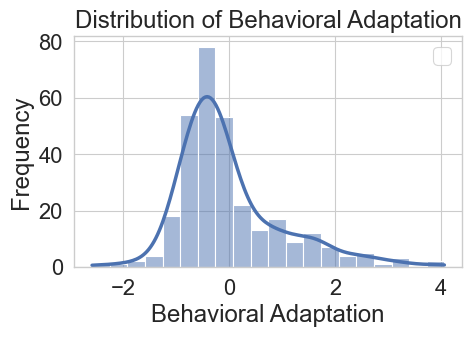

In [8]:
# histogram of Behavioral Adaptation
plt.figure(figsize=(5, 3))
sns.histplot(data=trial_level_df.groupby('subID')['behav_adaptation_SCORE_NORMED'].mean(), bins=20, kde=True) 
plt.title('Distribution of Behavioral Adaptation')
plt.xlabel('Behavioral Adaptation')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## Plotting

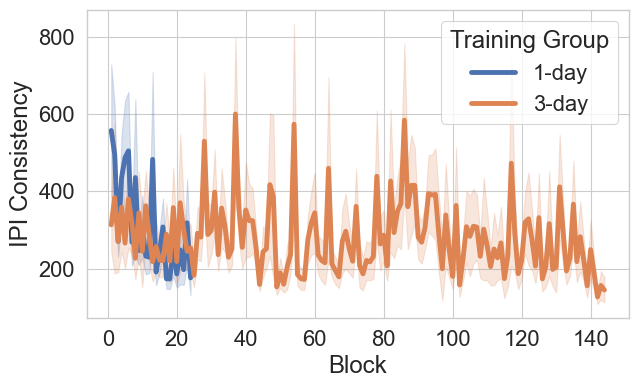

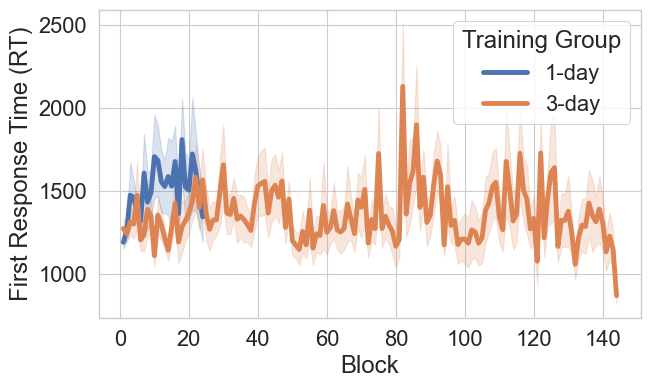

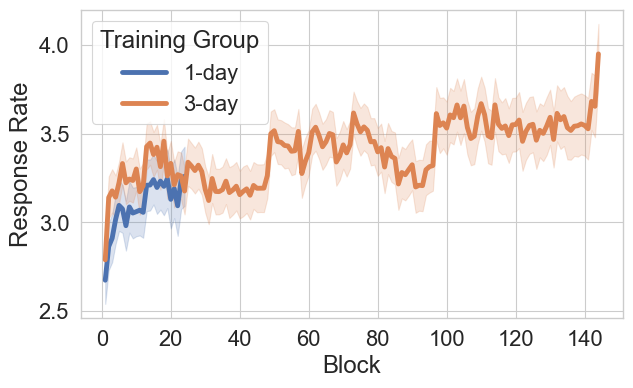

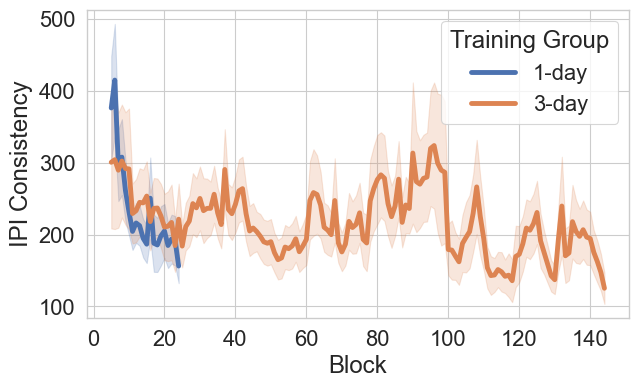

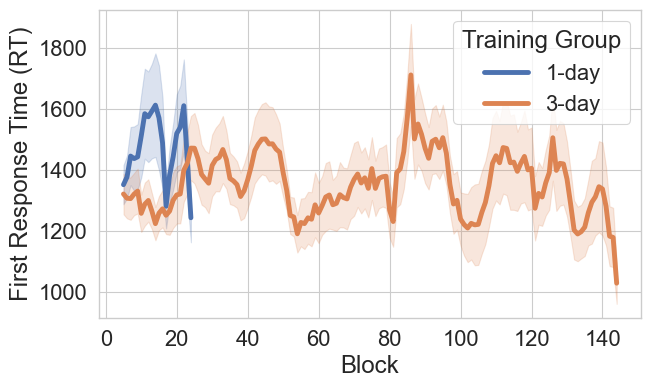

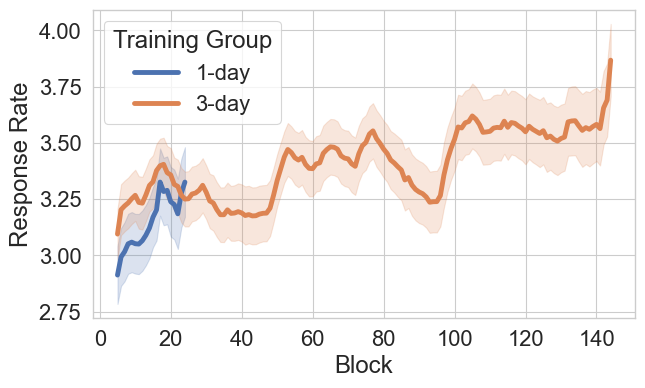

In [244]:
sns.set_context("paper", font_scale=1.8, rc={
    "lines.linewidth": 3.5,
    "lines.markersize": 8
})

# Plot the following variables:
variables_to_plot = ['IPI_abs_diff', 'first_RT', 'resp_rate']

# do x 1000 to have in ms
for var in ['IPI_abs_diff', 'first_RT']:
    trial_level_df[var] = trial_level_df[var] * 1000

y_axis_name_map = {
    'IPI_abs_diff': 'IPI Consistency',
    'first_RT': 'First Response Time (RT)',
    'resp_rate': 'Response Rate'
}
line_col = '#008B8B'

# plot var as a function of trial
for var in variables_to_plot:
    plt.figure(figsize=(7, 4))
    sns.lineplot(data=trial_level_df, x='trial', y=var, hue='group', errorbar='se', color=line_col)
    # sns.lineplot(data=trial_level_df, x='trial', y=var, hue='subID', markers=True, dashes=False)
    # plt.title(f'{var} as a function of trial')
    plt.xlabel('Block')
    # plt.xticks(ticks=sorted(trial_level_df['trial'].unique()))
    plt.ylabel(y_axis_name_map.get(var, var))
    plt.grid(True)
    # make legend title 'Trainig Group':
    plt.legend(title='Training Group')
    plt.show()

trial_level_df_smoothed = trial_level_df.copy()
# plot it smoothed
for var in variables_to_plot:
    plt.figure(figsize=(7, 4))
    # smooth with rolling mean
    trial_level_df_smoothed[f'{var}_smoothed'] = trial_level_df_smoothed.groupby('subID')[var].transform(lambda x: x.rolling(window=5).mean())
    sns.lineplot(data=trial_level_df_smoothed, x='trial', y=f'{var}_smoothed', hue='group', errorbar='se', color=line_col)
    plt.xlabel('Block')
    # plt.xticks(ticks=sorted(trial_level_df['trial'].unique()))
    plt.ylabel(y_axis_name_map.get(var, var))
    plt.grid(True)
    # remove legend title
    plt.legend(title='Training Group')
    plt.show()  


# ----- IPI Consistency (Automaticity) -----

## Analysis - modeling

In [9]:
IPI_consistency_data_by_trial = main_data_df.copy()
# change outcome col name to stim_condition and subID to sub)
IPI_consistency_data_by_trial.rename(columns={'outcome': 'stim_condition', 'subID': 'sub'}, inplace=True)
# IPI_consistency_data_by_trial.head()
IPI_consistency_data_by_trial['IPI_abs_diff'] = IPI_consistency_data_by_trial['IPI_abs_diff'] * 1000
IPI_consistency_data_by_trial.head()

,oldSubID,sub,group,site,day,block,run,first_RT,press_freq,trial,stim_condition,RT,IPI,IPI_abs_diff,behav_adaptation_SCORE,behav_adaptation_SCORE_NORMED
0,1,51,1-day,Caltech1,1,1,1,1.349336,4.590496,1,devalued,1.349255,NaN,NaN,0.473206,-0.088625
1,1,51,1-day,Caltech1,1,1,1,1.349336,4.590496,1,devalued,1.535908,0.186653,NaN,0.473206,-0.088625
2,1,51,1-day,Caltech1,1,1,1,1.349336,4.590496,1,devalued,1.709187,0.173279,13.373386,0.473206,-0.088625
3,1,51,1-day,Caltech1,1,1,1,1.349336,4.590496,1,devalued,1.855940,0.146753,26.526384,0.473206,-0.088625
4,1,51,1-day,Caltech1,1,1,1,1.349336,4.590496,1,devalued,2.002576,0.146635,0.117733,0.473206,-0.088625


70
140
210
280
350
The prefix already exists in the columns of the results_df
mean R^2: 0.042


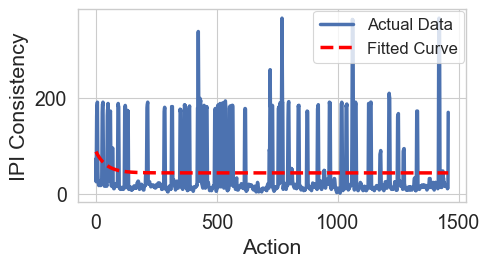

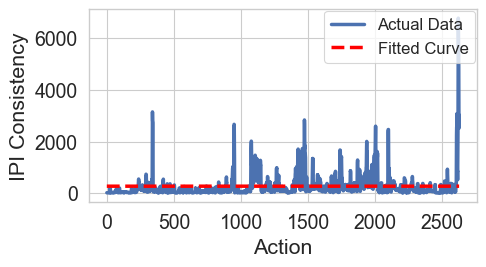

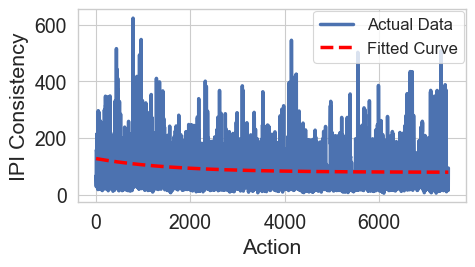

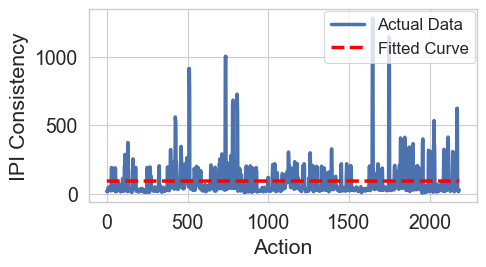

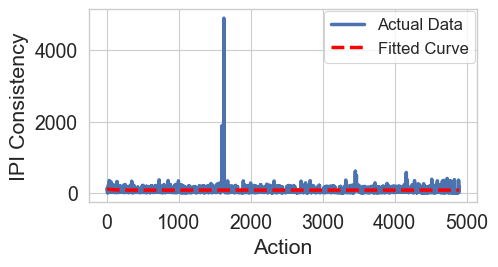

In [252]:
var = 'IPI_abs_diff'
var_of_comparison = 'stim_condition' # 'stim_condition'
to_smooth = True
smoothing_window = 5 # also 10 maybe best. maybe try also 20
min_period = None

sns.set_context("paper", font_scale=1.6, rc={
    "lines.linewidth": 2.5,
    "lines.markersize": 8
})

# fit the exponential decay to the data:
# -------------------------------------------
# prepare the data:
relevant_trial_data = IPI_consistency_data_by_trial.copy()
if var_of_comparison:
    grouping_factos = ['sub', 'stim_condition']
    stim_condition = var_of_comparison
else:
    grouping_factos = ['sub']
    stim_condition = 'all_stimuli'

relevant_trial_data.loc[:, 'stim_abs_trial'] = relevant_trial_data.groupby(grouping_factos).cumcount()

# remove nans:
relevant_trial_data = relevant_trial_data[relevant_trial_data[var].notna()]

# create a pd dataframe to store the results:
# results_df = pd.DataFrame(columns=['sub', 'group', 'stim_condition', 'asymp_to', 'improvement', 'alpha', 'end_of_training_pred', 'relative_improvement_accomplished', 'aic', 'bic', 'r_squared'])
results_df = pd.DataFrame()

# run the fitting procedure:
for sub in relevant_trial_data['sub'].unique():
    # prepare sub data:
    # ------------------------
    data = relevant_trial_data[relevant_trial_data['sub'] == sub]
    data = data.copy()
    data.loc[:, 'smoothed_data'] = data.groupby('stim_condition')[var].transform(lambda x: x.rolling(window=smoothing_window, min_periods=min_period).mean())
    # remove nans:
    data = data[data['smoothed_data'].notna()].reset_index(drop=True)
    # re-create the stim_abs_trial:
    data.loc[:, 'stim_abs_trial'] = data.groupby(grouping_factos).cumcount()
    
    # Average across conditions at each trial
    avg_data = data.groupby('stim_abs_trial')['smoothed_data'].mean().reset_index()

    x_data = avg_data['stim_abs_trial']
    y_data_smoothed = avg_data['smoothed_data']

    # fit the exponential decay:
    # --------------------------
    # Calculate better initial guesses from your data:
    y_start = y_data_smoothed.iloc[0]
    y_end = y_data_smoothed.iloc[-1]
    improvement_guess = abs(y_start - y_end)
    asymp_guess = y_end
    p0 = (asymp_guess, improvement_guess, 0.01)

    popt, pcov = curve_fit(exponential_decay, x_data, y_data_smoothed, p0=p0, maxfev=100000, bounds=([0, 0, 0], [35000, 35000, 10000]))
    y_predicted = exponential_decay(x_data, *popt)

    # Calculate the residuals, sum of squares of residuals and the total sum of squares
    residuals = y_data_smoothed - y_predicted
    ss_residuals = np.sum(residuals**2)
    ss_total = np.sum((y_data_smoothed - np.mean(y_data_smoothed))**2)
    # calculate the R squared:
    r_squared = 1 - (ss_residuals / ss_total)

    # Calculate the number of parameters (k)
    num_parameters = len(popt)

    # Calculate the number of data points (N)
    num_data_points = len(y_data_smoothed)

    # Calculate AIC and BIC
    aic = num_data_points * np.log(np.sum(residuals**2) / num_data_points) + 2 * num_parameters
    bic = num_data_points * np.log(np.sum(residuals**2) / num_data_points) + num_parameters * np.log(num_data_points)

    # relative gain of performance ('improvement') by the final point (according to the model):
    end_of_training_pred = exponential_decay(x_data.max(), *popt)
    relative_improvement_accomplished = 1 - ((end_of_training_pred - popt[0]) / popt[1])

    # now do the same but not with append:
    results_df = pd.concat([results_df, pd.DataFrame({'sub': sub, 'group': data['group'].iloc[0], 'stim_condition': stim_condition, 'asymp_to': popt[0], 'improvement': popt[1], 'alpha': popt[2], 'end_of_training_pred': end_of_training_pred, 'relative_improvement_accomplished': relative_improvement_accomplished, 'aic': aic, 'bic': bic, 'r_squared': r_squared}, index=[0])])
    
    # every 5 iterations print the results:
    if sub % 70 == 0:
    # if sub == 2 or sub == 271:
        # put x_data and y_data_smoothed along with stim_condition in a df:
        # --------------------------------------------------------------
        df = pd.DataFrame({'x_data': x_data, 'y_data_smoothed': y_data_smoothed, 'stim_condition': data['stim_condition']})


        # make a small plot fo the fit:
        fig, axes = plt.subplots(1, 1, figsize=(5, 2.5))
        # sns.lineplot(x=x_data, y=y_data_smoothed, hue='stim_condition', markers=True, ax=axes, errorbar=('se', 1), data=df)
        sns.lineplot(x=x_data, y=y_data_smoothed, markers=True, ax=axes, errorbar=('se', 1), data=df, label='Actual Data')
        # plot the fit:
        sns.lineplot(x=x_data, y=y_predicted, ax=axes, color='red', linestyle='--', label='Fitted Curve')
        axes.set_xlabel('Action')
        axes.set_ylabel('IPI Consistency')
        # axes.text(0.5, 0.9, f"subect: {sub}", horizontalalignment='center', verticalalignment='center', transform=axes.transAxes)

        # Add legend showing fitted and actual data:
        axes.legend(
            loc='upper right',
            fontsize=12,         # or use a number, e.g., fontsize=8
            # frameon=False,            # optional: removes box around legend
            bbox_to_anchor=(1, 1),    # pin it tightly to the top-right corner
            borderaxespad=0.1         # reduces padding between legend and axes
        )
        # axes.set_ylim(0, 350)
        print(sub)
    # if sub==1004:
        # break

results_df = results_df.reset_index(drop=True)
all_models_df_train = add_model_results_to_df(all_models_df_train, results_df, 'IPI_cons_train_')
print(f'mean R^2: {results_df.r_squared.mean().round(3)}')

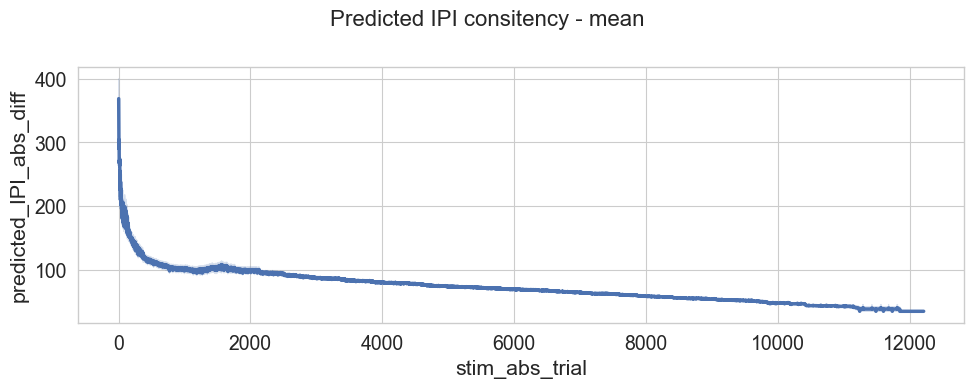

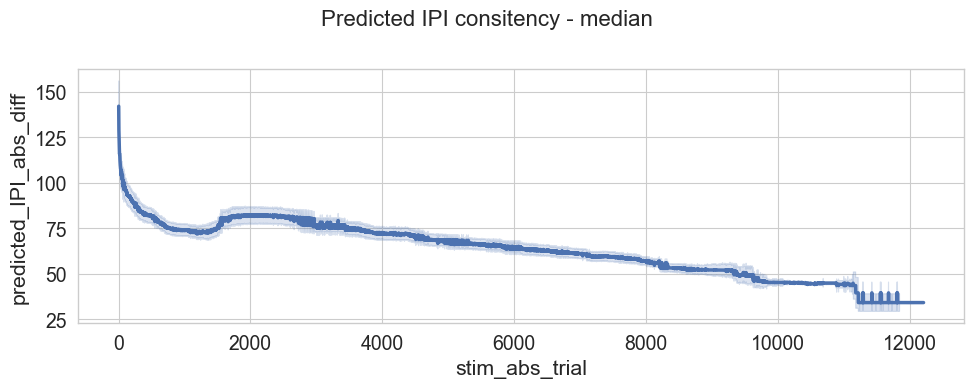

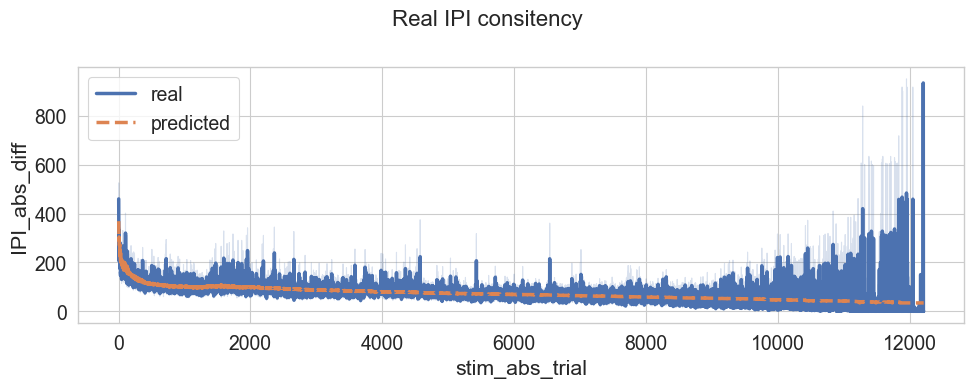

In [253]:
# predict for each participant the predicted sequence completion time at the end of the training:
# -------------------------------------------
predicted_data = IPI_consistency_data_by_trial.copy()
if var_of_comparison:
    predicted_data.loc[:, 'stim_abs_trial'] = predicted_data.groupby(['sub', 'stim_condition']).cumcount()
else:
    predicted_data.loc[:, 'stim_abs_trial'] = predicted_data.groupby(['sub']).cumcount()
predicted_data = predicted_data[predicted_data[var].notna()]

for group in predicted_data['group'].unique():
    # for each participant, predict the sequence completion for each trial:
    predicted_data.loc[:, 'predicted_IPI_abs_diff'] = np.nan
    for sub in predicted_data['sub'].unique():
        data = predicted_data[predicted_data['sub'] == sub]
        popt = results_df[results_df['sub'] == sub][['asymp_to', 'improvement', 'alpha']].iloc[0]
        predicted_data.loc[predicted_data['sub'] == sub, 'predicted_IPI_abs_diff'] = exponential_decay(predicted_data[predicted_data['sub'] == sub]['stim_abs_trial'], *popt)


# plot the predicted sequence completion time:
# -------------------------------------------
fig, axes = plt.subplots(1, 1, figsize=(10, 4))
# plot by  group:
# sns.lineplot(data=predicted_data, x='stim_abs_trial', y='predicted_IPI_abs_diff', hue='group', markers=True, ax=axes, errorbar=('se', 1))
sns.lineplot(data=predicted_data, x='stim_abs_trial', y='predicted_IPI_abs_diff', markers=True, ax=axes, errorbar=('se', 1))
# title to the figure:
title = 'Predicted IPI consitency - mean'
fig.suptitle(title, fontsize=16)
fig.tight_layout()
plt.show()

def calculate_error_bars(x):
    # Calculate the median
    median = np.median(x)
    
    # Calculate the IQR
    iqr = np.quantile(x, 0.75) - np.quantile(x, 0.25)
    
    # Calculate the number of observations
    n = len(x)
    
    # Calculate the lower and upper bounds of the notch
    lower = median - 1.57 * iqr / np.sqrt(n)
    upper = median + 1.57 * iqr / np.sqrt(n)
    
    return lower, upper


# now with the median and 95% CI:
# -------------------------------------------
fig, axes = plt.subplots(1, 1, figsize=(10, 4))
# plot by  group:
# plot the median and 95% CI:
# sns.lineplot(data=predicted_data, x='stim_abs_trial', y='predicted_IPI_abs_diff', hue='group', markers=True, ax=axes, estimator=np.median, errorbar=calculate_error_bars)
sns.lineplot(data=predicted_data, x='stim_abs_trial', y='predicted_IPI_abs_diff', markers=True, ax=axes, estimator=np.median, errorbar=calculate_error_bars)

# title to the figure:
title = 'Predicted IPI consitency - median'
fig.suptitle(title, fontsize=16)
fig.tight_layout()
plt.show()

# plot the real sequence completion time:
# -------------------------------------------
fig, axes = plt.subplots(1, 1, figsize=(10, 4))
# plot by  group:
# sns.lineplot(data=predicted_data, x='stim_abs_trial', y='IPI_abs_diff', hue='group', markers=True, ax=axes, errorbar=('se', 1))
# sns.lineplot(data=predicted_data, x='stim_abs_trial', y='predicted_IPI_abs_diff', hue='group', markers=True, ax=axes, errorbar=('se', 1), linestyle='--')
sns.lineplot(data=predicted_data, x='stim_abs_trial', y='IPI_abs_diff', markers=True, ax=axes, errorbar=('se', 1), label='real')
sns.lineplot(data=predicted_data, x='stim_abs_trial', y='predicted_IPI_abs_diff', markers=True, ax=axes, errorbar=('se', 1), linestyle='--', label='predicted')

# # in the legend make the dashed line have 'predicted' in the label:
# handles, labels = axes.get_legend_handles_labels()
# labels[1] = 'extensive training'
# labels[2] = 'extensive predicted'
# axes.legend(handles, labels)

# title to the figure:  
title = 'Real IPI consitency'
fig.suptitle(title, fontsize=16)
fig.tight_layout()
plt.show()



In [254]:
# add the data to the main data:
# -------------------------------------------
Dependent_vars_copy = IPI_df[['subID', 'behav_adaptation_SCORE_NORMED']].drop_duplicates()

# change subID to sub:
Dependent_vars_copy.rename(columns={'subID': 'sub'}, inplace=True)

main_data_df_w_fitting = pd.merge(Dependent_vars_copy, results_df.drop(columns=['stim_condition']), on=['sub'], how='left')
# main_data_df_w_fitting.head()
# merge with the dependent variables:
# main_data_df_w_fitting = main_data_df_w_fitting.merge(Dependent_vars, on='sub', how='left')

Pearson correlation for end_of_training_pred with devaluation ratio: -0.114, p-value: 0.0236
Spearman correlation for end_of_training_pred with devaluation ratio: -0.114, p-value: 0.0232
Pearson correlation for end_of_training_pred with devaluation ratio in 1-day: -0.119, p-value: 0.0735
Spearman correlation for end_of_training_pred with devaluation ratio in 1-day: -0.139, p-value: 0.0458
Pearson correlation for end_of_training_pred with devaluation ratio in 3-day: -0.112, p-value: 0.0811
Spearman correlation for end_of_training_pred with devaluation ratio in 3-day: -0.101, p-value: 0.1052


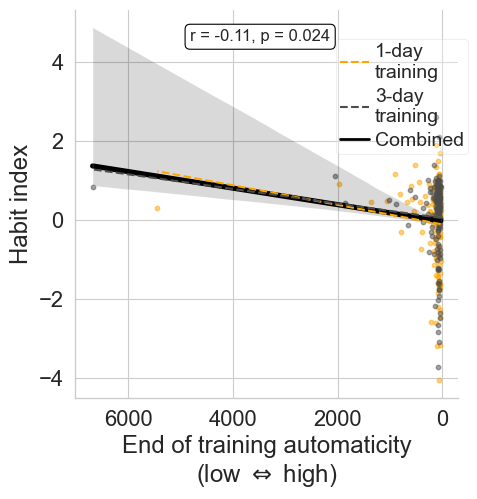

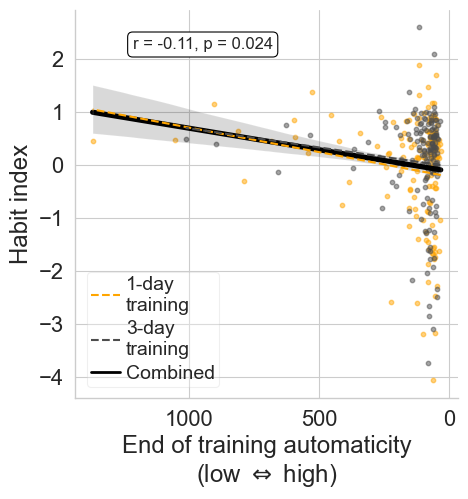

Removed 5 data points for vis purposes


In [255]:
import statsmodels.formula.api as smf
from scipy.stats import pearsonr
from matplotlib.lines import Line2D

sns.set_context("paper", font_scale=1.8, rc={
    "lines.linewidth": 2.5,
    "lines.markersize": 8
})

only_after_devalued_data = main_data_df_w_fitting.copy()
pallette = ['orange', (0.3, 0.3, 0.3)]

only_after_devalued_data['habit_level'] = -1 * only_after_devalued_data['behav_adaptation_SCORE_NORMED']

# Now do Pearson and Spearman correlation for the end of training predicted with devaluation ratio, and print coefficients and p-values
pearson_corr, pearson_p = pearsonr(only_after_devalued_data['end_of_training_pred'], only_after_devalued_data['behav_adaptation_SCORE_NORMED'], alternative='less')
print(f"Pearson correlation for end_of_training_pred with devaluation ratio: {pearson_corr:.3f}, p-value: {pearson_p:.4f}")
spearman_corr, spearman_p = spearmanr(only_after_devalued_data['end_of_training_pred'], only_after_devalued_data['behav_adaptation_SCORE_NORMED'], alternative='less')
print(f"Spearman correlation for end_of_training_pred with devaluation ratio: {spearman_corr:.3f}, p-value: {spearman_p:.4f}")

# Now each group separately:
for group in only_after_devalued_data['group'].unique():
    group_data = only_after_devalued_data[only_after_devalued_data['group'] == group]
    pearson_corr_group, pearson_p_group = pearsonr(group_data['end_of_training_pred'], group_data['behav_adaptation_SCORE_NORMED'], alternative='less')
    print(f"Pearson correlation for end_of_training_pred with devaluation ratio in {group}: {pearson_corr_group:.3f}, p-value: {pearson_p_group:.4f}")
    spearman_corr_group, spearman_p_group = spearmanr(group_data['end_of_training_pred'], group_data['behav_adaptation_SCORE_NORMED'], alternative='less')
    print(f"Spearman correlation for end_of_training_pred with devaluation ratio in {group}: {spearman_corr_group:.3f}, p-value: {spearman_p_group:.4f}")

# print(only_after_devalued_data.shape)
# sns.lmplot(data=only_after_devalued_data, x='end_of_training_pred', y='behav_adaptation_SCORE_NORMED', hue='group', hue_order=['1-day', '3-day'], palette=pallette, order=1, scatter_kws={'s': 10, 'alpha': 0.5}, height=5, aspect=1, legend=False) #, ci=68)

g = sns.lmplot(
    data=only_after_devalued_data,
    x='end_of_training_pred', y='habit_level',
    hue='group', hue_order=['1-day', '3-day'],
    palette=pallette,
    order=1,
    scatter_kws={'s': 10, 'alpha': 0.5},
    line_kws={'linestyle': '--', 'linewidth': 1.5},  # dashed + thinner line
    ci=None,                # no shaded confidence band
    height=5, aspect=1,
    legend=False
)

# add black line without scatter
sns.regplot(
    data=only_after_devalued_data,
    x='end_of_training_pred', y='habit_level',
    scatter=False, line_kws={'color': 'black', 'zorder': 1},
    order=1,
    ax=g.ax
)

# plt.ylabel('Behavioral Adaptation\nHabitual $\longleftrightarrow$ Goal-directed')
plt.ylabel('Habit index')
plt.xlabel('End of training automaticity\n(low $\Leftrightarrow$ high)')
# plt.xlim(right=310)
# Custom legend with lines
custom_lines = [
    Line2D([0], [0], color=pallette[0], linestyle='--', linewidth=1.5,
           label='1-day\ntraining'),
    Line2D([0], [0], color=pallette[1], linestyle='--', linewidth=1.5,
           label='3-day\ntraining'),
    Line2D([0], [0], color='black', linestyle='-', linewidth=2,
           label='Combined')
]

legend = plt.legend(
    handles=custom_lines,
    title=None,
    loc='upper right',
    bbox_to_anchor=(1.05, 0.95),  # Move slightly right and down
    fontsize=14,
    frameon=True,
    framealpha=0.3,
    labelspacing=0.3,
    handletextpad=0.3,
    borderpad=0.2,
    handlelength=1.5
)
plt.annotate(f"r = {pearson_corr:.2f}, p = {pearson_p:.3f}", xy=(0.3, 0.95), xycoords="axes fraction", fontsize=12, ha="left", va="top", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
plt.gca().invert_xaxis()  # for x-axis

plt.show()

# # NOTE: now without outliers for visualization porposes:
# # ---------------------------------------------------------
g = sns.lmplot(
    data=only_after_devalued_data[only_after_devalued_data.end_of_training_pred<1500],
    x='end_of_training_pred', y='habit_level',
    hue='group', hue_order=['1-day', '3-day'],
    palette=pallette,
    order=1,
    scatter_kws={'s': 10, 'alpha': 0.5},
    line_kws={'linestyle': '--', 'linewidth': 1.5},  # dashed + thinner line
    ci=None,                # no shaded confidence band
    height=5, aspect=1,
    legend=False
)

# add black line without scatter
sns.regplot(
    data=only_after_devalued_data[only_after_devalued_data.end_of_training_pred<1500],
    x='end_of_training_pred', y='habit_level',
    scatter=False, line_kws={'color': 'black', 'zorder': 1},
    order=1,
    ax=g.ax
)

# plt.ylabel('Behavioral Adaptation\nHabitual $\longleftrightarrow$ Goal-directed')
plt.ylabel('Habit index')
plt.xlabel('End of training automaticity\n(low $\Leftrightarrow$ high)')
# plt.xlim(right=310)
# Custom legend with lines
custom_lines = [
    Line2D([0], [0], color=pallette[0], linestyle='--', linewidth=1.5,
           label='1-day\ntraining'),
    Line2D([0], [0], color=pallette[1], linestyle='--', linewidth=1.5,
           label='3-day\ntraining'),
    Line2D([0], [0], color='black', linestyle='-', linewidth=2,
           label='Combined')
]

legend = plt.legend(
    handles=custom_lines,
    title=None,
    loc='upper right',
    bbox_to_anchor=(0.4, 0.35),  # Move slightly right and down
    fontsize=14,
    frameon=True,
    framealpha=0.3,
    labelspacing=0.3,
    handletextpad=0.3,
    borderpad=0.2,
    handlelength=1.5
)
plt.annotate(f"r = {pearson_corr:.2f}, p = {pearson_p:.3f}", xy=(0.15, 0.93), xycoords="axes fraction", fontsize=12, ha="left", va="top", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
plt.gca().invert_xaxis()  # for x-axis

plt.show()

print(f"Removed {only_after_devalued_data.shape[0] - only_after_devalued_data[only_after_devalued_data.end_of_training_pred<1500].shape[0]} data points for vis purposes")



Spearman correlation (raw): rho = 0.114, p = 0.0232
Spearman (raw) in 1-day: rho = 0.139, p = 0.0458
Spearman (raw) in 3-day: rho = 0.101, p = 0.1052


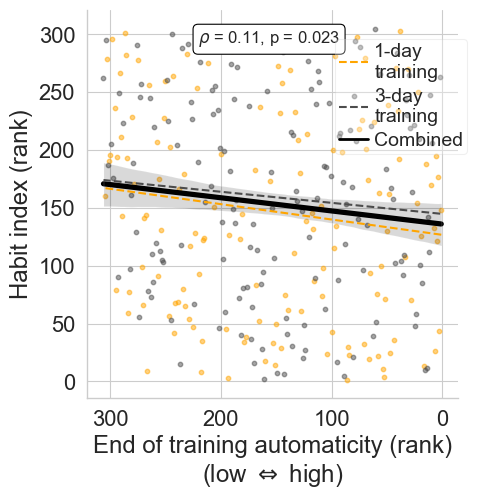

In [256]:
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

sns.set_context("paper", font_scale=1.8, rc={
    "lines.linewidth": 2.5,
    "lines.markersize": 8
})

only_after_devalued_data = main_data_df_w_fitting.copy()
pallette = ['orange', (0.3, 0.3, 0.3)]

# Habit index to keep your original visual direction (higher = more habitual)
only_after_devalued_data['habit_level'] = -1 * only_after_devalued_data['behav_adaptation_SCORE_NORMED']

# -------- Spearman stats on RAW values (correct) --------
spearman_corr, spearman_p = spearmanr(
    only_after_devalued_data['end_of_training_pred'],
    only_after_devalued_data['habit_level'],
    alternative='greater'
)
print(f"Spearman correlation (raw): rho = {spearman_corr:.3f}, p = {spearman_p:.4f}")

# Also per-group (raw)
for group in only_after_devalued_data['group'].unique():
    group_data = only_after_devalued_data[only_after_devalued_data['group'] == group]
    rho_g, p_g = spearmanr(
        group_data['end_of_training_pred'],
        group_data['habit_level'],
        alternative='greater'
    )
    print(f"Spearman (raw) in {group}: rho = {rho_g:.3f}, p = {p_g:.4f}")

# -------- Rank transform for plotting --------
df = only_after_devalued_data.copy()
df['x_rank'] = df['end_of_training_pred'].rank(method='average')
df['y_rank'] = df['habit_level'].rank(method='average')

# --- Plot 1: Full data, ranks on both axes ---
g = sns.lmplot(
    data=df,
    x='x_rank', y='y_rank',
    hue='group', hue_order=['1-day', '3-day'],
    palette=pallette,
    order=1,
    scatter_kws={'s': 10, 'alpha': 0.5},
    line_kws={'linestyle': '--', 'linewidth': 1.5},
    ci=None,
    height=5, aspect=1,
    legend=False
)

# Add combined black line (on ranks)
sns.regplot(
    data=df,
    x='x_rank', y='y_rank',
    scatter=False,
    line_kws={'color': 'black', 'zorder': 1},
    order=1,
    ax=g.ax
)

plt.ylabel('Habit index (rank)')
plt.xlabel('End of training automaticity (rank)\n(low $\\Leftrightarrow$ high)')
custom_lines = [
    Line2D([0], [0], color=pallette[0], linestyle='--', linewidth=1.5, label='1-day\ntraining'),
    Line2D([0], [0], color=pallette[1], linestyle='--', linewidth=1.5, label='3-day\ntraining'),
    Line2D([0], [0], color='black', linestyle='-', linewidth=2, label='Combined')
]
plt.legend(
    handles=custom_lines,
    title=None,
    loc='upper right',
    bbox_to_anchor=(1.05, 0.95),
    fontsize=14,
    frameon=True,
    framealpha=0.3,
    labelspacing=0.3,
    handletextpad=0.3,
    borderpad=0.2,
    handlelength=1.5
)

# Annotate Spearman from RAW values (standard practice)
plt.annotate(
    f"$\\rho$ = {spearman_corr:.2f}, p = {spearman_p:.3f}",
    xy=(0.3, 0.95), xycoords="axes fraction",
    fontsize=12, ha="left", va="top",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black")
)

# Keep the interpretive direction the same as before
plt.gca().invert_xaxis()
plt.show()



In [257]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr, kendalltau
import pingouin as pg   # pip install pingouin

x = only_after_devalued_data['end_of_training_pred']
y = only_after_devalued_data['habit_level']

results = {}

# --- Pearson ---
r, p = pearsonr(x, y, alternative='greater')
results['Pearson'] = (r, p)
dof = len(x) - 2
print(f"Degrees of freedom for Pearson correlation: {dof}")

# --- Spearman ---
r, p = spearmanr(x, y, alternative='greater')
results['Spearman'] = (r, p)

# --- Kendall’s tau ---
r, p = kendalltau(x, y, alternative='greater')
results['Kendall tau'] = (r, p)

# --- Robust: percentage bend correlation ---
pbcor = pg.corr(x, y, method='percbend', alternative='greater')
results['Percent-bend correlation'] = (
    pbcor['r'].values[0], pbcor['p-val'].values[0]
)

# --- Print nicely ---
print("Comparison of correlation methods:")
for method, (r, p) in results.items():
    print(f"{method:<25}: r = {r:.3f}, p = {p:.4g}")


Degrees of freedom for Pearson correlation: 304
Comparison of correlation methods:
Pearson                  : r = 0.114, p = 0.02361
Spearman                 : r = 0.114, p = 0.02321
Kendall tau              : r = 0.078, p = 0.02101
Percent-bend correlation : r = 0.130, p = 0.01145


In [91]:
# now it in R:
# -------------------------------------------
# # Define the DataFrame in the R global environment
robjects.globalenv['only_after_devalued_data'] = only_after_devalued_data

r_code = """
library(lme4)
library(lmerTest)
library(car)
only_after_devalued_data$group <- as.factor(only_after_devalued_data$group)
only_after_devalued_data$end_of_training_pred <- scale(only_after_devalued_data$end_of_training_pred)
# effect coding:
only_after_devalued_data$group <- ifelse(only_after_devalued_data$group == "1-day", -1, 1)
model <- lm(behav_adaptation_SCORE_NORMED ~ end_of_training_pred*group, data = only_after_devalued_data)
print(summary(model))
"""

# Execute user-defined R code
result = robjects.r(r_code)
print(result)



Call:
lm(formula = behav_adaptation_SCORE_NORMED ~ end_of_training_pred * 
    group, data = only_after_devalued_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.5354 -0.6030 -0.2583  0.3317  3.9596 

Coefficients:
                            Estimate Std. Error t value Pr(>|t|)  
(Intercept)                 0.002131   0.056564   0.038   0.9700  
end_of_training_pred       -0.116613   0.057469  -2.029   0.0433 *
group                      -0.072973   0.056564  -1.290   0.1980  
end_of_training_pred:group  0.016877   0.057469   0.294   0.7692  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.989 on 302 degrees of freedom
Multiple R-squared:  0.01857,	Adjusted R-squared:  0.008822 
F-statistic: 1.905 on 3 and 302 DF,  p-value: 0.1288

None


## --- TERTILES of habit expression

In [176]:
# checking perfect goal-directed behavior (0 habits)
Dependent_var_df_SCORE['post_deval'].min()
Dependent_var_df_SCORE['post_deval'].shape
# Dependent_var_df_SCORE[Dependent_var_df_SCORE['post_deval']==0].shape # 33 subjects
# 33/306
# Dependent_var_df_SCORE[(Dependent_var_df_SCORE['post_val']==0)].shape # 9 subjects
Dependent_var_df_SCORE[(Dependent_var_df_SCORE['post_deval']==0) & (Dependent_var_df_SCORE['post_val']>0)].shape # 25 subjects
25/306



0.08169934640522876

In [92]:
# Make sure rpy2 is loaded
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


## Tertiles calculated across all

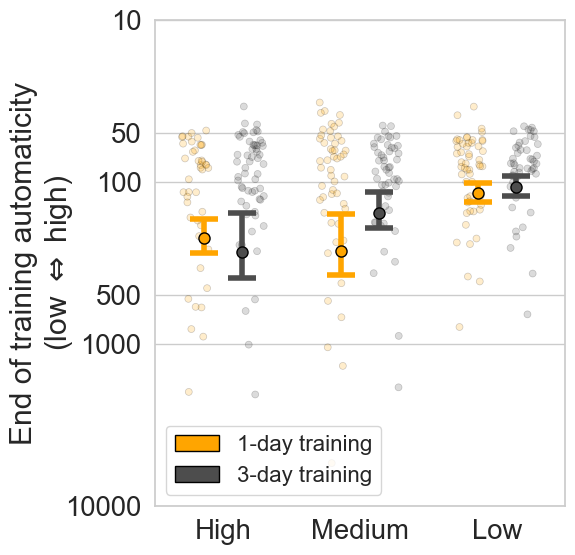

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import ticker
import matplotlib.patches as mpatches

# ---------- style ----------
sns.set(font_scale=1.8)
sns.set_style("whitegrid")

# assign a new variable of quartiles of
only_after_devalued_data['quartile'] = pd.qcut(only_after_devalued_data['behav_adaptation_SCORE_NORMED'], 4, labels=["Q1", "Q2", "Q3", "Q4"])
# and tertile:
only_after_devalued_data['tertile'] = pd.qcut(only_after_devalued_data['behav_adaptation_SCORE_NORMED'], 3, labels=["T1", "T2", "T3"])

# rename T1 as High, T2 as Medium, T3 as Low
only_after_devalued_data['tertile'] = (
    only_after_devalued_data['tertile']
    .cat.rename_categories({"T1": "High", "T2": "Medium", "T3": "Low"})
)

# ---------- ordering & palette ----------
habit_order = ["High", "Medium", "Low"]
hue_order   = ["1-day", "3-day"]

pallette = ['orange', (0.3, 0.3, 0.3)]
colors = {'1-day': pallette[0], '3-day': pallette[1]}
new_labels = ['1-day training', '3-day training']

# ---------- summary stats (means & SE) ----------
stats = (
    only_after_devalued_data
    .groupby(['tertile', 'group'], observed=True)['end_of_training_pred']
    .agg(mean='mean', se='sem')
    .reindex(pd.MultiIndex.from_product([habit_order, hue_order],
                                        names=['tertile','group']))
)

# pull arrays in the right order for plotting
means = {g: stats.xs(g, level='group')['mean'].values for g in hue_order}
ses   = {g: stats.xs(g, level='group')['se'  ].values for g in hue_order}

# ---------- plot ----------
fig, ax = plt.subplots(figsize=(6.2, 6))

x = np.arange(len(habit_order))      # [0, 1]
width = 0.28                         # dodge width
offsets = [-width/2, width/2]        # positions per hue

# errorbar points per hue, with colored markers and thick black caps
for i, g in enumerate(hue_order):
    ax.errorbar(
        x=x + offsets[i],
        y=means[g],
        yerr=ses[g],
        fmt='o',
        markersize=8,
        linewidth=4,                 # line (stem) thickness
        capsize=10,
        capthick=4,                  # cap thickness
        color=colors[g],             # marker + line color
        markerfacecolor=colors[g],
        markeredgecolor='black',
        zorder=3
    )

# x ticks/labels centered on categories
ax.set_xticks(x)
ax.set_xticklabels(habit_order)

# jittered individual points with hue/dodge (light, behind errorbars)
sns.stripplot(
    data=only_after_devalued_data,
    x="tertile",
    y="end_of_training_pred",
    hue="group",
    order=habit_order,
    hue_order=hue_order,
    palette=colors,
    dodge=True,
    jitter=0.2,
    alpha=0.2,
    edgecolor='black',
    linewidth=0.5,
    ax=ax,
    zorder=2
)

# log scale + pretty ticks, invert y like your example
plt.yscale('log')
ax.set_yticks([10, 50, 100, 500, 1000, 10000])
ax.get_yaxis().set_major_formatter(ticker.ScalarFormatter())
ax.set_ylabel('End of training automaticity\n(low $\\Leftrightarrow$ high)', labelpad=-7)
ax.set_xlabel("")
ax.invert_yaxis()
plt.ylim(top=10)

# legend with your new labels (based on hue)
# build simple color patches so it doesn't double-count stripplot handles
patches = [mpatches.Patch(facecolor=colors[g], edgecolor='black', label=lbl)
           for g, lbl in zip(hue_order, new_labels)]
leg = ax.legend(handles=patches, fontsize=16, frameon=True, loc='lower left')

plt.tight_layout()
plt.show()


In [94]:
only_after_devalued_data

,sub,behav_adaptation_SCORE_NORMED,group,asymp_to,improvement,alpha,end_of_training_pred,relative_improvement_accomplished,aic,bic,r_squared,habit_level,quartile,tertile
0,51,-0.088625,1-day,6.415400e+01,7.403775e+01,0.016442,64.154003,1.000000,13466.235861,13482.310442,1.838930e-02,0.088625,Q3,Medium
1,52,-0.231321,1-day,7.006046e+01,6.156494e+01,0.174176,70.060460,1.000000,10610.263381,10625.663269,2.153537e-03,0.231321,Q3,Medium
2,53,-0.230610,1-day,7.243576e-10,1.789409e+02,0.001387,91.697866,0.487552,4614.730170,4627.270220,4.469400e-02,0.230610,Q3,Medium
3,54,0.727006,1-day,7.320327e+01,5.875070e+01,174.547595,73.203268,1.000000,11483.377076,11498.864268,3.652763e-04,-0.727006,Q4,Low
4,55,-0.850308,1-day,5.965038e+02,9.644785e-08,474.175842,596.503822,1.000000,3782.514900,3793.705199,-1.201705e-12,0.850308,Q1,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,364,-0.983065,3-day,1.405865e+02,1.779500e+01,0.013827,140.586472,1.000000,51400.929542,51420.695850,1.473575e-04,0.983065,Q1,High
302,365,-0.787923,3-day,1.100236e+02,4.749039e+01,0.027636,110.023624,1.000000,45257.658235,45276.943976,2.116126e-04,0.787923,Q1,High
303,366,0.872294,3-day,1.548138e+02,2.392042e-02,510.776925,154.813797,1.000000,39043.489156,39062.112997,-1.246610e-08,-0.872294,Q4,Low
304,367,-0.557850,3-day,5.744700e+01,1.332748e+01,0.001400,57.447059,0.999995,73993.400455,74014.639783,1.319882e-03,0.557850,Q2,High



Call:
lm(formula = end_of_training_pred ~ tertile * group, data = only_after_devalued_data)

Residuals:
   Min     1Q Median     3Q    Max 
-238.8 -163.6  -68.3  -25.4 6412.5 

Coefficients:
                         Estimate Std. Error t value Pr(>|t|)
(Intercept)                117.30      72.78   1.612    0.108
tertileMedium              150.61     104.92   1.435    0.152
tertileHigh                105.34     109.87   0.959    0.338
group3-day                 -10.28     107.21  -0.096    0.924
tertileMedium:group3-day  -102.73     151.39  -0.679    0.498
tertileHigh:group3-day      60.69     152.34   0.398    0.691

Residual standard error: 539.7 on 300 degrees of freedom
Multiple R-squared:  0.01619,	Adjusted R-squared:  -0.0002055 
F-statistic: 0.9875 on 5 and 300 DF,  p-value: 0.4255

[1] "------------------------------------------------------------"
Non-constant Variance Score Test 
Variance formula: ~ fitted.values 
Chisquare = 155.2294, Df = 1, p = < 2.22e-16
[1] "------------

NOTE: Results may be misleading due to involvement in interactions
Coefficient covariances computed by hccm()
Coefficient covariances computed by hccm()


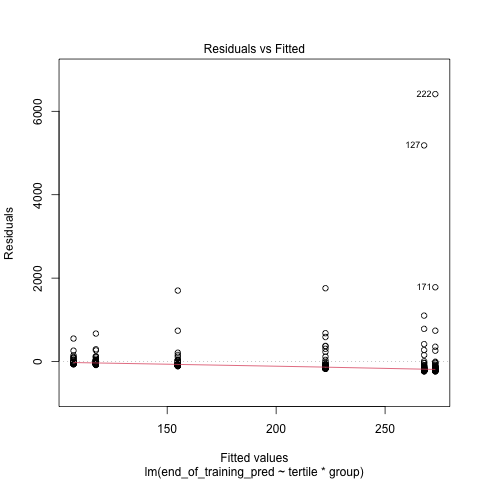

In [95]:
%%R -i only_after_devalued_data
library(car)
library(lmtest)     # coeftest()
library(sandwich)   # vcovHC()

# Ensure factor coding
only_after_devalued_data$tertile <- factor(only_after_devalued_data$tertile,levels = c("Low", "Medium", "High"))
only_after_devalued_data$tertile <- factor(only_after_devalued_data$tertile,levels = c("Low", "Medium", "High"), ordered = FALSE)
only_after_devalued_data$group <- factor(only_after_devalued_data$group,levels = c("1-day", "3-day"), ordered = FALSE)

model <- lm(end_of_training_pred ~ tertile*group, data = only_after_devalued_data)
print(summary(model))
print('------------------------------------------------------------')
print(ncvTest(model))   # Non-constant variance score test
print('------------------------------------------------------------')

print('>>>>> Corrected SEs <<<<<')
# White/HC3-robust tests for each coefficient (1-df)
Vsum   <- vcovHC(model, type = "HC3")
emm_t2 <- emmeans(model, ~ tertile, vcov. = Vsum, weights = "equal")
print(pairs(emm_t2, adjust = "none"))
print('>>>>>>>>>>>><<<<<<<<<<<')

only_after_devalued_data$tertile <- factor(only_after_devalued_data$tertile,levels = c("Medium", "Low", "High"), ordered = FALSE)
model <- lm(end_of_training_pred ~ tertile, data = only_after_devalued_data)
print(summary(model))

print('>>>>> Corrected SEs <<<<<')
# White/HC3-robust tests for each coefficient (1-df)
print(coeftest(model, vcov = vcovHC(model, type = "HC3")))
print('>>>>>>>>>>>><<<<<<<<<<<')


# # Effect coding:
# contrasts(only_after_devalued_data$tertile) <- contr.sum(3)
# # only_after_devalued_data$tertile <- factor(only_after_devalued_data$tertile,
# #   levels = c("Somewhat habitual", "Non-habitual", "Habitual")  # choose reference
# # )
# model <- lm(end_of_training_pred ~ tertile, data = only_after_devalued_data)
# print(summary(model))

# print(Anova(model, type = "III"))
# print(Anova(model, type = "III", white.adjust = TRUE))

# effect coding:
contrasts(only_after_devalued_data$tertile) <- contr.sum(3)
contrasts(only_after_devalued_data$group) <- contr.sum(2)
model <- lm(end_of_training_pred ~ tertile*group, data = only_after_devalued_data)
print(summary(model))

print(Anova(model, type = "III", white.adjust = FALSE))

print(ncvTest(model))   # Non-constant variance score test

print(Anova(model, type = "III", white.adjust = TRUE))

# # plot(model, which = 1)   # Residuals vs. Fitted

# # Hetroscedasticity

# # Robust SEs (HC3 is common)
# coeftest(model, vcov = vcovHC(model, type = "HC3"))
# bptest(model)
# bptest(model, ~ fitted(model) + I(fitted(model)^2))

plot(model, which = 1)
# library(ggplot2)
# aug <- data.frame(fitted = fitted(model), resid = resid(model))
# ggplot(aug, aes(fitted, resid)) +
#   geom_point(alpha=0.5) +
#   geom_smooth(method="loess", se=TRUE, color="blue") +
#   geom_hline(yintercept=0, linetype=2)



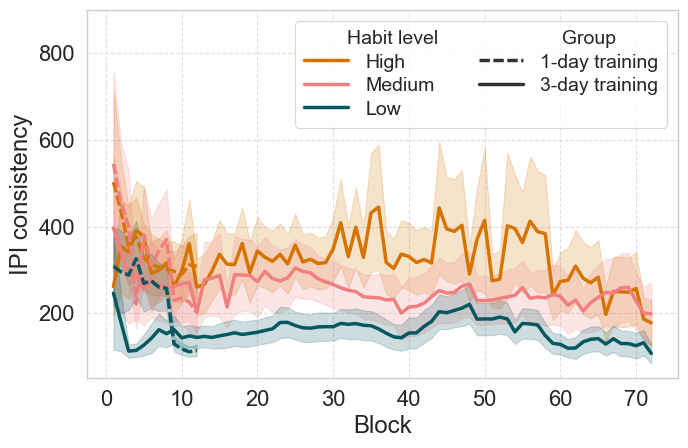

In [146]:
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.8, rc={
    "lines.linewidth": 2.5,
    "lines.markersize": 8
})
palette=["#D57500", "lightcoral", "#065760"]
palette_mapping = {
    'Low': palette[0],
    'Medium': palette[1],
    'High': palette[2]
}
fig_size_factor = 0.8
fig_size = (9*fig_size_factor, 6*fig_size_factor)

# --- Data prep ---
IPI_consistency_data_by_trial_isHabitual = IPI_consistency_data_by_trial.merge(
    only_after_devalued_data[['sub', 'tertile']],
    on='sub',
    how='left'
)

# Aggregate by block (ignore group now)
IPI_consistency_data_by_trial_isHabitual_byBlock = IPI_consistency_data_by_trial_isHabitual.groupby(['sub', 'group', 'trial', 'tertile', 'stim_condition'], observed=True).agg({'IPI_abs_diff': 'mean'}).reset_index()
IPI_consistency_data_by_trial_isHabitual_byBlock['stim_abs_trial'] = IPI_consistency_data_by_trial_isHabitual_byBlock.groupby(['sub', 'stim_condition'], observed=True).cumcount() + 1


measure_mean = IPI_consistency_data_by_trial_isHabitual_byBlock.IPI_abs_diff.mean()
measure_std = IPI_consistency_data_by_trial_isHabitual_byBlock.IPI_abs_diff.std()
# remove outlies with more than 5 SD from the mean:
IPI_consistency_data_by_trial_isHabitual_byBlock = IPI_consistency_data_by_trial_isHabitual_byBlock[
    (IPI_consistency_data_by_trial_isHabitual_byBlock['IPI_abs_diff'] < measure_mean + 10 * measure_std) &
    (IPI_consistency_data_by_trial_isHabitual_byBlock['IPI_abs_diff'] > measure_mean - 10 * measure_std)
].reset_index(drop=True)


# Create a new flat legend without a title
custom_labels = {
    'Low': 'Low',
    'Medium': 'Medium',
    'High': 'High',
    '1-day': '1-day training',
    '3-day': '3-day training',
}

# Now I want to repeat but after smoothing the IPI_abs_diff_sum by a rolling mean of 5 trials
IPI_consistency_data_by_trial_isHabitual_byBlock['smoothed_IPI_abs_diff'] = IPI_consistency_data_by_trial_isHabitual_byBlock.groupby(['sub', 'group', 'tertile', 'stim_condition'], observed=True)['IPI_abs_diff'].transform(lambda x: x.rolling(window=15, min_periods=1).mean())
IPI_consistency_data_by_trial_isHabitual_byBlock = IPI_consistency_data_by_trial_isHabitual_byBlock.groupby(['sub', 'group', 'tertile', 'stim_abs_trial'], observed=True).agg({'smoothed_IPI_abs_diff': 'mean'}).reset_index()

fig, axe = plt.subplots(1, 1, figsize=fig_size)
sns.lineplot(
    data=IPI_consistency_data_by_trial_isHabitual_byBlock,
    x='stim_abs_trial',
    y='smoothed_IPI_abs_diff',
    hue='tertile',
    style='group',
    palette=palette,  # Short and Extensive training colors
    legend='full',
    errorbar=('se', 1),
    dashes={'1-day': (3, 1), '3-day': (None, None)},  # <-- visible dash + solid
    ax=axe
)
axe.set_xlabel('Block')
axe.set_ylabel('IPI consistency')
# Remove Seaborn's automatic legend that includes titles
if axe.legend_:
    axe.legend_.remove()

# Get all handles and labels from the current plot
handles, labels = axe.get_legend_handles_labels()

# Match labels with custom ones, ignore empty or redundant ones
unique = []
used = set()
for h, l in zip(handles, labels):
    if l not in used and l in custom_labels:
        unique.append((h, custom_labels[l]))
        used.add(l)

# Unpack and add clean legend without a title
if unique:
    handles_clean, labels_clean = zip(*unique)
    legend = axe.legend(
        handles_clean,
        labels_clean,
        loc='upper right',
        ncol=2,            # two columns
        title='Habit level                       Group',  # one shared title
        labelspacing=0.2
    )
    for text in legend.texts:
        text.set_fontsize(14)
    legend.get_title().set_fontsize(14)
axe.grid(True, linestyle='--', alpha=0.6)
plt.ylim(top=900)      
# plt.xlim(0, 100)
plt.tight_layout()
plt.show()

In [229]:
IPI_consistency_data_by_trial_isHabitual
# get mean IPI_abs_diff per sub:
IPI_consistency_per_block = IPI_consistency_data_by_trial_isHabitual.groupby(['sub', 'group', 'trial', 'tertile'], observed=True)['IPI_abs_diff'].mean().reset_index()
IPI_consistency_per_block
IPI_consistency_per_block['tertile'].value_counts()

# Aggregate by block (ignore group now)
IPI_consistency_per_block = IPI_consistency_data_by_trial_isHabitual.groupby(['sub', 'group', 'trial', 'tertile', 'stim_condition'], observed=True).agg({'IPI_abs_diff': 'mean'}).reset_index()
IPI_consistency_per_block['stim_abs_trial'] = IPI_consistency_per_block.groupby(['sub', 'group', 'stim_condition'], observed=True).cumcount() + 1
IPI_consistency_per_block = IPI_consistency_per_block.groupby(['sub', 'group', 'tertile', 'stim_abs_trial'], observed=True).agg({'IPI_abs_diff': 'mean'}).reset_index()
IPI_consistency_per_block


,sub,group,tertile,stim_abs_trial,IPI_abs_diff
0,51,1-day,Medium,1,142.340617
1,51,1-day,Medium,2,62.336160
2,51,1-day,Medium,3,60.163283
3,51,1-day,Medium,4,82.786395
4,51,1-day,Medium,5,40.532107
...,...,...,...,...,...
12088,368,3-day,Low,63,76.907146
12089,368,3-day,Low,64,46.314497
12090,368,3-day,Low,65,24.374271
12091,368,3-day,Low,66,18.481612


In [230]:
IPI_consistency_per_block.tertile.unique()

['Medium', 'Low', 'High']
Categories (3, object): ['High' < 'Medium' < 'Low']

In [231]:
# remove ordering (turn into unordered categorical)
IPI_consistency_per_block["tertile"] = (
    IPI_consistency_per_block["tertile"].astype("category").cat.as_unordered()
)

# check again
print(IPI_consistency_per_block["tertile"].unique())
print(IPI_consistency_per_block["tertile"].cat.ordered)  # should be False


['Medium', 'Low', 'High']
Categories (3, object): ['High', 'Medium', 'Low']
False


[1] "========== MODEL SUMMARY =========="
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: IPI_abs_diff ~ stim_abs_trial * tertile + (1 | sub)
   Data: IPI_consistency_per_block

REML criterion at convergence: 200102.3

Scaled residuals: 
   Min     1Q Median     3Q    Max 
-9.075 -0.077 -0.023  0.005 33.752 

Random effects:
 Groups   Name        Variance Std.Dev.
 sub      (Intercept)  699353   836.3  
 Residual             1039383  1019.5  
Number of obs: 11937, groups:  sub, 306

Fixed effects:
                              Estimate Std. Error        df t value Pr(>|t|)   
(Intercept)                    261.132     86.855   300.701   3.007  0.00287 **
stim_abs_trial                   6.413     19.644 11928.964   0.326  0.74408   
tertileMedium                  153.752    122.453   297.295   1.256  0.21025   
tertileHigh                    215.495    122.146   294.450   1.764  0.07873 . 
stim_abs_trial:tertileMedium    12.275     26.773 

NOTE: Results may be misleading due to involvement in interactions
NOTE: Results may be misleading due to involvement in interactions
NOTE: Results may be misleading due to involvement in interactions
NOTE: Results may be misleading due to involvement in interactions
NOTE: Results may be misleading due to involvement in interactions


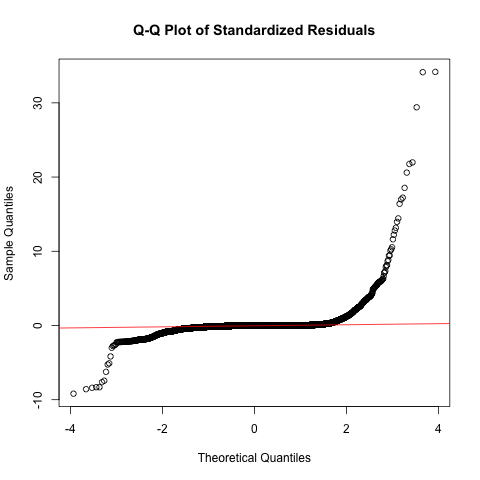

In [235]:
%%R -i IPI_consistency_per_block
library(car)
library(lme4)
library(lmerTest)
library(robustlmm)
library(clubSandwich)
library(emmeans)
library(lmtest)

# Prepare data
IPI_consistency_per_block$tertile <- factor(IPI_consistency_per_block$tertile, levels = c("Low","Medium","High"), ordered = FALSE)
IPI_consistency_per_block$group <- factor(IPI_consistency_per_block$group, levels = c("3-day","1-day"), ordered = FALSE)
IPI_consistency_per_block <- IPI_consistency_per_block[!is.na(IPI_consistency_per_block$IPI_abs_diff), ]
IPI_consistency_per_block$stim_abs_trial <- scale(IPI_consistency_per_block$stim_abs_trial)

print("========== MODEL SUMMARY ==========")
# Fit model with effect coding
model_reg <- lmer(IPI_abs_diff ~ stim_abs_trial*tertile + (1|sub), data = IPI_consistency_per_block)
print(summary(model_reg))

print("========== MODEL SUMMARY [effect coding] ==========")
# Set effect coding
contrasts(IPI_consistency_per_block$tertile) <- contr.sum(3)
contrasts(IPI_consistency_per_block$group) <- contr.sum(2)
# Fit model with effect coding
model_reg <- lmer(IPI_abs_diff ~ stim_abs_trial*tertile*group + (1|sub), data = IPI_consistency_per_block)
print(summary(model_reg))

print("========== TYPE III ANOVA (standard SEs) ==========")
print(Anova(model_reg, type = "III"))

# Heteroskedasticity checks
print('========== HETEROSKEDASTICITY TESTS ==========')

resid_data <- data.frame(sq_resid = residuals(model_reg)^2, fitted = fitted(model_reg))
bp_model <- lm(sq_resid ~ fitted, data = resid_data)
print("Breusch-Pagan test:")
print(summary(bp_model))

print('========== Outliers TEST ==========')
# Extract standardized residuals
std_resid <- residuals(model_reg) / sd(residuals(model_reg))

# Count extreme outliers (beyond ±3 SD)
n_outliers <- sum(abs(std_resid) > 3)
pct_outliers <- 100 * n_outliers / length(std_resid)

print(paste("Extreme outliers (>3 SD):", n_outliers, 
            "(", round(pct_outliers, 1), "%)"))

# Quick Q-Q plot
qqnorm(std_resid, main = "Q-Q Plot of Standardized Residuals")
qqline(std_resid, col = "red")

# Robustlmm analysis
print('========== ROBUST MODEL (rlmer) ==========')
model_robust <- rlmer(IPI_abs_diff ~ stim_abs_trial*tertile*group + (1|sub),
                      data = IPI_consistency_per_block)

print(">>>> Model summary:")
print(summary(model_robust))

print(">>>> Coefficient names:")
print(names(fixef(model_robust)))

print(">>>> Main effect of tertile:")
print(joint_tests(emmeans(model_robust, ~ tertile)))

print(">>>> Main effect of group:")
print(joint_tests(emmeans(model_robust, ~ group)))

print(">>>> Main effect of stim_abs_trial:")
print(test(emtrends(model_robust, ~ 1, var = "stim_abs_trial")))

print(">>>> Tertile x Trial interaction:")
print(joint_tests(emtrends(model_robust, ~ tertile, var = "stim_abs_trial")))

print(">>>> Group x Trial interaction:")
print(joint_tests(emtrends(model_robust, ~ group, var = "stim_abs_trial")))

print(">>>> Tertile x Group interaction:")
print(joint_tests(emmeans(model_robust, ~ tertile * group)))

print(">>>> 3-way interaction:")
print(joint_tests(emtrends(model_robust, ~ tertile * group, var = "stim_abs_trial")))


# ----- Response rate -----

## Analysis - regular stats (Run 2)

In [315]:
var = 'resp_rate'

run2_data = trial_level_df[((trial_level_df['group'] == '1-day') & (trial_level_df['run'] == 2)) | ((trial_level_df['group'] == '3-day') & (trial_level_df['day'] == 3) & (trial_level_df['run'] == 4))].copy().reset_index(drop=True)
run2_data = run2_data.groupby(['subID', 'group', 'behav_adaptation_SCORE_NORMED'])[var].mean().reset_index()
run2_data = run2_data[~run2_data[var].isna()].reset_index(drop=True)

# Check correlation:
# --------------------------------------------------------------
# Now do pearson and spearman correlation
pearson_corr, pearson_p = pearsonr(run2_data[var], run2_data['behav_adaptation_SCORE_NORMED'])
print(f"Pearson correlation for {var} with behavioral adaptation (last two trials avg): {pearson_corr:.3f}, p-value: {pearson_p:.3f}")
spearman_corr, spearman_p = spearmanr(run2_data[var], run2_data['behav_adaptation_SCORE_NORMED'])
print(f"Spearman correlation for {var} with behavioral adaptation (last two trials avg): {spearman_corr:.3f}, p-value: {spearman_p:.3f}")
# Check with the binary classification (Logistic regression):
# --------------------------------------------------------------
# Define the independent variables (X) and dependent variable (y)
X = run2_data[[var]]
y = run2_data['devaluation_ratio_binary']

# Add a constant to the model (intercept)
X = sm.add_constant(X)

# Fit the logistic regression model
model = sm.Logit(y, X).fit(disp=0)

# Print the summary of the model
print(f"\n\nLogistic Regression Results for {var}:")
print(model.summary())


Pearson correlation for resp_rate with behavioral adaptation (last two trials avg): 0.121, p-value: 0.034
Spearman correlation for resp_rate with behavioral adaptation (last two trials avg): 0.100, p-value: 0.081


KeyError: 'devaluation_ratio_binary'

(306, 4)


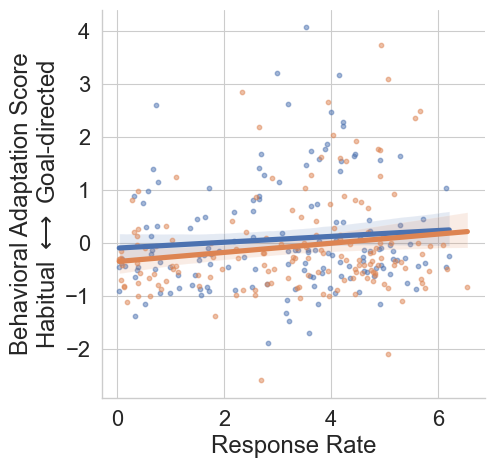

(306, 4)


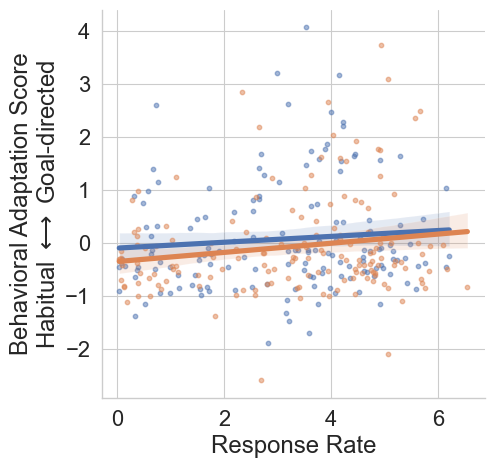

In [317]:
sns.set_theme(style="whitegrid")
sns.set_context("paper", font_scale=1.8, rc={
    "lines.linewidth": 2.5,
    "lines.markersize": 8
})

pallette = '#008B8B'

print(run2_data.shape)
sns.lmplot(data=run2_data, x=var, y='behav_adaptation_SCORE_NORMED', hue='group', order=1, scatter_kws={'s': 10, 'alpha': 0.5}, height=5, aspect=1, legend=False)  #, ci=68)
plt.ylabel('Behavioral Adaptation Score\nHabitual $\longleftrightarrow$ Goal-directed')
plt.xlabel('Response Rate')
# plt.xlim(right=310)
plt.show()

# NOTE: now without outliers for visualization porposes:
# ---------------------------------------------------------
print(run2_data.shape)
sns.lmplot(data=run2_data[run2_data[var]<3000], x=var, y='behav_adaptation_SCORE_NORMED', hue='group', order=1,scatter_kws={'s': 10, 'alpha': 0.5}, height=5, aspect=1, legend=False) #, ci=68)
plt.ylabel('Behavioral Adaptation Score\nHabitual $\longleftrightarrow$ Goal-directed')
plt.xlabel('Response Rate')
# plt.xlim(right=310)
plt.show()



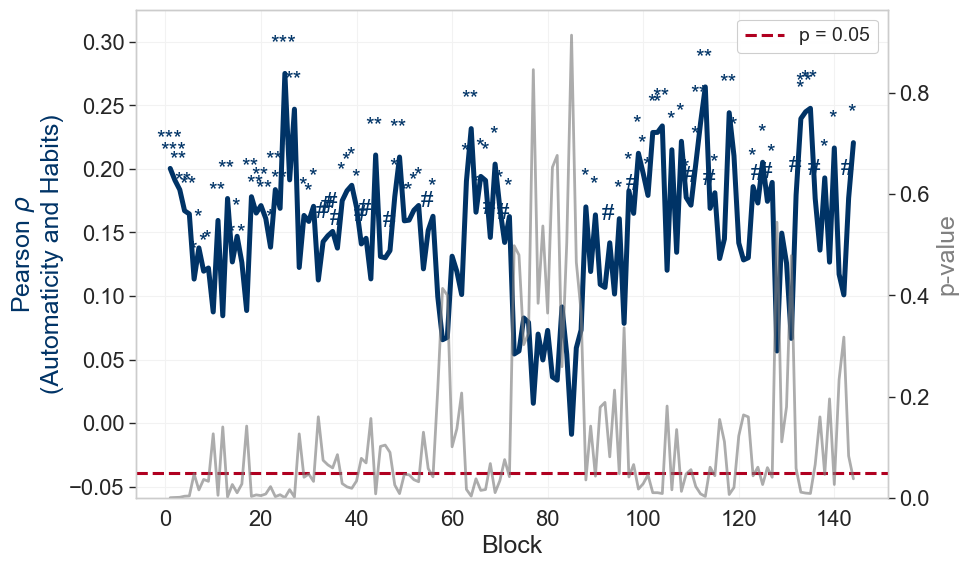

In [318]:
# sns.set_style("white")
# Line2D
from matplotlib.lines import Line2D

var = 'resp_rate'
trial_col = 'trial'
sub_col = 'subID'
min_n = 10  # minimum subjects per trial to compute correlation

# Merge trial-level with dependent vars (so behav_adaptation_SCORE_NORMED is available per subject)
df = trial_level_df.copy()

# Compute per-trial correlations across subjects
rows = []
for t, g in df.groupby(trial_col):
    g = g[[var, 'behav_adaptation_SCORE_NORMED']].dropna()
    n = len(g)
    if n >= min_n:
        r_p, p_p = pearsonr(g[var], g['behav_adaptation_SCORE_NORMED'])
        r_s, p_s = spearmanr(g[var], g['behav_adaptation_SCORE_NORMED'])
    else:
        r_p = p_p = r_s = p_s = np.nan
    rows.append({trial_col: t, 'n': n, 'R_pearson': r_p, 'p_pearson': p_p,
                 'R_spearman': r_s, 'p_spearman': p_s})

corr_df = pd.DataFrame(rows).sort_values(trial_col).reset_index(drop=True)
# display(corr_df.head())

# Optional: mark which trials pass p < .05 (uncorrected)
corr_df['sig_p'] = corr_df['p_pearson'] < 0.05

# --- plotting (paper-ready) ---
# Colors
r_color = '#003366'   # Pearson R
p_color = 'gray'   # p-value
ref_color = '#B00020'  # dashed p=0.05

# sns white:
# Figure
fig, ax1 = plt.subplots(figsize=(10, 6))

# Pearson R
ax1.plot(corr_df[trial_col], corr_df['R_pearson'],
         linewidth=3.6, color=r_color, label='Pearson R', zorder=3)
ax1.set_xlabel('Block', fontsize=18)
ax1.set_ylabel('Pearson $\u03C1$\n(Automaticity and Habits)', fontsize=18, color=r_color)
# ax1.tick_params(axis='y', colors='black', labelsize=16)  # ticks back to normal
# ax1.tick_params(axis='x', labelsize=16)
# ax1.axhline(0, linewidth=1.2, color='0.75', zorder=1)

# p-values
ax2 = ax1.twinx()
ax2.plot(corr_df[trial_col], corr_df['p_pearson'],
         linewidth=2.0, color=p_color, alpha=0.65, label='p-value (Pearson)', zorder=2)
ax2.axhline(0.05, linestyle='--', linewidth=2.2, color=ref_color, label='p = 0.05', zorder=1)
ax2.set_ylabel('p-value', fontsize=18, color=p_color)  # only label in color
# ax2.tick_params(axis='y', colors='black', labelsize=16)  # ticks back to normal

# White background, grid back to default
# fig.patch.set_facecolor('white')
# ax1.set_facecolor('white')
# ax2.set_facecolor('white')
ax1.grid(True, axis='y', color='0.95')  # light grid for readability
ax1.grid(True, axis='x', color='0.95')  # light grid for readability
ax2.grid(False, axis='y')  # light grid for readability

# Pad R-axis
r_vals = pd.to_numeric(corr_df['R_pearson'], errors='coerce').dropna().to_numpy()
if r_vals.size:
    r_lo = max(-1, np.min(r_vals) - 0.05)
    r_hi = min( 1, np.max(r_vals) + 0.05)
    ax1.set_ylim(r_lo, r_hi)

# Pad p-axis
p_vals = pd.to_numeric(corr_df['p_pearson'], errors='coerce').dropna().to_numpy()
if p_vals.size:
    p_hi = min(1, np.max(p_vals) + 0.05)
    if p_hi <= 0.05:
        p_hi = 0.08
    ax2.set_ylim(0, p_hi)

# Significance symbols
for t, r, pval in zip(corr_df[trial_col], corr_df['R_pearson'], corr_df['p_pearson']):
    if np.isfinite(r) and np.isfinite(pval):
        if pval < 0.001:
            sym = '***'
        elif pval < 0.01:
            sym = '**'
        elif pval < 0.05:
            sym = '*'
        elif pval < 0.1:
            sym = '#'
        else:
            sym = ''
        if sym:
            ax1.annotate(sym, (t, r), textcoords='offset points', xytext=(-1, 14),
                         ha='center', va='bottom', fontsize=16, color=r_color, zorder=4)

# Legend
handles = [
    # Line2D([0], [0], color=r_color, linewidth=3.6, label='Pearson R'),
    # Line2D([0], [0], color=p_color, linewidth=3.0, alpha=0.65, label='p-value (Pearson)'),
    Line2D([0], [0], color=ref_color, linewidth=2.2, linestyle='--', label='p = 0.05'),
]
ax1.legend(handles=handles, loc='best', frameon=True, framealpha=0.95,
           facecolor='white', edgecolor='0.8', fontsize=14)

fig.tight_layout()
plt.show()

## Analysis - modeling (Note this is on a block basis because it is calculated across blocks [defined as trials here])
* Another option is to us action by aciton bu do a rolling window or something)

* with smoothing more significance (I mean block smoothing) [I think]

In [258]:
IPI_consistency_data_by_trial = trial_level_df.copy()
# change outcome col name to stim_condition and subID to sub)
IPI_consistency_data_by_trial.rename(columns={'outcome': 'stim_condition', 'subID': 'sub'}, inplace=True)


Processing subject 51...
Processing subject 52...
Processing subject 53...
Processing subject 54...
Processing subject 55...
Processing subject 56...
Processing subject 57...
Processing subject 58...
Processing subject 59...
Processing subject 60...
Processing subject 61...
Processing subject 62...
Processing subject 63...
Processing subject 64...
Processing subject 65...
Processing subject 66...
Processing subject 67...
Processing subject 68...
Processing subject 69...
Processing subject 70...
Processing subject 71...
Processing subject 72...
Processing subject 73...
Processing subject 74...
Processing subject 75...
Processing subject 76...
Processing subject 77...
Processing subject 78...
Processing subject 79...
Processing subject 80...
Processing subject 81...
Processing subject 82...
Processing subject 83...
Processing subject 84...
Processing subject 85...
Processing subject 86...
Processing subject 87...
Processing subject 88...
Processing subject 89...
Processing subject 90...


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/optimize/_lsq/common.py:234: RuntimeWarning: overflow encountered in scalar divide
  ratio = actual_reduction / predicted_reduction


Processing subject 207...
Processing subject 208...
Processing subject 209...
Processing subject 210...
Processing subject 211...
Processing subject 212...
Processing subject 213...
Processing subject 214...
Processing subject 215...
Processing subject 216...
Processing subject 217...
Processing subject 218...
Processing subject 219...
Processing subject 220...
Processing subject 221...
Processing subject 222...
Processing subject 223...
Processing subject 224...
Processing subject 225...
Processing subject 226...
Processing subject 227...
Processing subject 228...
Processing subject 229...
Processing subject 230...
Processing subject 231...
Processing subject 232...
Processing subject 233...
Processing subject 235...
Processing subject 236...
Processing subject 237...
Processing subject 238...
Processing subject 239...
Processing subject 240...
Processing subject 241...
Processing subject 242...
Processing subject 243...
Processing subject 244...
Processing subject 245...
Processing s

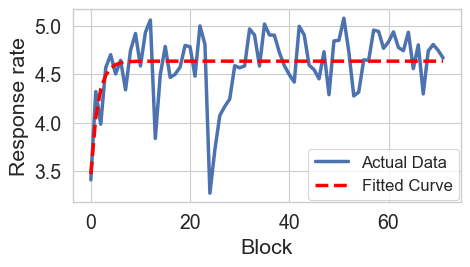

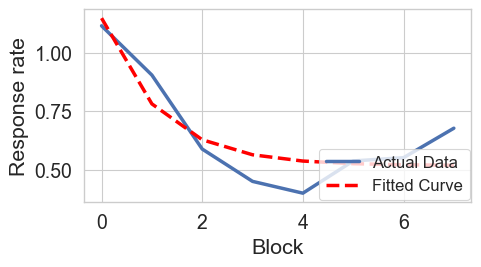

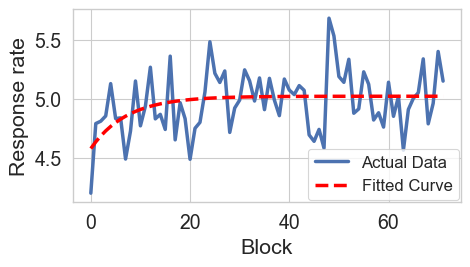

In [259]:
var = 'resp_rate'
var_of_comparison = 'stim_condition' # 'stim_condition'
to_smooth = True
smoothing_window = 1 # also 10 maybe best. maybe try also 20
min_period = None

sns.set_context("paper", font_scale=1.6, rc={
    "lines.linewidth": 2.5,
    "lines.markersize": 8
})

# fit the exponential decay to the data:
# -------------------------------------------
# prepare the data:
relevant_trial_data = IPI_consistency_data_by_trial.copy()
if var_of_comparison:
    grouping_factos = ['sub', 'stim_condition']
    stim_condition = var_of_comparison
else:
    grouping_factos = ['sub']
    stim_condition = 'all_stimuli'

relevant_trial_data.loc[:, 'stim_abs_trial'] = relevant_trial_data.groupby(grouping_factos).cumcount()

# remove nans:
relevant_trial_data = relevant_trial_data[relevant_trial_data[var].notna()]

# create a pd dataframe to store the results:
# results_df = pd.DataFrame(columns=['sub', 'group', 'stim_condition', 'asymp_to', 'improvement', 'alpha', 'end_of_training_pred', 'relative_improvement_accomplished', 'aic', 'bic', 'r_squared'])
results_df = pd.DataFrame()

# run the fitting procedure:
for sub in relevant_trial_data['sub'].unique():
    print(f'Processing subject {sub}...')
    # prepare sub data:
    # ------------------------
    data = relevant_trial_data[relevant_trial_data['sub'] == sub]
    data = data.copy()
    data.loc[:, 'smoothed_data'] = data.groupby('stim_condition')[var].transform(lambda x: x.rolling(window=smoothing_window, min_periods=min_period).mean())
    # remove nans:
    data = data[data['smoothed_data'].notna()].reset_index(drop=True)
    # re-create the stim_abs_trial:
    data.loc[:, 'stim_abs_trial'] = data.groupby(grouping_factos).cumcount()
    
    # Average across conditions at each trial
    avg_data = data.groupby('stim_abs_trial')['smoothed_data'].mean().reset_index()

    x_data = avg_data['stim_abs_trial']
    y_data_smoothed = avg_data['smoothed_data']

    # fit the exponential decay:
    # --------------------------
    # Calculate better initial guesses from your data:
    y_start = y_data_smoothed.iloc[0]
    y_end = y_data_smoothed.iloc[-1]
    improvement_guess = abs(y_start - y_end)
    asymp_guess = y_end
    p0 = (asymp_guess, improvement_guess, 0.01)

    popt, pcov = curve_fit(exponential_decay, x_data, y_data_smoothed, p0=p0, maxfev=100000, bounds=([0, -3500, -1000], [3500, 3500, 1000]))
    y_predicted = exponential_decay(x_data, *popt)

    # Calculate the residuals, sum of squares of residuals and the total sum of squares
    residuals = y_data_smoothed - y_predicted
    ss_residuals = np.sum(residuals**2)
    ss_total = np.sum((y_data_smoothed - np.mean(y_data_smoothed))**2)
    # calculate the R squared:
    r_squared = 1 - (ss_residuals / ss_total)

    # Calculate the number of parameters (k)
    num_parameters = len(popt)

    # Calculate the number of data points (N)
    num_data_points = len(y_data_smoothed)

    # Calculate AIC and BIC
    aic = num_data_points * np.log(np.sum(residuals**2) / num_data_points) + 2 * num_parameters
    bic = num_data_points * np.log(np.sum(residuals**2) / num_data_points) + num_parameters * np.log(num_data_points)

    # relative gain of performance ('improvement') by the final point (according to the model):
    end_of_training_pred = exponential_decay(x_data.max(), *popt)
    relative_improvement_accomplished = 1 - ((end_of_training_pred - popt[0]) / popt[1])

    # now do the same but not with append:
    results_df = pd.concat([results_df, pd.DataFrame({'sub': sub, 'group': data['group'].iloc[0], 'stim_condition': stim_condition, 'asymp_to': popt[0], 'improvement': popt[1], 'alpha': popt[2], 'end_of_training_pred': end_of_training_pred, 'relative_improvement_accomplished': relative_improvement_accomplished, 'aic': aic, 'bic': bic, 'r_squared': r_squared}, index=[0])])
    
    # every 5 iterations print the results:
    if sub % 90 == 0:
    # if sub == 2 or sub == 271:
        # put x_data and y_data_smoothed along with stim_condition in a df:
        # --------------------------------------------------------------
        df = pd.DataFrame({'x_data': x_data, 'y_data_smoothed': y_data_smoothed, 'stim_condition': data['stim_condition']})


        # make a small plot fo the fit:
        fig, axes = plt.subplots(1, 1, figsize=(5, 2.5))
        # sns.lineplot(x=x_data, y=y_data_smoothed, hue='stim_condition', markers=True, ax=axes, errorbar=('se', 1), data=df)
        sns.lineplot(x=x_data, y=y_data_smoothed, markers=True, ax=axes, errorbar=('se', 1), data=df, label='Actual Data')
        # plot the fit:
        sns.lineplot(x=x_data, y=y_predicted, ax=axes, color='red', linestyle='--', label='Fitted Curve')
        axes.set_xlabel('Block')
        axes.set_ylabel('Response rate')
        # axes.text(0.5, 0.9, f"subect: {sub}", horizontalalignment='center', verticalalignment='center', transform=axes.transAxes)

        # Add legend showing fitted and actual data:
        axes.legend(
            loc='lower right',
            fontsize=12,         # or use a number, e.g., fontsize=8
            # frameon=False,            # optional: removes box around legend
            # bbox_to_anchor=(1, 1),    # pin it tightly to the top-right corner
            borderaxespad=0.1         # reduces padding between legend and axes
        )
        # axes.set_ylim(0, 350)
        print(sub)
    # if sub==1004:
        # break

results_df = results_df.reset_index(drop=True)
all_models_df_train = add_model_results_to_df(all_models_df_train, results_df, 'IPI_cons_train_')
print(f'mean R^2: {results_df.r_squared.mean().round(3)}')

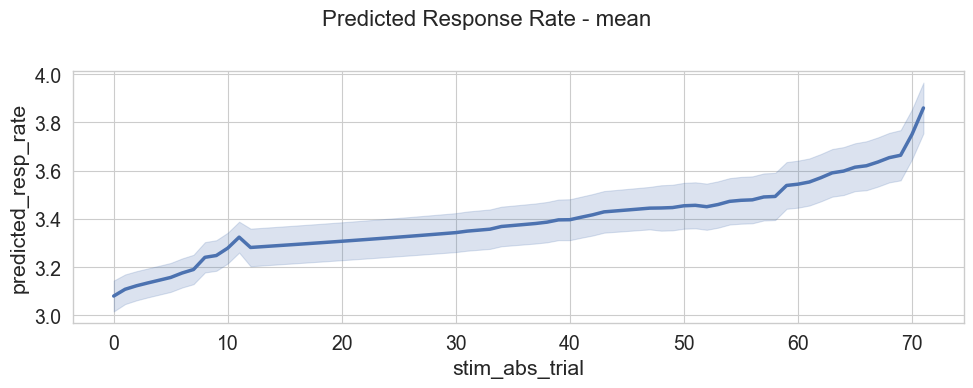

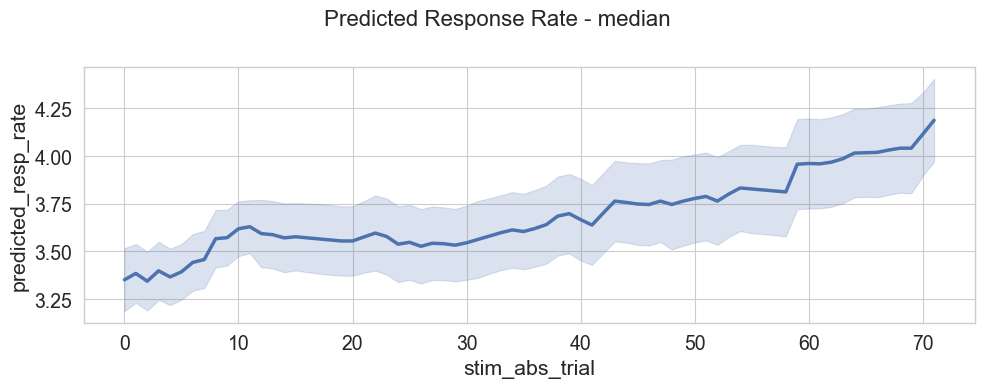

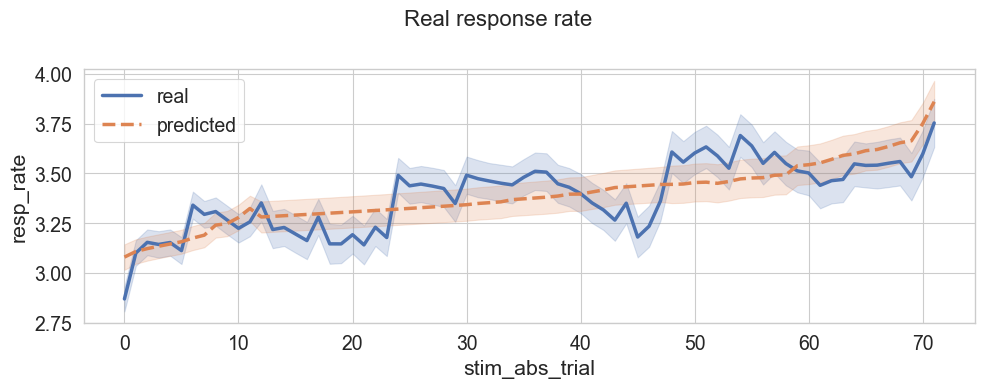

In [260]:
# predict for each participant the predicted sequence completion time at the end of the training:
# -------------------------------------------
predicted_data = IPI_consistency_data_by_trial.copy()
if var_of_comparison:
    predicted_data.loc[:, 'stim_abs_trial'] = predicted_data.groupby(['sub', 'stim_condition']).cumcount()
else:
    predicted_data.loc[:, 'stim_abs_trial'] = predicted_data.groupby(['sub']).cumcount()
predicted_data = predicted_data[predicted_data[var].notna()]

for group in predicted_data['group'].unique():
    # for each participant, predict the sequence completion for each trial:
    predicted_data.loc[:, 'predicted_resp_rate'] = np.nan
    for sub in predicted_data['sub'].unique():
        data = predicted_data[predicted_data['sub'] == sub]
        popt = results_df[results_df['sub'] == sub][['asymp_to', 'improvement', 'alpha']].iloc[0]
        predicted_data.loc[predicted_data['sub'] == sub, 'predicted_resp_rate'] = exponential_decay(predicted_data[predicted_data['sub'] == sub]['stim_abs_trial'], *popt)


# plot the predicted sequence completion time:
# -------------------------------------------
fig, axes = plt.subplots(1, 1, figsize=(10, 4))
# plot by  group:
# sns.lineplot(data=predicted_data, x='stim_abs_trial', y='predicted_IPI_abs_diff', hue='group', markers=True, ax=axes, errorbar=('se', 1))
sns.lineplot(data=predicted_data, x='stim_abs_trial', y='predicted_resp_rate', markers=True, ax=axes, errorbar=('se', 1))
# title to the figure:
title = 'Predicted Response Rate - mean'
fig.suptitle(title, fontsize=16)
fig.tight_layout()
plt.show()

def calculate_error_bars(x):
    # Calculate the median
    median = np.median(x)
    
    # Calculate the IQR
    iqr = np.quantile(x, 0.75) - np.quantile(x, 0.25)
    
    # Calculate the number of observations
    n = len(x)
    
    # Calculate the lower and upper bounds of the notch
    lower = median - 1.57 * iqr / np.sqrt(n)
    upper = median + 1.57 * iqr / np.sqrt(n)
    
    return lower, upper


# now with the median and 95% CI:
# -------------------------------------------
fig, axes = plt.subplots(1, 1, figsize=(10, 4))
# plot by  group:
# plot the median and 95% CI:
# sns.lineplot(data=predicted_data, x='stim_abs_trial', y='predicted_IPI_abs_diff', hue='group', markers=True, ax=axes, estimator=np.median, errorbar=calculate_error_bars)
sns.lineplot(data=predicted_data, x='stim_abs_trial', y='predicted_resp_rate', markers=True, ax=axes, estimator=np.median, errorbar=calculate_error_bars)

# title to the figure:
title = 'Predicted Response Rate - median'
fig.suptitle(title, fontsize=16)
fig.tight_layout()
plt.show()

# plot the real sequence completion time:
# -------------------------------------------
fig, axes = plt.subplots(1, 1, figsize=(10, 4))
# plot by  group:
# sns.lineplot(data=predicted_data, x='stim_abs_trial', y='IPI_abs_diff', hue='group', markers=True, ax=axes, errorbar=('se', 1))
# sns.lineplot(data=predicted_data, x='stim_abs_trial', y='predicted_resp_rate', hue='group', markers=True, ax=axes, errorbar=('se', 1), linestyle='--')
sns.lineplot(data=predicted_data, x='stim_abs_trial', y=var, markers=True, ax=axes, errorbar=('se', 1), label='real')
sns.lineplot(data=predicted_data, x='stim_abs_trial', y='predicted_resp_rate', markers=True, ax=axes, errorbar=('se', 1), linestyle='--', label='predicted')

# # in the legend make the dashed line have 'predicted' in the label:
# handles, labels = axes.get_legend_handles_labels()
# labels[1] = 'extensive training'
# labels[2] = 'extensive predicted'
# axes.legend(handles, labels)

# title to the figure:  
title = 'Real response rate'
fig.suptitle(title, fontsize=16)
fig.tight_layout()
plt.show()



In [261]:
# add the data to the main data:
# -------------------------------------------
Dependent_vars_copy = IPI_df[['subID', 'behav_adaptation_SCORE_NORMED']].drop_duplicates()

# change subID to sub:
Dependent_vars_copy.rename(columns={'subID': 'sub'}, inplace=True)

main_data_df_w_fitting = pd.merge(Dependent_vars_copy, results_df.drop(columns=['stim_condition']), on=['sub'], how='left')
# main_data_df_w_fitting.head()
# merge with the dependent variables:
# main_data_df_w_fitting = main_data_df_w_fitting.merge(Dependent_vars, on='sub', how='left')

(306, 12)


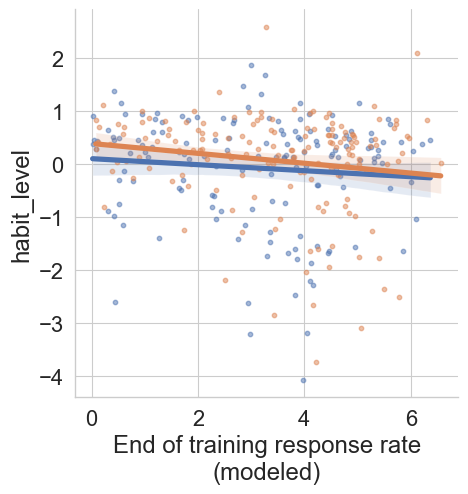

Pearson correlation for end_of_training_pred with devaluation ratio: -0.118, p-value: 0.0198
Spearman correlation for end_of_training_pred with devaluation ratio: -0.106, p-value: 0.0325


In [264]:
import statsmodels.formula.api as smf
from scipy.stats import pearsonr
from matplotlib.lines import Line2D

sns.set_context("paper", font_scale=1.8, rc={
    "lines.linewidth": 2.5,
    "lines.markersize": 8
})

only_after_devalued_data = main_data_df_w_fitting.copy()
pallette = ['#008B8B']
only_after_devalued_data['habit_level'] = -1 * only_after_devalued_data['behav_adaptation_SCORE_NORMED']

print(only_after_devalued_data.shape)
sns.lmplot(data=only_after_devalued_data, x='end_of_training_pred', y='habit_level', hue='group', order=1,scatter_kws={'s': 10, 'alpha': 0.5}, height=5, aspect=1, legend=False) #, ci=68)
plt.ylabel('habit_level')
plt.xlabel('End of training response rate\n(modeled)')
# plt.xlim(right=310)
plt.show()

# Now do Pearson and Spearman correlation for the end of training predicted with devaluation ratio, and print coefficients and p-values
pearson_corr, pearson_p = pearsonr(only_after_devalued_data['end_of_training_pred'], only_after_devalued_data['habit_level'], alternative='less')
print(f"Pearson correlation for end_of_training_pred with devaluation ratio: {pearson_corr:.3f}, p-value: {pearson_p:.4f}")
spearman_corr, spearman_p = spearmanr(only_after_devalued_data['end_of_training_pred'], only_after_devalued_data['habit_level'], alternative='less')
print(f"Spearman correlation for end_of_training_pred with devaluation ratio: {spearman_corr:.3f}, p-value: {spearman_p:.4f}")


In [225]:
# now it in R:
# -------------------------------------------
# # Define the DataFrame in the R global environment
robjects.globalenv['only_after_devalued_data'] = only_after_devalued_data

r_code = """
library(lme4)
library(lmerTest)
library(car)
only_after_devalued_data$group <- as.factor(only_after_devalued_data$group)
only_after_devalued_data$end_of_training_pred <- scale(only_after_devalued_data$end_of_training_pred)
# effect coding:
only_after_devalued_data$group <- ifelse(only_after_devalued_data$group == "1-day", -1, 1)
model <- lm(habit_level ~ end_of_training_pred*group, data = only_after_devalued_data)
print(summary(model))
print(Anova(model, type="III"))
"""

# Execute user-defined R code
result = robjects.r(r_code)
print(result)



Call:
lm(formula = habit_level ~ end_of_training_pred * group, data = only_after_devalued_data)



Residuals:
    Min      1Q  Median      3Q     Max 
-3.9460 -0.3711  0.2632  0.6242  2.5069 

Coefficients:
                             Estimate Std. Error t value Pr(>|t|)  
(Intercept)                 0.0006522  0.0567163   0.011   0.9908  
end_of_training_pred       -0.1251549  0.0567962  -2.204   0.0283 *
group                       0.0830416  0.0567163   1.464   0.1442  
end_of_training_pred:group -0.0302420  0.0567962  -0.532   0.5948  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.9874 on 302 degrees of freedom
Multiple R-squared:  0.02172,	Adjusted R-squared:  0.012 
F-statistic: 2.235 on 3 and 302 DF,  p-value: 0.08421

Anova Table (Type III tests)

Response: habit_level
                            Sum Sq  Df F value  Pr(>F)  
(Intercept)                  0.000   1  0.0001 0.99083  
end_of_training_pred         4.735   1  4.8558 0.02831 *
group                        2.090   1  2.1438 0.14419  
end_of_training_pred:group   0.27

# ----- First RT -----

## Analysis - regular stats (Run 2)

In [192]:
trial_level_df

,subID,group,trial,day,run,outcome,behav_adaptation_SCORE_NORMED,IPI,IPI_abs_diff,resp_rate,first_RT,trial_orig
0,51,1-day,1,1,1,devalued,-0.088625,0.203220,99.294962,4.590496,1349.336079,1
1,51,1-day,2,1,1,valued,-0.088625,0.324402,185.386273,2.845247,1438.051530,3
2,51,1-day,3,1,1,devalued,-0.088625,0.202321,71.170097,4.495652,1620.069189,5
3,51,1-day,4,1,1,valued,-0.088625,0.212959,53.502223,4.531132,1420.312418,7
4,51,1-day,5,1,1,valued,-0.088625,0.236198,57.263801,3.996159,1166.352499,9
...,...,...,...,...,...,...,...,...,...,...,...,...
23933,368,3-day,124,3,3,devalued,0.972763,0.180030,24.374271,5.034612,1924.503930,214
23934,368,3-day,125,3,3,valued,0.972763,0.203922,69.365589,4.789393,539.429518,216
23935,368,3-day,126,3,3,devalued,0.972763,0.180740,18.481612,5.397107,538.042501,218
23936,368,3-day,127,3,3,valued,0.972763,0.207328,66.318402,4.753247,673.229005,220


In [190]:
var = 'first_RT'

run2_data = trial_level_df[((trial_level_df['group'] == '1-day') & (trial_level_df['run'] == 2)) | ((trial_level_df['group'] == '3-day') & (trial_level_df['day'] == 3) & (trial_level_df['run'] == 4))].copy().reset_index(drop=True)
run2_data = run2_data.groupby(['subID', 'group', 'behav_adaptation_SCORE_NORMED'])[var].mean().reset_index()
run2_data = run2_data[~run2_data[var].isna()].reset_index(drop=True)

# Check correlation:
# --------------------------------------------------------------
# Now do pearson and spearman correlation
pearson_corr, pearson_p = pearsonr(run2_data[var], run2_data['behav_adaptation_SCORE_NORMED'])
print(f"Pearson correlation for {var} with behavioral adaptation (last two trials avg): {pearson_corr:.3f}, p-value: {pearson_p:.3f}")
spearman_corr, spearman_p = spearmanr(run2_data[var], run2_data['behav_adaptation_SCORE_NORMED'])
print(f"Spearman correlation for {var} with behavioral adaptation (last two trials avg): {spearman_corr:.3f}, p-value: {spearman_p:.3f}")
# Check with the binary classification (Logistic regression):
# --------------------------------------------------------------
# Define the independent variables (X) and dependent variable (y)
X = run2_data[[var]]
y = run2_data['devaluation_ratio_binary']

# Add a constant to the model (intercept)
X = sm.add_constant(X)

# Fit the logistic regression model
model = sm.Logit(y, X).fit(disp=0)

# Print the summary of the model
print(f"\n\nLogistic Regression Results for {var}:")
print(model.summary())


Pearson correlation for first_RT with behavioral adaptation (last two trials avg): -0.057, p-value: 0.318
Spearman correlation for first_RT with behavioral adaptation (last two trials avg): -0.013, p-value: 0.824


KeyError: 'devaluation_ratio_binary'

(306, 4)


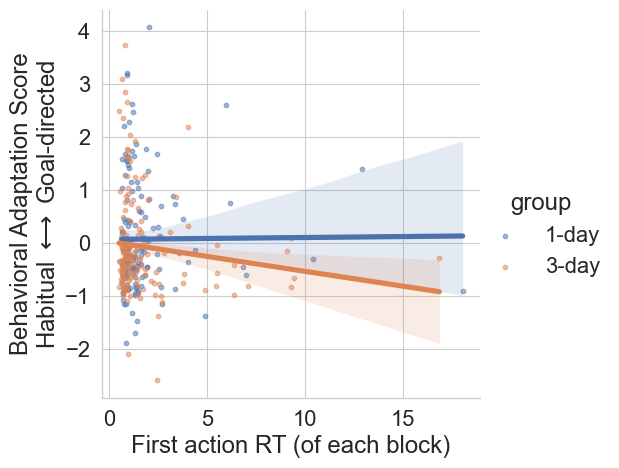

(306, 4)


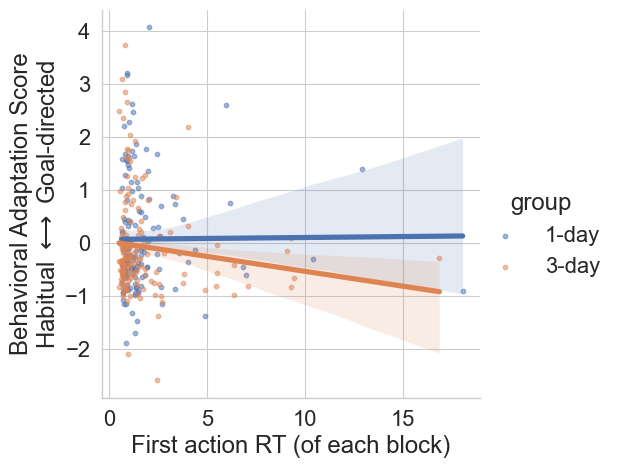

In [321]:
sns.set_theme(style="whitegrid")
sns.set_context("paper", font_scale=1.8, rc={
    "lines.linewidth": 2.5,
    "lines.markersize": 8
})

pallette = '#008B8B'

print(run2_data.shape)
sns.lmplot(data=run2_data, x=var, y='behav_adaptation_SCORE_NORMED', hue='group', order=1, scatter_kws={'s': 10, 'alpha': 0.5}, height=5, aspect=1)  #, ci=68)
plt.ylabel('Behavioral Adaptation Score\nHabitual $\longleftrightarrow$ Goal-directed')
plt.xlabel('First action RT (of each block)')
# plt.xlim(right=310)
plt.show()

# NOTE: now without outliers for visualization porposes:
# ---------------------------------------------------------
print(run2_data.shape)
sns.lmplot(data=run2_data[run2_data[var]<3000], x=var, y='behav_adaptation_SCORE_NORMED', hue='group', order=1,scatter_kws={'s': 10, 'alpha': 0.5}, height=5, aspect=1) #, ci=68)
plt.ylabel('Behavioral Adaptation Score\nHabitual $\longleftrightarrow$ Goal-directed')
plt.xlabel('First action RT (of each block)')
# plt.xlim(right=310)
plt.show()



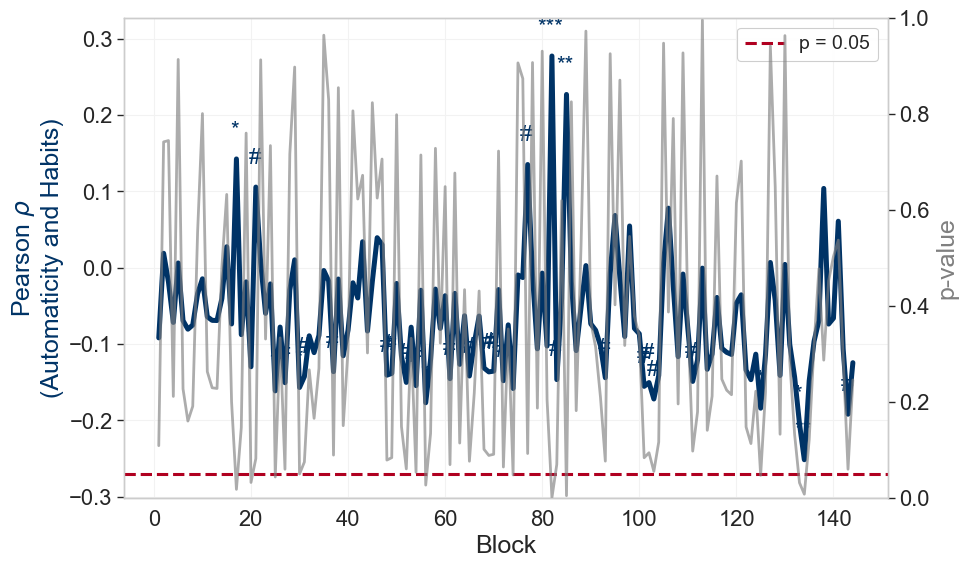

In [324]:
# sns.set_style("white")
# Line2D
from matplotlib.lines import Line2D

var = 'first_RT'
trial_col = 'trial'
sub_col = 'subID'
min_n = 10  # minimum subjects per trial to compute correlation

# Merge trial-level with dependent vars (so behav_adaptation_SCORE_NORMED is available per subject)
df = trial_level_df.copy()

# Compute per-trial correlations across subjects
rows = []
for t, g in df.groupby(trial_col):
    g = g[[var, 'behav_adaptation_SCORE_NORMED']].dropna()
    n = len(g)
    if n >= min_n:
        r_p, p_p = pearsonr(g[var], g['behav_adaptation_SCORE_NORMED'])
        r_s, p_s = spearmanr(g[var], g['behav_adaptation_SCORE_NORMED'])
    else:
        r_p = p_p = r_s = p_s = np.nan
    rows.append({trial_col: t, 'n': n, 'R_pearson': r_p, 'p_pearson': p_p,
                 'R_spearman': r_s, 'p_spearman': p_s})

corr_df = pd.DataFrame(rows).sort_values(trial_col).reset_index(drop=True)
# display(corr_df.head())

# Optional: mark which trials pass p < .05 (uncorrected)
corr_df['sig_p'] = corr_df['p_pearson'] < 0.05

# --- plotting (paper-ready) ---
# Colors
r_color = '#003366'   # Pearson R
p_color = 'gray'   # p-value
ref_color = '#B00020'  # dashed p=0.05

# sns white:
# Figure
fig, ax1 = plt.subplots(figsize=(10, 6))

# Pearson R
ax1.plot(corr_df[trial_col], corr_df['R_pearson'],
         linewidth=3.6, color=r_color, label='Pearson R', zorder=3)
ax1.set_xlabel('Block', fontsize=18)
ax1.set_ylabel('Pearson $\u03C1$\n(Automaticity and Habits)', fontsize=18, color=r_color)
# ax1.tick_params(axis='y', colors='black', labelsize=16)  # ticks back to normal
# ax1.tick_params(axis='x', labelsize=16)
# ax1.axhline(0, linewidth=1.2, color='0.75', zorder=1)

# p-values
ax2 = ax1.twinx()
ax2.plot(corr_df[trial_col], corr_df['p_pearson'],
         linewidth=2.0, color=p_color, alpha=0.65, label='p-value (Pearson)', zorder=2)
ax2.axhline(0.05, linestyle='--', linewidth=2.2, color=ref_color, label='p = 0.05', zorder=1)
ax2.set_ylabel('p-value', fontsize=18, color=p_color)  # only label in color
# ax2.tick_params(axis='y', colors='black', labelsize=16)  # ticks back to normal

# White background, grid back to default
# fig.patch.set_facecolor('white')
# ax1.set_facecolor('white')
# ax2.set_facecolor('white')
ax1.grid(True, axis='y', color='0.95')  # light grid for readability
ax1.grid(True, axis='x', color='0.95')  # light grid for readability
ax2.grid(False, axis='y')  # light grid for readability

# Pad R-axis
r_vals = pd.to_numeric(corr_df['R_pearson'], errors='coerce').dropna().to_numpy()
if r_vals.size:
    r_lo = max(-1, np.min(r_vals) - 0.05)
    r_hi = min( 1, np.max(r_vals) + 0.05)
    ax1.set_ylim(r_lo, r_hi)

# Pad p-axis
p_vals = pd.to_numeric(corr_df['p_pearson'], errors='coerce').dropna().to_numpy()
if p_vals.size:
    p_hi = min(1, np.max(p_vals) + 0.05)
    if p_hi <= 0.05:
        p_hi = 0.08
    ax2.set_ylim(0, p_hi)

# Significance symbols
for t, r, pval in zip(corr_df[trial_col], corr_df['R_pearson'], corr_df['p_pearson']):
    if np.isfinite(r) and np.isfinite(pval):
        if pval < 0.001:
            sym = '***'
        elif pval < 0.01:
            sym = '**'
        elif pval < 0.05:
            sym = '*'
        elif pval < 0.1:
            sym = '#'
        else:
            sym = ''
        if sym:
            ax1.annotate(sym, (t, r), textcoords='offset points', xytext=(-1, 14),
                         ha='center', va='bottom', fontsize=16, color=r_color, zorder=4)

# Legend
handles = [
    # Line2D([0], [0], color=r_color, linewidth=3.6, label='Pearson R'),
    # Line2D([0], [0], color=p_color, linewidth=3.0, alpha=0.65, label='p-value (Pearson)'),
    Line2D([0], [0], color=ref_color, linewidth=2.2, linestyle='--', label='p = 0.05'),
]
ax1.legend(handles=handles, loc='best', frameon=True, framealpha=0.95,
           facecolor='white', edgecolor='0.8', fontsize=14)

fig.tight_layout()
plt.show()

## Analysis - modeling (Note this is on a block basis because it is calculated across blocks [defined as trials here])
* Another option is to us action by aciton bu do a rolling window or something)

In [265]:
IPI_consistency_data_by_trial.head()

,sub,group,trial,day,run,stim_condition,behav_adaptation_SCORE_NORMED,IPI,IPI_abs_diff,resp_rate,first_RT,trial_orig
0,51,1-day,1,1,1,devalued,-0.088625,0.203220,99.294962,4.590496,1349.336079,1
1,51,1-day,2,1,1,valued,-0.088625,0.324402,185.386273,2.845247,1438.051530,3
2,51,1-day,3,1,1,devalued,-0.088625,0.202321,71.170097,4.495652,1620.069189,5
3,51,1-day,4,1,1,valued,-0.088625,0.212959,53.502223,4.531132,1420.312418,7
4,51,1-day,5,1,1,valued,-0.088625,0.236198,57.263801,3.996159,1166.352499,9


In [266]:
IPI_consistency_data_by_trial = trial_level_df.copy()
# change outcome col name to stim_condition and subID to sub)
IPI_consistency_data_by_trial.rename(columns={'outcome': 'stim_condition', 'subID': 'sub'}, inplace=True)
# make * 1000:
# IPI_consistency_data_by_trial['first_RT'] *= 1000

77
154
231
308
The prefix already exists in the columns of the results_df
mean R^2: 0.125


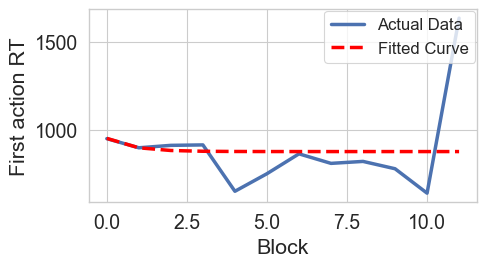

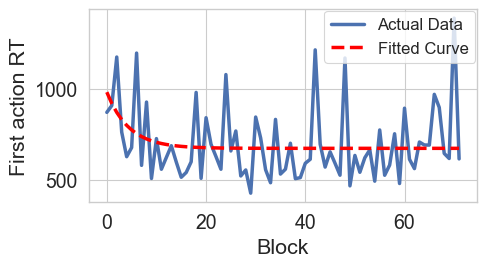

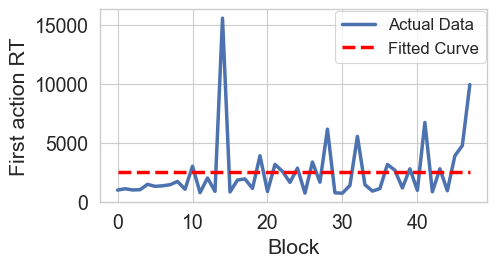

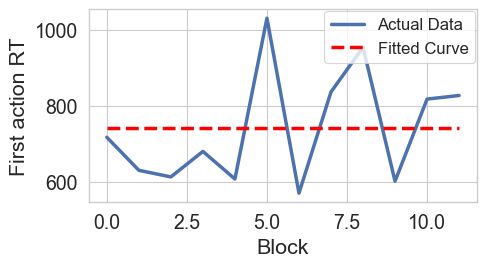

In [267]:
var = 'first_RT'
var_of_comparison = 'stim_condition' # 'stim_condition'
to_smooth = True
smoothing_window = 1 # also 10 maybe best. maybe try also 20
min_period = None

sns.set_context("paper", font_scale=1.6, rc={
    "lines.linewidth": 2.5,
    "lines.markersize": 8
})

# fit the exponential decay to the data:
# -------------------------------------------
# prepare the data:
relevant_trial_data = IPI_consistency_data_by_trial.copy()
if var_of_comparison:
    grouping_factos = ['sub', 'stim_condition']
    stim_condition = var_of_comparison
else:
    grouping_factos = ['sub']
    stim_condition = 'all_stimuli'

relevant_trial_data.loc[:, 'stim_abs_trial'] = relevant_trial_data.groupby(grouping_factos).cumcount()

# remove nans:
relevant_trial_data = relevant_trial_data[relevant_trial_data[var].notna()]

# create a pd dataframe to store the results:
# results_df = pd.DataFrame(columns=['sub', 'group', 'stim_condition', 'asymp_to', 'improvement', 'alpha', 'end_of_training_pred', 'relative_improvement_accomplished', 'aic', 'bic', 'r_squared'])
results_df = pd.DataFrame()

# run the fitting procedure:
for sub in relevant_trial_data['sub'].unique():
    # prepare sub data:
    # ------------------------
    data = relevant_trial_data[relevant_trial_data['sub'] == sub]
    data = data.copy()
    data.loc[:, 'smoothed_data'] = data.groupby('stim_condition')[var].transform(lambda x: x.rolling(window=smoothing_window, min_periods=min_period).mean())
    # remove nans:
    data = data[data['smoothed_data'].notna()].reset_index(drop=True)
    # re-create the stim_abs_trial:
    data.loc[:, 'stim_abs_trial'] = data.groupby(grouping_factos).cumcount()
    
    # Average across conditions at each trial
    avg_data = data.groupby('stim_abs_trial')['smoothed_data'].mean().reset_index()

    x_data = avg_data['stim_abs_trial']
    y_data_smoothed = avg_data['smoothed_data']

    # fit the exponential decay:
    # --------------------------
    # Calculate better initial guesses from your data:
    y_start = y_data_smoothed.iloc[0]
    y_end = y_data_smoothed.iloc[-1]
    improvement_guess = abs(y_start - y_end)
    asymp_guess = y_end
    p0 = (asymp_guess, improvement_guess, 0.01)

    popt, pcov = curve_fit(exponential_decay, x_data, y_data_smoothed, p0=p0, maxfev=100000, bounds=([0, 0, 0], [35000, 35000, 10000]))
    y_predicted = exponential_decay(x_data, *popt)

    # Calculate the residuals, sum of squares of residuals and the total sum of squares
    residuals = y_data_smoothed - y_predicted
    ss_residuals = np.sum(residuals**2)
    ss_total = np.sum((y_data_smoothed - np.mean(y_data_smoothed))**2)
    # calculate the R squared:
    r_squared = 1 - (ss_residuals / ss_total)

    # Calculate the number of parameters (k)
    num_parameters = len(popt)

    # Calculate the number of data points (N)
    num_data_points = len(y_data_smoothed)

    # Calculate AIC and BIC
    aic = num_data_points * np.log(np.sum(residuals**2) / num_data_points) + 2 * num_parameters
    bic = num_data_points * np.log(np.sum(residuals**2) / num_data_points) + num_parameters * np.log(num_data_points)

    # relative gain of performance ('improvement') by the final point (according to the model):
    end_of_training_pred = exponential_decay(x_data.max(), *popt)
    relative_improvement_accomplished = 1 - ((end_of_training_pred - popt[0]) / popt[1])

    # now do the same but not with append:
    results_df = pd.concat([results_df, pd.DataFrame({'sub': sub, 'group': data['group'].iloc[0], 'stim_condition': stim_condition, 'asymp_to': popt[0], 'improvement': popt[1], 'alpha': popt[2], 'end_of_training_pred': end_of_training_pred, 'relative_improvement_accomplished': relative_improvement_accomplished, 'aic': aic, 'bic': bic, 'r_squared': r_squared}, index=[0])])
    
    # every 5 iterations print the results:
    if sub % 77 == 0:
    # if sub == 2 or sub == 271:
        # put x_data and y_data_smoothed along with stim_condition in a df:
        # --------------------------------------------------------------
        df = pd.DataFrame({'x_data': x_data, 'y_data_smoothed': y_data_smoothed, 'stim_condition': data['stim_condition']})


        # make a small plot fo the fit:
        fig, axes = plt.subplots(1, 1, figsize=(5, 2.5))
        # sns.lineplot(x=x_data, y=y_data_smoothed, hue='stim_condition', markers=True, ax=axes, errorbar=('se', 1), data=df)
        sns.lineplot(x=x_data, y=y_data_smoothed, markers=True, ax=axes, errorbar=('se', 1), data=df, label='Actual Data')
        # plot the fit:
        sns.lineplot(x=x_data, y=y_predicted, ax=axes, color='red', linestyle='--', label='Fitted Curve')
        axes.set_xlabel('Block')
        axes.set_ylabel('First action RT')
        # axes.text(0.5, 0.9, f"subect: {sub}", horizontalalignment='center', verticalalignment='center', transform=axes.transAxes)

        # Add legend showing fitted and actual data:
        axes.legend(
            loc='upper right',
            fontsize=12,         # or use a number, e.g., fontsize=8
            # frameon=False,            # optional: removes box around legend
            bbox_to_anchor=(1, 1),    # pin it tightly to the top-right corner
            borderaxespad=0.1         # reduces padding between legend and axes
        )
        # axes.set_ylim(0, 350)
        print(sub)
    # if sub==1004:
        # break

results_df = results_df.reset_index(drop=True)
all_models_df_train = add_model_results_to_df(all_models_df_train, results_df, 'IPI_cons_train_')
print(f'mean R^2: {results_df.r_squared.mean().round(3)}')

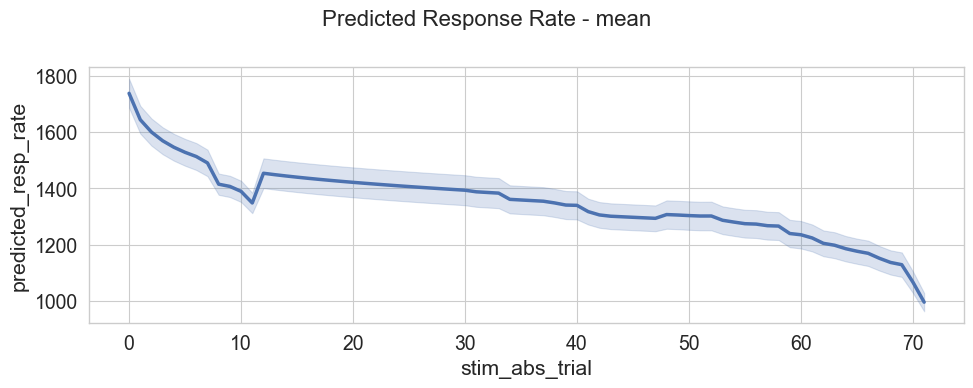

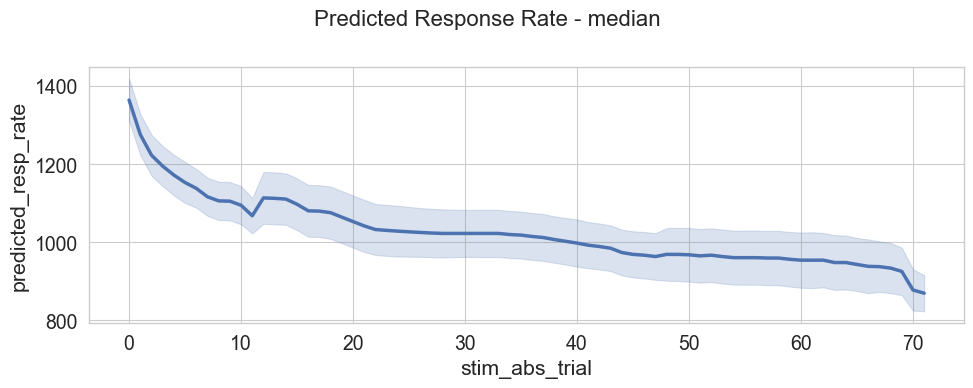

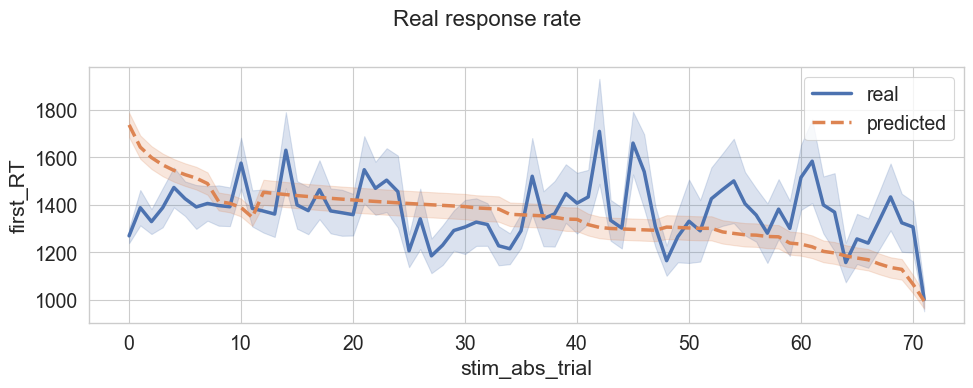

In [268]:
# predict for each participant the predicted sequence completion time at the end of the training:
# -------------------------------------------
predicted_data = IPI_consistency_data_by_trial.copy()
if var_of_comparison:
    predicted_data.loc[:, 'stim_abs_trial'] = predicted_data.groupby(['sub', 'stim_condition']).cumcount()
else:
    predicted_data.loc[:, 'stim_abs_trial'] = predicted_data.groupby(['sub']).cumcount()
predicted_data = predicted_data[predicted_data[var].notna()]

for group in predicted_data['group'].unique():
    # for each participant, predict the sequence completion for each trial:
    predicted_data.loc[:, 'predicted_resp_rate'] = np.nan
    for sub in predicted_data['sub'].unique():
        data = predicted_data[predicted_data['sub'] == sub]
        popt = results_df[results_df['sub'] == sub][['asymp_to', 'improvement', 'alpha']].iloc[0]
        predicted_data.loc[predicted_data['sub'] == sub, 'predicted_resp_rate'] = exponential_decay(predicted_data[predicted_data['sub'] == sub]['stim_abs_trial'], *popt)


# plot the predicted sequence completion time:
# -------------------------------------------
fig, axes = plt.subplots(1, 1, figsize=(10, 4))
# plot by  group:
# sns.lineplot(data=predicted_data, x='stim_abs_trial', y='predicted_IPI_abs_diff', hue='group', markers=True, ax=axes, errorbar=('se', 1))
sns.lineplot(data=predicted_data, x='stim_abs_trial', y='predicted_resp_rate', markers=True, ax=axes, errorbar=('se', 1))
# title to the figure:
title = 'Predicted Response Rate - mean'
fig.suptitle(title, fontsize=16)
fig.tight_layout()
plt.show()

def calculate_error_bars(x):
    # Calculate the median
    median = np.median(x)
    
    # Calculate the IQR
    iqr = np.quantile(x, 0.75) - np.quantile(x, 0.25)
    
    # Calculate the number of observations
    n = len(x)
    
    # Calculate the lower and upper bounds of the notch
    lower = median - 1.57 * iqr / np.sqrt(n)
    upper = median + 1.57 * iqr / np.sqrt(n)
    
    return lower, upper


# now with the median and 95% CI:
# -------------------------------------------
fig, axes = plt.subplots(1, 1, figsize=(10, 4))
# plot by  group:
# plot the median and 95% CI:
# sns.lineplot(data=predicted_data, x='stim_abs_trial', y='predicted_IPI_abs_diff', hue='group', markers=True, ax=axes, estimator=np.median, errorbar=calculate_error_bars)
sns.lineplot(data=predicted_data, x='stim_abs_trial', y='predicted_resp_rate', markers=True, ax=axes, estimator=np.median, errorbar=calculate_error_bars)

# title to the figure:
title = 'Predicted Response Rate - median'
fig.suptitle(title, fontsize=16)
fig.tight_layout()
plt.show()

# plot the real sequence completion time:
# -------------------------------------------
fig, axes = plt.subplots(1, 1, figsize=(10, 4))
# plot by  group:
# sns.lineplot(data=predicted_data, x='stim_abs_trial', y='IPI_abs_diff', hue='group', markers=True, ax=axes, errorbar=('se', 1))
# sns.lineplot(data=predicted_data, x='stim_abs_trial', y='predicted_resp_rate', hue='group', markers=True, ax=axes, errorbar=('se', 1), linestyle='--')
sns.lineplot(data=predicted_data, x='stim_abs_trial', y=var, markers=True, ax=axes, errorbar=('se', 1), label='real')
sns.lineplot(data=predicted_data, x='stim_abs_trial', y='predicted_resp_rate', markers=True, ax=axes, errorbar=('se', 1), linestyle='--', label='predicted')

# # in the legend make the dashed line have 'predicted' in the label:
# handles, labels = axes.get_legend_handles_labels()
# labels[1] = 'extensive training'
# labels[2] = 'extensive predicted'
# axes.legend(handles, labels)

# title to the figure:  
title = 'Real response rate'
fig.suptitle(title, fontsize=16)
fig.tight_layout()
plt.show()



In [269]:
# add the data to the main data:
# -------------------------------------------
Dependent_vars_copy = IPI_df[['subID', 'behav_adaptation_SCORE_NORMED']].drop_duplicates()

# change subID to sub:
Dependent_vars_copy.rename(columns={'subID': 'sub'}, inplace=True)

main_data_df_w_fitting = pd.merge(Dependent_vars_copy, results_df.drop(columns=['stim_condition']), on=['sub'], how='left')
# main_data_df_w_fitting.head()
# merge with the dependent variables:
# main_data_df_w_fitting = main_data_df_w_fitting.merge(Dependent_vars, on='sub', how='left')

(306, 12)


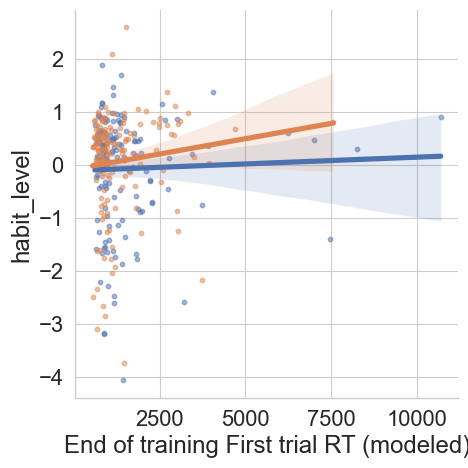

(306, 12)


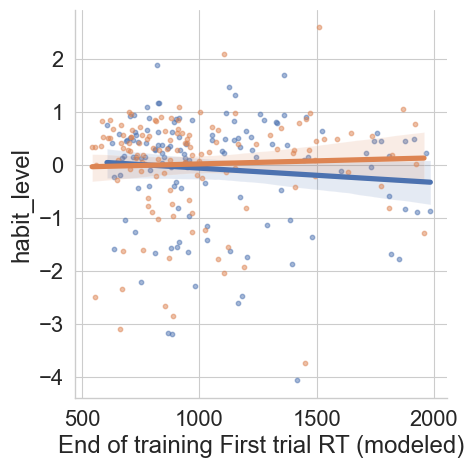

Pearson correlation for end_of_training_pred with devaluation ratio: 0.062, p-value: 0.1414
Spearman correlation for end_of_training_pred with devaluation ratio: 0.029, p-value: 0.3041


In [271]:
import statsmodels.formula.api as smf
from scipy.stats import pearsonr
from matplotlib.lines import Line2D

sns.set_context("paper", font_scale=1.8, rc={
    "lines.linewidth": 2.5,
    "lines.markersize": 8
})

only_after_devalued_data = main_data_df_w_fitting.copy()
pallette = ['#008B8B']
only_after_devalued_data['habit_level'] = -1 * only_after_devalued_data['behav_adaptation_SCORE_NORMED']

print(only_after_devalued_data.shape)
sns.lmplot(data=only_after_devalued_data, x='end_of_training_pred', y='habit_level', hue='group', order=1,scatter_kws={'s': 10, 'alpha': 0.5}, height=5, aspect=1, legend=False) #, ci=68)
plt.ylabel('habit_level')
plt.xlabel('End of training First trial RT (modeled)')
# plt.xlim(right=310)
plt.show()

print(only_after_devalued_data.shape)
sns.lmplot(data=only_after_devalued_data[only_after_devalued_data.end_of_training_pred<2000], x='end_of_training_pred', y='habit_level', hue='group', order=1,scatter_kws={'s': 10, 'alpha': 0.5}, height=5, aspect=1, legend=False) #, ci=68)
plt.ylabel('habit_level')
plt.xlabel('End of training First trial RT (modeled)')
# plt.xlim(right=310)
plt.show()

# Now do Pearson and Spearman correlation for the end of training predicted with devaluation ratio, and print coefficients and p-values
pearson_corr, pearson_p = pearsonr(only_after_devalued_data['end_of_training_pred'], only_after_devalued_data['habit_level'], alternative='greater')
print(f"Pearson correlation for end_of_training_pred with devaluation ratio: {pearson_corr:.3f}, p-value: {pearson_p:.4f}")
spearman_corr, spearman_p = spearmanr(only_after_devalued_data['end_of_training_pred'], only_after_devalued_data['habit_level'], alternative='greater')
print(f"Spearman correlation for end_of_training_pred with devaluation ratio: {spearman_corr:.3f}, p-value: {spearman_p:.4f}")


In [219]:
# now it in R:
# -------------------------------------------
# # Define the DataFrame in the R global environment
robjects.globalenv['only_after_devalued_data'] = only_after_devalued_data

r_code = """
library(lme4)
library(lmerTest)
library(car)
only_after_devalued_data$group <- as.factor(only_after_devalued_data$group)
only_after_devalued_data$end_of_training_pred <- scale(only_after_devalued_data$end_of_training_pred)
# effect coding:
only_after_devalued_data$group <- ifelse(only_after_devalued_data$group == "1-day", -1, 1)
model <- lm(habit_level ~ end_of_training_pred*group, data = only_after_devalued_data)
print(summary(model))
print(Anova(model, type="III"))
"""

# Execute user-defined R code
result = robjects.r(r_code)
print(result)



Call:
lm(formula = habit_level ~ end_of_training_pred * group, data = only_after_devalued_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.9920 -0.3045  0.2709  0.5840  2.5019 

Coefficients:
                           Estimate Std. Error t value Pr(>|t|)
(Intercept)                0.001515   0.056878   0.027    0.979
end_of_training_pred       0.084518   0.060568   1.395    0.164
group                      0.076865   0.056878   1.351    0.178
end_of_training_pred:group 0.053867   0.060568   0.889    0.375

Residual standard error: 0.9922 on 302 degrees of freedom
Multiple R-squared:  0.01218,	Adjusted R-squared:  0.002372 
F-statistic: 1.242 on 3 and 302 DF,  p-value: 0.2947

Anova Table (Type III tests)

Response: habit_level
                            Sum Sq  Df F value Pr(>F)
(Intercept)                  0.001   1  0.0007 0.9788
end_of_training_pred         1.917   1  1.9472 0.1639
group                        1.798   1  1.8263 0.1776
end_of_training_pred:group   0.7